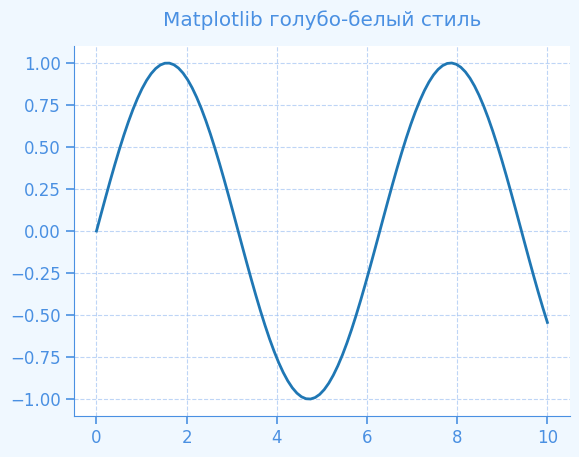

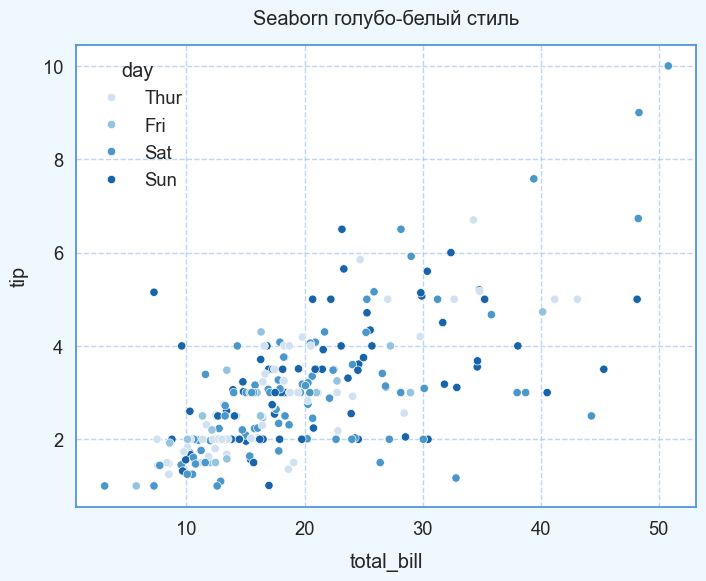

In [1]:

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

def set_blue_white_matplotlib_style():
    """
    Устанавливает голубо-белый стиль для matplotlib с приятным шрифтом, фоном и отступами.
    """
    style = {
        "axes.facecolor": "white",
        "axes.edgecolor": "#4A90E2",
        "axes.labelcolor": "#4A90E2",
        "xtick.color": "#4A90E2",
        "ytick.color": "#4A90E2",
        "grid.color": "#A3C4F3",
        "grid.linestyle": "--",
        "grid.alpha": 0.7,
        "lines.linewidth": 2,
        "lines.color": "#4A90E2",
        "figure.facecolor": "#F0F8FF",  # очень светлый голубой фон для фигуры
        "figure.edgecolor": "#F0F8FF",
        "text.color": "#4A90E2",
        "font.size": 12,
        "font.family": "DejaVu Sans, Arial, sans-serif",
        "legend.frameon": False,
        "legend.loc": "best",
        "axes.titlepad": 15,     # отступы заголовка
        "axes.labelpad": 10,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
    plt.rcParams.update(style)

def set_blue_white_seaborn_style():
    """
    Устанавливает голубо-белый стиль для seaborn поверх matplotlib.
    Также явно задаёт фон фигуры и осей, чтобы избежать чёрного фона.
    """
    set_blue_white_matplotlib_style()  # базовый стиль matplotlib
    sns.set_context("notebook", font_scale=1.2)
    sns.set_style("whitegrid", {
        "grid.color": "#A3C4F3",
        "grid.linestyle": "--",
        "axes.facecolor": "white",      # фон осей белый (область графика)
        "axes.edgecolor": "#4A90E2",
    })

    # Явно задаём фон фигуры светло-голубой
    plt.figure(figsize=(8, 6)).patch.set_facecolor('#F0F8FF')

def get_blue_white_plotly_template():
    """
    Возвращает plotly template для голубо-белого стиля с хорошим шрифтом и фоном.
    Используй в fig.update_layout(template=...)
    """
    return dict(
        layout=go.Layout(
            font=dict(family="DejaVu Sans, Arial, sans-serif", size=14, color="#4A90E2"),
            paper_bgcolor="#F0F8FF",
            plot_bgcolor="white",
            margin=dict(l=60, r=40, t=70, b=50),
            xaxis=dict(
                gridcolor="#A3C4F3",
                zerolinecolor="#4A90E2",
                linecolor="#4A90E2",
                tickcolor="#4A90E2",
                showgrid=True,
                zeroline=True,
                showline=True,
                ticks="outside",
                ticklen=6,
                tickwidth=1.5,
            ),
            yaxis=dict(
                gridcolor="#A3C4F3",
                zerolinecolor="#4A90E2",
                linecolor="#4A90E2",
                tickcolor="#4A90E2",
                showgrid=True,
                zeroline=True,
                showline=True,
                ticks="outside",
                ticklen=6,
                tickwidth=1.5,
            ),
            legend=dict(
                bgcolor="rgba(0,0,0,0)",
                font=dict(color="#4A90E2"),
                borderwidth=0,
            ),
            title=dict(
                x=0.5,
                xanchor='center',
                font=dict(color="#4A90E2", size=18, family="DejaVu Sans, Arial, sans-serif"),
            )
        )
    )

# Пример использования:
if __name__ == "__main__":
    import numpy as np

    # matplotlib
    set_blue_white_matplotlib_style()
    x = np.linspace(0, 10, 100)
    y = np.sin(x)
    plt.plot(x, y)
    plt.title("Matplotlib голубо-белый стиль")
    plt.grid(True)
    plt.show()

    # seaborn
    set_blue_white_seaborn_style()
    tips = sns.load_dataset("tips")
    sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day", palette="Blues")
    plt.title("Seaborn голубо-белый стиль")
    plt.show()

    # plotly
    import plotly.graph_objects as go
    fig = go.Figure(data=go.Scatter(x=[1, 2, 3], y=[4, 1, 2], mode='lines+markers', line=dict(color='#4A90E2')))
    fig.update_layout(template=get_blue_white_plotly_template(), title="Plotly голубо-белый стиль")
    fig.show()



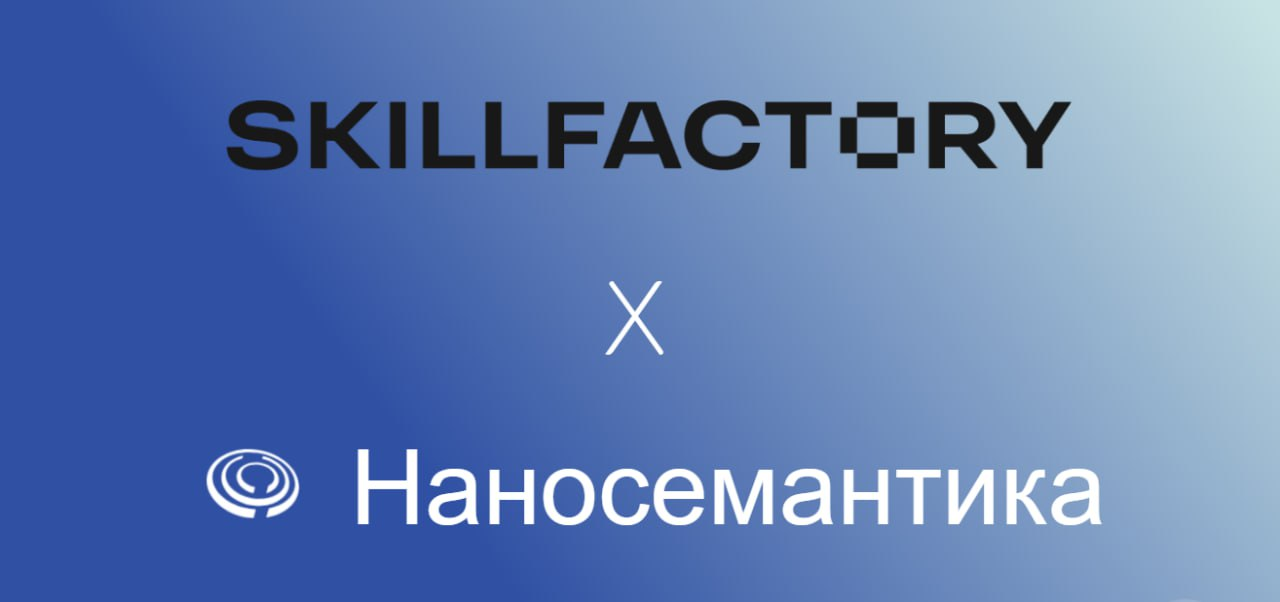

# Мы, Команда №2, рады представить итог двухнедельной работы. 
#### *Цель*: Создать код, способный анализировать вводимые в него результаты общего анализа крови и предоставлять рекомендацию о необходиомсти посещения определенного врача с указанием степени срочности 
*Задачи*: 

I) Оценить предоставленные данные и подготовить из них эталонный датасет

II) Разметить датасет на классы по заболеваниям 

III) Подобрать лучшую обучающую модель 

IV) С помощью обученной модели выдать класс (соответсвущее заболевание или норму) введенному общему анализу крови

V) Вывести рекомендацию 

<style>
/* Общий фон страницы */
body {
    background-color: #eaf6ff;
    color: #000000;
    font-family: "Segoe UI", sans-serif;
}

/* Все ячейки */
div.cell {
    background-color: #ffffff;
    border: 1px solid #b3d9ff;
    border-radius: 10px;
    padding: 12px;
    margin-bottom: 12px;
    box-shadow: 1px 1px 5px rgba(0,0,0,0.05);
}

/* Ячейки с кодом */
div.input_area {
    background-color: #f4fbff;
    border: 1px solid #a3d4f7;
    border-radius: 8px;
    padding: 8px;
    font-family: "Consolas", monospace;
}

/* Ячейки вывода */
div.output_area {
    background-color: #f0faff;
    border: 1px solid #a3d9ff;
    border-radius: 8px;
    padding: 10px;
    margin-top: 6px;
}

/* Markdown (текстовые) ячейки */
div.text_cell_render {
    color: #000000;
    font-size: 16px;
    line-height: 1.6;
}

/* Заголовки */
h1 {
    color: #007acc;
    border-bottom: 2px solid #cce7ff;
    padding-bottom: 5px;
}
h2 {
    color: #0088cc;
    border-bottom: 1px solid #cce7ff;
}
h3 {
    color: #0099cc;
}

/* Таблицы */
table {
    border-collapse: collapse;
    width: 100%;
}
th, td {
    border: 1px solid #cce6ff;
    padding: 6px;
    text-align: left;
}
th {
    background-color: #dff3ff;
}

/* --- ВИЗУАЛИЗАЦИИ --- */

/* Для всех графиков */
.output_png, .output_svg, .output_jpeg, .output_html, .output_pdf {
    background-color: #ffffff;
    border: 1px solid #cceeff;
    border-radius: 6px;
    padding: 6px;
    margin-top: 8px;
}

/* Изображения (matplotlib, seaborn, plotly) */
img, svg, canvas {
    background-color: #ffffff !important;
    border: 1px solid #cceeff;
    border-radius: 6px;
    max-width: 100%;
    height: auto;
    display: block;
    margin: 10px auto;
}

/* Plot titles and axes (если вставлены как HTML) */
.plot-title, .axis-title, .tick-label {
    color: #000000;
}

/* Tooltip или интерактивные вещи */
div.js-plotly-plot {
    background-color: #ffffff !important;
    border: 1px solid #b3e0ff;
    border-radius: 8px;
    padding: 6px;
}

/* Чтобы output не обрезался */
.output_scroll {
    overflow-x: auto;
    max-height: none;
}
</style>


## Загрузка библиотек и написание собственных функций

In [2]:
import warnings                   # чтобы не отвлекаться на предупреждения
import pandas as pd               # работа с таблицами
import numpy as np                # математика и массивы
import matplotlib.pyplot as plt   # графики
import seaborn as sns             # красивые графики на базе matplotlib

# Импорт из sklearn — библиотеки для машинного обучения
from sklearn.preprocessing import StandardScaler, MinMaxScaler      # приведение данных к одному масштабу
from sklearn.model_selection import train_test_split, GridSearchCV  # делим данные + подбор лучших параметров модели
from sklearn.ensemble import RandomForestClassifier                 # модель случайного леса (для классификации)
from sklearn.metrics import classification_report                   # отчёт по качеству модели

# Показывать все колонки в таблице 
pd.set_option('display.max_columns', None)

# Отключаем лишние предупреждения от pandas и по будущим обновлениям
warnings.filterwarnings('ignore', module='pandas')
warnings.simplefilter(action='ignore', category=FutureWarning)

# Настройка вывода чисел: без экспоненты
np.set_printoptions(suppress=True)

# Калькулятор для дат
from dateutil.relativedelta import relativedelta


In [3]:
# pip install --upgrade gdown

In [4]:
def anomaly(data):
    """
    Быстрый просмотр данных на пропуски и редкие значения.

    Принимает на вход DataFrame или Series и выводит в консоль:
    - Размер таблицы (строки, столбцы)
    - Для каждого столбца:
        - Все уникальные значения
        - Количество уникальных значений
        - Общее количество непустых значений
        - Количество пропусков (NaN)

    Полезно для первичной диагностики данных перед анализом.

    Параметры:
    ----------
    data : pandas.DataFrame или pandas.Series
        Таблица или колонка с данными, которые нужно проверить.

    Возвращает:
    -----------
    None
        Просто печатает результаты в консоль.
    """

    # Если на вход пришла просто колонка (Series), превращаем её в таблицу (DataFrame)
    if isinstance(data, pd.Series):
        data = data.to_frame()

    # Показываем размер таблицы — сколько строк и столбцов
    print(f'Размер файла: {data.shape}')
    print('-'*100)

    # Берём список названий столбцов
    column_data = data.columns

    # Для каждого столбца выводим полезную информацию
    for c in column_data:
        print(f'Уникальные значения показателя: {c}')
        print(data[c].unique())  # какие вообще значения встречаются
        print(f'Количество уникальных значений: {data[c].nunique()}')  # сколько разных значений
        print(f'Количество всех значений: {data[c].count()}')          # сколько непустых значений
        print(f'Количество пропусков в столбце {c}: {data[c].isna().sum()}')  # сколько пропущено
        print('-'*100)


In [5]:
def analisys_num(data):
    """
    Быстрый визуальный и статистический анализ числового признака.

    Строит сразу три графика:
    - Гистограмма со средним и медианой
    - Боксплот (boxplot)
    - Скрипичная диаграмма (violinplot)

    А также печатает базовую статистику (среднее, минимум, максимум и т.п.)
    и моду (наиболее частое значение).

    Параметры:
    ----------
    data : pandas.Series
        Одна числовая колонка из таблицы (например, df['height'])

    Возвращает:
    -----------
    None
        Просто показывает графики и печатает статистику.
    """
    # Применяем голубо-белый стиль matplotlib
    set_blue_white_matplotlib_style()

    # Создаём 3 графика рядом: гистограмма, boxplot и violinplot
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    # Гистограмма — распределение значений
    axes[0].hist(data.dropna(), bins=20)
    axes[0].set_title('Гистограмма показателя')
    axes[0].set_xlabel('Значения показателя')
    # Добавляем линии: медиана (синяя) и среднее (красная)
    axes[0].axvline(data.median(), color = 'b', linestyle = 'dashed', linewidth = 2)
    axes[0].axvline(data.mean(), color = 'r', linestyle = 'solid', linewidth = 2)
    axes[0].legend(['Медиана', 'Среднее', 'Мода'], prop = {'size': 6})

    # Боксплот — хорошо показывает выбросы
    axes[1].set_title('Боксплот показателя')
    axes[1].boxplot(data.dropna())

    # Скрипичная диаграмма — объединяет гистограмму и boxplot
    axes[2].set_title('Скрипичная диаграмма показателя')
    axes[2].violinplot([data.dropna()], vert = False, widths = 0.75,
                       showmeans = True, showmedians = True)

    # Уплотняем и показываем графики
    plt.tight_layout()
    plt.show()

    # Вывод описательной статистики
    print('Показатели описательной статистики')
    print(data.describe())  # среднее, минимум, максимум, квартили и т.д.
    print(f'Мода в данных по показателю: {data.mode()}')  # самое частое значение


In [6]:
def analisys_cat_pie(data, labels=None):
    """
    Быстрый анализ категориальных данных с помощью круговой диаграммы.

    Считает, сколько раз встречается каждое уникальное значение,
    и показывает это на круговой диаграмме с процентами.

    Параметры:
    ----------
    data : pandas.Series
        Колонка с категориальными данными (например, пол, страна, тип товара).

    labels : dict или None, по умолчанию None
        Словарь для замены значений в data на более понятные метки.
        Если передан, функция заменит значения согласно этому словарю.

    Возвращает:
    -----------
    None
        Просто показывает круговую диаграмму.
    """
    # Применяем голубо-белый стиль matplotlib
    set_blue_white_matplotlib_style()

    # Если переданы метки, заменяем значения по словарю labels
    if labels is not None:
        data = data.map(labels)

    # Строим круговую диаграмму с процентами
    data.value_counts().plot(kind = 'pie', autopct = '%.2f%%', figsize = (5, 5))
    plt.title('Круговая диаграмма показателя', size = 10) 
    plt.show()


In [7]:
def analisys_cat_plot(data):
    """
    Быстрый анализ категориальных данных с помощью столбчатой диаграммы.

    Считает количество каждого уникального значения и рисует столбики,
    чтобы визуально показать распределение категорий.

    Параметры:
    ----------
    data : pandas.Series
        Колонка с категориальными данными (например, категории товаров, города и т.п.).

    Возвращает:
    -----------
    None
        Просто показывает столбчатую диаграмму.
    """
    # Применяем голубо-белый стиль matplotlib
    set_blue_white_matplotlib_style()
    
    # Считаем сколько раз встречается каждое значение, сортируем по возрастанию
    data.value_counts(ascending = True).plot(kind = 'bar', alpha = 0.8)
    
    plt.title('Столбчатая диаграмма', size = 15) 
    plt.xlabel('Количество', size = 12) 
    plt.ylabel('Значения', size = 12) 
    plt.show()


In [8]:
def grafic(data, x, y):
    """
    Строит линейный график с трендом (lmplot) для двух числовых колонок.

    Используется для визуализации зависимости между двумя показателями
    с отображением линии регрессии.

    Параметры:
    ----------
    data : pandas.DataFrame
        Таблица с данными.

    x : str
        Название столбца для оси X.

    y : str
        Название столбца для оси Y.

    Возвращает:
    -----------
    None
        Показывает график.
    """
    set_blue_white_seaborn_style()  # применяем стиль перед построением графика
    
    # Строим график зависимости y от x с линией тренда
    sns.lmplot(x = x, y = y, data = data)

    # Добавляем заголовок и подписи к осям
    plt.title(f'Зависимость показателя {y} от показателя {x}', size = 10) 
    plt.xlabel(f'Показатель {x}', size = 8) 
    plt.ylabel(f'Показатель {y}', size = 8)

    plt.show()



In [9]:
def target_sigh(data, target_col, sign_col):
    """
    Визуализация распределения числового признака в группах по целевому признаку с помощью боксплота.

    Строит боксплот, сравнивающий распределение значений признака sign_col
    в группах, определённых колонкой target_col.

    Параметры:
    ----------
    data : pandas.DataFrame
        Таблица с данными, содержащая и целевой признак, и исследуемый числовой признак.

    target_col : str
        Название столбца с целевым признаком, по которому группируем данные (категориальный признак).

    sign_col : str
        Название столбца с числовым признаком, распределение которого анализируем.

    Возвращает:
    -----------
    None
        Показывает боксплот с распределением признака по группам.
    """

    # Устанавливаем голубой стиль seaborn (фон, цвета, шрифты)
    set_blue_white_seaborn_style()

    # Строим боксплот: на оси X — группы по целевому признаку, на оси Y — числовой признак
    sns.boxplot(x = target_col, y = sign_col, data = data)

    # Заголовок и подписи осей
    plt.title(f'Сравнение показателя {sign_col} у пациентов')
    plt.xlabel('Группы по целевому признаку')
    plt.ylabel(sign_col)

    # Показываем график
    plt.show()


In [10]:
def target_group(data, target_col, sign_col):
    """
    Анализ распределения категориального признака внутри групп целевого признака.

    Функция группирует данные по целевому признаку (target_col) и категориальному
    признаку (sign_col), строит гистограмму распределения категорий внутри каждой группы.

    Параметры:
    ----------
    data : pandas.DataFrame
        Таблица с данными, содержащая целевой признак и категориальный признак для анализа.

    target_col : str
        Название столбца с целевым (группирующим) признаком.

    sign_col : str
        Название столбца с категориальным признаком, распределение которого исследуем внутри групп.

    Возвращает:
    -----------
    None
        Показывает график распределения категорий по группам.
    """

    # Применяем голубой стиль seaborn и matplotlib
    set_blue_white_seaborn_style()

    # Вызов вспомогательной функции для построения гистограммы сгруппированных данных
    plot_grouped_data(
        data,
        group_cols = [target_col, sign_col],
        rename_dict = {'index': {0: 'Нет', 1: 'Есть'}}
    )

    # Отображаем график
    plt.show()


In [11]:
def replace_with_dict_key(value, rep_dict):
    """
    Заменяет входное значение на ключ словаря, если значение содержится в списке значений этого ключа.

    Параметры:
    ----------
    value : любой тип
        Значение, которое нужно заменить.

    rep_dict : dict
        Словарь, где ключи — новые значения,
        а значения — списки старых значений, которые надо заменить на ключ.

    Возвращает:
    -----------
    key : любой тип или None
        Ключ словаря, которому принадлежит исходное значение.
        Если значение не найдено ни в одном списке, возвращается None.

    Пример:
    --------
    rep_dict = {
        'яблоко': ['яблоко', 'apple', 'ябл.'],
        'банан': ['банан', 'banana']
    }
    replace_with_dict_key('apple', rep_dict)  # вернёт 'яблоко'
    replace_with_dict_key('orange', rep_dict) # вернёт None
    """

    for key, values_list in rep_dict.items():
        if value in values_list:
            return key
    return None


# <span style="color:#66CCFF"> Загрузка данных и первичная обработка</span>

In [12]:
# Загружаем данные
raw_df = pd.read_csv(r'data/undefind_DSMED.csv', sep=';')
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36297 entries, 0 to 36296
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID истории болезни                    36297 non-null  object 
 1   Осн. диаг. при выписке МКБ10 (текст)  36297 non-null  object 
 2   Заголовок документа                   36297 non-null  object 
 3   Кол. лаб. показатель                  36236 non-null  object 
 4   Значение кол. показателя              36236 non-null  float64
 5   Ед. изм. кол. показателя              36236 non-null  object 
 6   Норма кол. показателя                 36236 non-null  object 
 7   Флаг нормы кол. показателя            36236 non-null  object 
 8   Кач. лаб. показатель                  7005 non-null   object 
 9   Значение кач. показателя              7005 non-null   object 
 10  Норма кач. показателя                 7005 non-null   object 
 11  Пол            

In [13]:
# Посмотрим количество уникальных значений по колонкам
raw_df.nunique()

ID истории болезни                       243
Осн. диаг. при выписке МКБ10 (текст)      11
Заголовок документа                        1
Кол. лаб. показатель                     131
Значение кол. показателя                2608
Ед. изм. кол. показателя                  11
Норма кол. показателя                    123
Флаг нормы кол. показателя                 4
Кач. лаб. показатель                       7
Значение кач. показателя                 155
Норма кач. показателя                      5
Пол                                        2
Дата рождения пациента                   104
dtype: int64

<i>
Так как прогнозировать будем по показателям, то наши признаки в эталонном датасете - показатели лабораторных тестов
</i>

In [14]:
# Посмотрим состав Кол. лабораторных показателей
raw_df['Кол. лаб. показатель'].value_counts()

Кол. лаб. показатель
Гемоглобин (HGB)                                        1114
Гематокрит (HCT)                                        1114
Средний объем эритроцита (MCV)                          1114
Среднее содержание гемоглобина в эритроците (MCH)       1114
Средняя концентрация гемоглобина в эритроците (MCHC)    1114
                                                        ... 
Базофилы, абсолютное количество                            1
Ширина распределения эритроцитов                           1
Средний объем тромбоцита                                   1
Ширина распределения тромбоцитов по объему                 1
Средний объём тромбоцитов                                  1
Name: count, Length: 131, dtype: int64

<i>
Проблема: В составе тестов увидели много синонимов. 

Решение: мапить на уникальные признаки. 

Формируем словарь для маппинга

</i>

In [15]:
# Это словарь маппинга наименований лабораторных тестов

replacement_dict = {
    # Красная кровь
    'rbc': ['Эритроциты', 'Эритроциты (RBC)', 'Общее количество эритроцитов (RBC)', 'RBC'],
    'hgb': ['Гемоглобин', 'Гемоглобин (HGB)', 'HGB'],
    'hct': ['Гематокрит', 'Гематокрит (HCT)', 'HCT'],
    'mcv': ['Средний объем эритроцита', 'Средний объем эритроцита (MCV)', 'MCV'],
    'mch': ['Среднее содержание гемоглобина в эритроците', 'Среднее содержание гемоглобина в эритроците (MCH)', 'MCH'],
    'mchc': ['Средняя концентрация гемоглобина в эритроците', 'Средняя концентрация гемоглобина в эритроците (MCHC)', 'MCHC'],
    'rdw': ['Ширина распределения эритроцитов', 'Ширина распределения эритроцитов по объему (RDW)', 'RDW', 'Ширина распределения эритроцитов (RDW)'],
    'rdv_cv': ['Ширина распределения эритроцитов по объему, коэффициент вариации (RDW-CV)', 'Ширина распределения эритроцитов по объему, коэффициент вариации', 'RDW-CV '],
    'rdv_sd': ['Ширина распределения эритроцитов по объему, стандартное отклонение (RDW-SD)','Ширина распределения эритроцитов по объему, стандартное отклонение','Ширина распределения эритроцитов, стандартное отклонение (RDW-SD)', 'RDW-SD'],
    'ret_rel': ['RET%', 'Ретикулоциты %'],
    'ret_abs': ['Ретикулоциты кол-во'],    
    'cp': ['Цветовой показатель'],

    # Белая кровь
    'wbc': ['Лейкоциты', 'Лейкоциты (WBC)', 'Общее количество лейкоцитов (WBC)', 'WBC'],

    # Лейкоформула
    'ne_abs': ['Нейтрофилы, абсолютное количество', 'Нейтрофилы, абсолютное количество (NE#)', 'Абсолютное количество нейтрофилов (NE#)', 'Нейтрофилы #'],
    'ne_rel': ['Нейтрофилы, относительное количество', 'Нейтрофилы, относительное количество (NE%)', 'Относительное количество нейтрофилов (NE%)', 'Нейтрофилы %', 'NE%'],
    'ly_abs': ['Лимфоциты, абсолютное количество', 'Лимфоциты, абсолютное количество (LY#)', 'Абсолютное количество лимфоцитов (LY#)', 'Лимфоциты #'],
    'ly_rel': ['Лимфоциты, относительное количество', 'Лимфоциты, относительное количество (LY%)', 'Лимфоциты %', 'Относительное количество лимфоцитов (LY%)', 'Лимфоциты %', 'LY%', 'Лимфоциты'],
    'mo_abs': ['Моноциты, абсолютное количество', 'Моноциты, абсолютное количество (MO#)', 'Абсолютное количество моноцитов (MO#)', 'Моноциты #'],
    'mo_rel': ['Моноциты, относительное количество', 'Моноциты, относительное количество (MO%)', 'Моноциты %', 'Моноциты %', 'Относительное количество моноцитов (MO%)', 'MO%', 'Моноциты'],
    'eo_abs': ['Эозинофилы, абсолютное количество', 'Эозинофилы, абсолютное количество (EO#)', 'Абсолютное количество эозинофилов (EO#)', 'Эозинофилы # '],
    'eo_rel': ['Эозинофилы, относительное количество', 'Эозинофилы, относительное количество (EO%)', 'Эозинофилы %', 'Относительное количество эозинофилов (EO%)', 'EO%', 'Эозинофилы'],
    'ba_abs': ['Базофилы, абсолютное количество', 'Базофилы, абсолютное количество (BA#)', 'Абсолютное количество базофилов (BA#)', 'Базофилы #', 'Базофилы # '],
    'ba_rel': ['Базофилы, относительное количество', 'Базофилы, относительное количество (BA%)', 'Базофилы %', 'Относительное количество базофилов (BA%)', 'BA%', 'Базофилы'],
    'pal': ['Палочкоядерные'],
    'seg': ['Сегментоядерные'],
    'mxd_abs': ['Смешанная фракция, абсолютное количество (MXD#)', 'MXD# ', 'Смешанная фракция, абсолютное количество', 'MXD#'],
    'mxd_rel': ['Смешанная фракция, относительное количество (MXD%)', 'MXD%', 'Смешанная фракция, относительное количество', 'MXD'],
    'plasma': ['Плазматические клетки', 'Плазматич. клетки'], # в норме - 0-1%

    # Тромбоциты
    'plt': ['Тромбоциты', 'Тромбоциты (PLT)', 'PLT'],
    'pct': ['Тромбокрит', 'Тромбокрит (PCT)', 'PCT'],
    'mpv': ['Средний объем тромбоцита', 'Средний объём тромбоцитов', 'Средний объем тромбоцита (MPV)', 'MPV (Средний объём тромбоцитов)', 'MPV ', 'MPV'],
    'pdw': ['Ширина распределения тромбоцитов', 'Ширина распределения тромбоцитов по объему', 'Ширина распределения тромбоцитов (PDW)', 'PDW'],
    'plcr': ['P-LCR'],

    'soe': ['СОЭ Вест.', 'Скорость оседания эритроцитов (СОЭ) по Вестергрену', 'СОЭ по Панченкову', 'СОЭ Панч.'],

    'myelo': ['Миелоциты'], # в норме - 0 появление в периферической крови всегда указывает на патологию
    'yunye': ['Юные'], # в норме - 0 всегда требует обследования
    'blasty': ['Бласты'], # в норме - 0 опухолевые клетки, лейкоз
    'normobl_abs': ['Нормобласты', 'Нормобласты #'], # в норме - 0
    'normobl_rel': ['Нормобласты %'], # в норме - 0
    'prolym': ['Пролимфоциты'], # в норме - 0 "красный флаг", требующий исключения злокачественных заболеваний крови!
    'promyelo': ['Промиелоциты'], # в норме - 0  тревожный сигнал, требующий исключения лейкозов и других тяжелых заболеваний крови

    'noclass_abs': ['Неклассифицируемые кол-во'],
    'noclass_rel': ['Неклассифицируемые %'],
}

In [16]:
# начинаем первиную очистку и создание нужных признаков
prep_df = raw_df.copy()

# Удаляем полностью пустые строки
prep_df = prep_df.dropna(subset=['Кол. лаб. показатель'])

# Посчитаем возраст пациента в годах на 21.07.2025 - начало хакатона.
age_date = pd.to_datetime('2025-07-21')
prep_df['Дата рождения пациента'] = pd.to_datetime(prep_df['Дата рождения пациента'])
prep_df['age'] = prep_df['Дата рождения пациента'].apply(lambda x: relativedelta(age_date, x).years)

# Закодируем пол числом
prep_df['gender'] = prep_df['Пол'].apply(lambda x: 0 if 'ж' in x.lower() else 1)


Интерпретировать результаты лабораторных исследований возможно только в рамках одного лабораторного исследования, которое состоит из тестов. Лабораторное исследование, это своего рода, моментальный снимок показателей организма в момент забора биоматериала. Тесты внутри одного исследования взаимосвязаны друг с другом (явно или нет).

В представленном датасете нет разбивки тестов на отдельные исследования, поэтому, для того чтобы двигаться дальше нам необходимо свмим разбить предлагаемы массив на исследования наиболее вероятным путем.

Логика:
- В исходном датасете тесты идут в хронологическом порядке сверху вниз.
- В одном лабораторном исследовании (ЛИ) тесты не повторяются.
- При повторении теста начинается новое исследование с увеличенным номером.

Переменные:
- lab_study: список тестов текущего исследования.
- study_prefix: номер текущего исследования.

Функция create_lab_study_num:
- Принимает название теста (lab_test).
- Если тест уже был в текущем исследовании, сбрасывает список и увеличивает номер исследования.
- Иначе добавляет тест в текущий список.
- Возвращает строку с номером исследования, например 'result_0', 'result_1' и т.д.

После этого для каждой строки датасета prep_df в столбец 'study_num' записывается номер исследования,
а в 'study_ID' создается уникальный идентификатор исследования, объединяющий ID истории болезни и номер исследования.

In [17]:
# Формируем уникальные номера и ID для лабораторных исследований

lab_study = []
study_prefix = 0

def create_lab_study_num(lab_test):
    global lab_study
    global study_prefix
    res = 'result_'

    if lab_test in lab_study:
        lab_study.clear()
        study_prefix += 1
    else:
        lab_study.append(lab_test)
    return res + str(study_prefix)

prep_df['study_num'] = prep_df['Кол. лаб. показатель'].apply(lambda x: create_lab_study_num(x))
prep_df['study_ID'] = prep_df['ID истории болезни'] + '_' + prep_df['study_num']


In [18]:
# добавляем унифицированные коды тестов из словаря синонимов
prep_df['lab_test'] = prep_df['Кол. лаб. показатель'].apply(lambda x: replace_with_dict_key(x, replacement_dict))

In [19]:
# Переводим г/дл в г/л в MCHC
prep_df.loc[prep_df['Ед. изм. кол. показателя'] == 'г/дл', 'Значение кол. показателя'] *= 10
prep_df.loc[prep_df['Ед. изм. кол. показателя'] == 'г/дл', 'Ед. изм. кол. показателя'] = 'г/л'

In [20]:
# посмотрим сколько тестов осталось после унификации
prep_df['lab_test'].value_counts()

lab_test
ly_rel         2213
hgb            1619
hct            1619
mcv            1619
mch            1619
mchc           1619
rbc            1619
plt            1617
wbc            1616
mo_rel         1549
eo_rel         1473
ly_abs         1470
ne_rel         1332
ne_abs         1319
ba_rel         1177
mpv             982
pct             925
cp              832
rdw             829
soe             794
mo_abs          784
seg             740
eo_abs          739
pal             736
ba_abs          732
rdv_sd          698
rdv_cv          696
pdw             657
mxd_rel         517
mxd_abs         517
myelo           316
yunye           304
noclass_rel     239
normobl_abs     192
blasty          143
noclass_abs     117
plcr             81
ret_rel          57
ret_abs          44
plasma           30
promyelo         21
normobl_rel      18
prolym           16
Name: count, dtype: int64

In [21]:
# Сформируем справочный фрейм с данными пациенов, чтоб смержить с основным датасетом
pasp_df = prep_df[['study_ID', 'gender', 'age']].drop_duplicates().copy()
pat_pasp_df = prep_df[['ID истории болезни', 'gender', 'age']].drop_duplicates().copy()
pasp_df

,study_ID,gender,age
0,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_0,0,62
16,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_1,0,62
47,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_2,0,62
78,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_3,0,62
107,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_4,0,62
...,...,...,...
36176,6166e156-c1af-11ed-8602-005056880ecb_result_2637,1,43
36203,6166e156-c1af-11ed-8602-005056880ecb_result_2638,1,43
36227,6166e156-c1af-11ed-8602-005056880ecb_result_2639,1,43
36253,6166e156-c1af-11ed-8602-005056880ecb_result_2640,1,43


In [22]:
# Проверим референсные значения
ref_df = prep_df[['Пол', 'lab_test', 'Норма кол. показателя']].drop_duplicates()

ref_df[['lo_ref', 'hi_ref']] = ref_df['Норма кол. показателя'].str.split(':', n=1, expand=True)
ref_df.drop(columns=['Норма кол. показателя'], inplace=True)
ref_df['lo_ref'] = ref_df['lo_ref'].str.replace(',', '.')
ref_df['hi_ref'] = ref_df['hi_ref'].str.replace(',', '.')
ref_df.dropna(inplace=True)
ref_df[['lo_ref', 'hi_ref']] = ref_df[['lo_ref', 'hi_ref']].astype('float')
ref_df.drop_duplicates(inplace=True)
ref_df.sort_values(['Пол', 'lab_test'])

,Пол,lab_test,lo_ref,hi_ref
37,Ж,ba_abs,0.00,0.10
32,Ж,ba_rel,0.00,2.00
308,Ж,blasty,0.00,0.00
38,Ж,cp,0.80,1.05
1621,Ж,cp,0.85,1.15
...,...,...,...,...
484,М,soe,2.00,20.00
3590,М,soe,1.00,20.00
462,М,wbc,4.00,11.00
11344,М,wbc,4.00,8.80


<i>
Видим, что референсные значения разные для одних и тех же тестов, даже для одного пола. Похоже, на них не сможем ориентироваться, будем ориентироваться на флаги результата, т.к. они индивидуальны для каждого теста.
</i>

In [23]:
# Закодируем флаг результата числом: норма = 0, повышенный = 1, пониженный = -1
# пригодится, если захотим обучать не на абсолютах, а по флагам результата
prep_df['result'] = prep_df['Флаг нормы кол. показателя'].apply(lambda x: 0 if 'норм' in x.lower()
                                                                else (-1 if "пониж" in x.lower()
                                                                      else (1 if "повыш" in x.lower()
                                                                            else x)))

<i>
Перейдем к качественными показателями. У них нет числового результата и результатом будем считать флаг наличия или отсутствия признака. Часть качественных признаков названа явно, а часть их описаны в комментариях, не все из которых полезны.
</i>

In [24]:
# Выделяем качественные показатели, которые не в комментариях
mask = prep_df['Кач. лаб. показатель'].notna() & prep_df['Кач. лаб. показатель'].ne('Комментарий')
real_qual_df = prep_df[mask][['ID истории болезни', 'study_ID', 'Кач. лаб. показатель', 'Значение кач. показателя', 'Норма кач. показателя']].copy()
real_qual_df

,ID истории болезни,study_ID,Кач. лаб. показатель,Значение кач. показателя,Норма кач. показателя
930,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_38,Анизоцитоз,+,+-
931,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_39,Гипохромия,+,+-
932,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_39,Анизоцитоз,+,+-
933,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_40,Гипохромия,+,+-
934,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_40,Анизоцитоз,+,+-
...,...,...,...,...,...
36037,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2627,Пойкилоцитоз,+++,+-
36039,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2627,Анизоцитоз,+++,+-
36040,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2628,Пойкилоцитоз,+++,+-
36042,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2628,Анизоцитоз,+++,+-


In [25]:
# Посмотрим на значения нормы
real_qual_df['Норма кач. показателя'].value_counts(dropna=False)

Норма кач. показателя
+-             2170
Общая норма     223
0:1              29
0:2              20
Name: count, dtype: int64

In [26]:
# Посмотрим варианты нормы для разных кач показателей
real_qual_df.groupby(['Кач. лаб. показатель', 'Норма кач. показателя']).count()

ID истории болезни  study_ID  \
Кач. лаб. показатель Норма кач. показателя                                 
Анизоцитоз           +-                                    910       910   
                     Общая норма                           113       113   
Гипохромия           +-                                    191       191   
                     Общая норма                            54        54   
Макроцитоз           +-                                    141       141   
Микроцитоз           +-                                    139       139   
                     Общая норма                            29        29   
Нормобласты          0:1                                    29        29   
                     0:2                                    20        20   
Пойкилоцитоз         +-                                    789       789   
                     Общая норма                            27        27   

                                            Значение кач. показателя  
Кач. лаб. показатель Норма кач. показателя                            
Анизоцитоз           +-                                          910  
                     Общая норма                                 113  
Гипохромия           +-                                          191  
                     Общая норма                                  54  
Макроцитоз           +-                                          141  
Микроцитоз           +-                                          139  
                     Общая норма                                  29  
Нормобласты          0:1                                          29  
                     0:2                                          20  
Пойкилоцитоз         +-                                          789  
                     Общая норма                                  27

In [27]:
# Посмотрим на реальные значения качественных показателей
real_qual_df['Значение кач. показателя'].value_counts(dropna=False)

Значение кач. показателя
+            1250
++            895
+++           182
+-             66
3.0:100.0      29
3:100          20
Name: count, dtype: int64

In [28]:
# Сформируем словарь для кодирования результатов
real_result_dict = {
    0: ['-', '+-'],
    1: ['+', '++', '+++', '3.0:100.0', '3:100']
}
# Сформируем словарь для перекодирования наименований показателей (задалбывает переключать раскладку)
rus_to_eng_dict = {
    'anisocytos': ['Анизоцитоз'],
    'hypochromia': ['Гипохромия'],
    'macrocytos': ['Макроцитоз'],
    'microcytos': ['Микроцитоз'],
    'poikilocytos': ['Пойкилоцитоз'],
    'normoblast': ['Нормобласты']
}
# Перекодируем результаты числами
real_qual_df['Значение кач. показателя'] = real_qual_df['Значение кач. показателя'].apply(lambda x: replace_with_dict_key(x, real_result_dict))
real_qual_df['Кач. лаб. показатель'] = real_qual_df['Кач. лаб. показатель'].apply(lambda x: replace_with_dict_key(x, rus_to_eng_dict))
real_qual_df.drop(columns=['Норма кач. показателя'], inplace=True)
real_qual_df.drop_duplicates()

,ID истории болезни,study_ID,Кач. лаб. показатель,Значение кач. показателя
930,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_38,anisocytos,1
931,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_39,hypochromia,1
932,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_39,anisocytos,1
933,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_40,hypochromia,1
934,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_40,anisocytos,1
...,...,...,...,...
36037,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2627,poikilocytos,1
36039,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2627,anisocytos,1
36040,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2628,poikilocytos,1
36042,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2628,anisocytos,1


In [29]:
# Переведем значения качественных показателей из строк в столбцы
work_real_qual_df = real_qual_df.pivot_table(index='study_ID', columns='Кач. лаб. показатель', values='Значение кач. показателя', aggfunc='first')
pat_work_real_qual_df = real_qual_df.pivot_table(index='ID истории болезни', columns='Кач. лаб. показатель', values='Значение кач. показателя', aggfunc='first')

<i>
Вопрос: Добавлять ли комментарии в признаки?


Решение: Общим решением было не добавлять, так как сроки хакатона сжатые и обработка комментариев сильно отвлечет команду от цели работы. Но код для поиска полезной информации написан, при случае появления возможности поработать с эти еще
</i>

In [30]:
# # Выделяем кач показатели, которые в комментариях
# mask = prep_df['Кач. лаб. показатель'] == 'Комментарий'
# real_comm_df = prep_df[mask][['study_ID', 'Значение кач. показателя']].copy()
# real_comm_df

# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('проверен', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('Проверен', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('ПРОВЕРЕН', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('тромб.пров', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('тромбоциты по мазку', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('тромбоциты соответствуют', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('невозм', na=False)]

# real_comm_df[real_comm_df['Значение кач. показателя'].str.contains('промоноцит', na=False)] = 'promonocit'
# real_comm_df[real_comm_df['Значение кач. показателя'].str.contains('полихроматофильные эритроциты', na=False)] = 'polychrome_rbc'

# real_comm_df['Значение кач. показателя'].value_counts()

In [31]:
# Соберем датасет для работы
col_res_df = prep_df.pivot_table(values='result', columns='lab_test', index='study_ID', aggfunc='first')
work_df = prep_df.pivot_table(values='Значение кол. показателя', columns='lab_test', index='study_ID', aggfunc='first')
work_df = work_df.merge(col_res_df, on='study_ID', how='left', suffixes=('','_ql'))
work_df = work_df.merge(pasp_df, on='study_ID', how='left')
work_df = work_df.merge(work_real_qual_df, on='study_ID', how='left', suffixes=('','_ql')) # тут добавляем поля с соответствием норме из исходного датасет

<i>
Систематизируем информацию в таблице.
</i>

In [32]:
cols_ql_order = [ # порядок столбцов для привычного вывода
    'study_ID',
    'gender',
    'age',
     # Красная кровь
    'rbc', 'rbc_ql',
    'hgb', 'hgb_ql',
    'hct', 'hct_ql',
    'mcv', 'mcv_ql',
    'mch', 'mch_ql',
    'mchc', 'mchc_ql',
    'rdw', 'rdw_ql',
    'rdv_cv', 'rdv_cv_ql',
    'rdv_sd', 'rdv_sd_ql',
    'ret_rel',
    'ret_abs', 'ret_abs_ql',
    'cp', 'cp_ql',
    'anisocytos',
    'hypochromia',
    'macrocytos',
    'microcytos',
    'poikilocytos',

    # Белая кровь
    'wbc', 'wbc_ql',

    # Лейкоформула
    'ne_abs', 'ne_abs_ql',
    'ne_rel',
    'ly_abs', 'ly_abs_ql',
    'ly_rel',
    'mo_abs', 'mo_abs_ql',
    'mo_rel',
    'eo_abs', 'eo_abs_ql',
    'eo_rel',
    'ba_abs', 'ba_abs_ql',
    'ba_rel',
    'pal', 'pal_ql',
    'seg', 'seg_ql',
    'mxd_abs', 'mxd_abs_ql',
    'mxd_rel',
    'plasma', # в норме - 0-1%

    # Тромбоциты
    'plt', 'plt_ql',
    'pct', 'pct_ql',
    'mpv', 'mpv_ql',
    'pdw', 'pdw_ql',
    'plcr', 'plcr_ql',

    'soe', 'soe_ql',

    'myelo', # в норме - 0 появление в периферической крови всегда указывает на патологию
    'yunye', # в норме - 0 всегда требует обследования
    'blasty', # в норме - 0 опухолевые клетки, лейкоз
    'normoblast',
    'normobl_abs', 'normobl_abs_ql',# в норме - 0
    'normobl_rel', # в норме - 0
    'prolym', # в норме - 0 "красный флаг", требующий исключения злокачественных заболеваний крови!
    'promyelo', # в норме - 0  тревожный сигнал, требующий исключения лейкозов и других тяжелых заболеваний крови

    'noclass_abs', 'noclass_abs_ql',
    'noclass_rel',
]

# Выстроим столбцы в привычном порядке
work_df = work_df[cols_ql_order]

In [33]:
# Сохраним промежуточный результат в файл
work_df.to_csv('data/work_df.csv', index=False)

# <span style="color:#66CCFF"> Оценка предоставленных данных и подготовка из них эталонного датасета</span>

In [34]:
work_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 80 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_ID        3115 non-null   object 
 1   gender          3115 non-null   int64  
 2   age             3115 non-null   int64  
 3   rbc             1498 non-null   float64
 4   rbc_ql          1498 non-null   float64
 5   hgb             1506 non-null   float64
 6   hgb_ql          1506 non-null   float64
 7   hct             1530 non-null   float64
 8   hct_ql          1530 non-null   float64
 9   mcv             1549 non-null   float64
 10  mcv_ql          1549 non-null   float64
 11  mch             1551 non-null   float64
 12  mch_ql          1551 non-null   float64
 13  mchc            1558 non-null   float64
 14  mchc_ql         1558 non-null   float64
 15  rdw             805 non-null    float64
 16  rdw_ql          805 non-null    float64
 17  rdv_cv          683 non-null    f

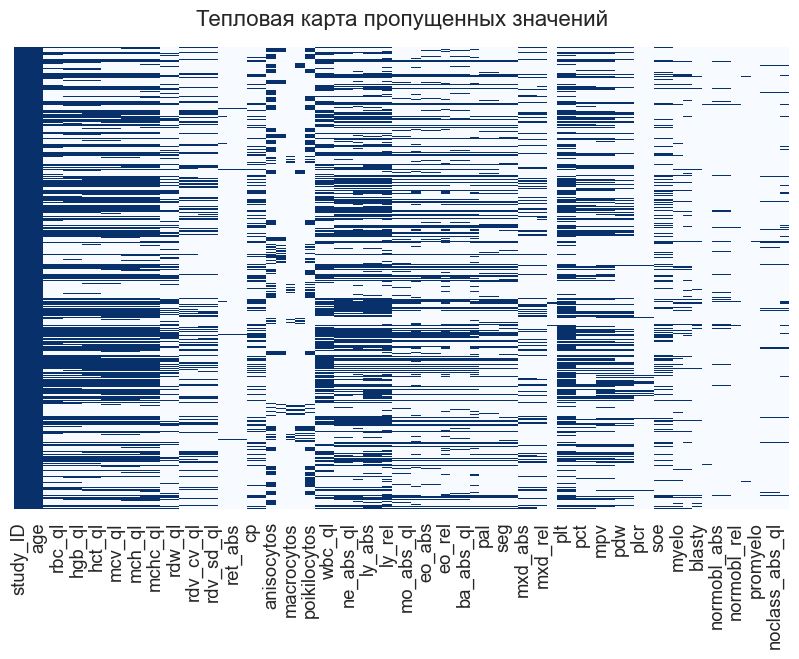

In [35]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='Blues_r', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

<i>
Предпринимаем попытки заполнить пропуски
</i>

In [36]:
def rel_tocol_calc(rel_col, abs_col):
    """
    Вычисление недостающих лейкоцитарных параметров на основе известных данных.

    Функция заполняет пропущенные значения:
    - Абсолютного показателя (abs_col), если известны относительный показатель (rel_col) и общее число лейкоцитов (wbc).
    - Общего числа лейкоцитов (wbc), если известны относительный и абсолютный показатели.

    Параметры:
    ----------
    rel_col : str
        Название колонки с относительным значением показателя (%).
        Например: 'нейтрофилы_%'

    abs_col : str
        Название колонки с абсолютным значением показателя (10⁹/л).
        Например: 'нейтрофилы_абс'

    Использует:
    -----------
    work_df : pandas.DataFrame (глобальная переменная)
        Рабочий датафрейм с лабораторными показателями, содержащий колонки:
        - rel_col (относительный показатель, %)
        - abs_col (абсолютный показатель)
        - 'wbc' (общее число лейкоцитов)

    Возвращает:
    -----------
    None
        Значения изменяются напрямую внутри work_df.
    """

    # Условие: если есть относительное значение и wbc, но нет абсолютного ---
    cond_rel_to_abs = (
        work_df[rel_col].notna() &        # относительное значение известно
        work_df['wbc'].notna() &          # wbc известно
        work_df[abs_col].isna()           # абсолютное значение отсутствует
    )

    # Вычисляем абсолютное значение: abs = rel (%) * wbc / 100
    work_df.loc[cond_rel_to_abs, abs_col] = (
        work_df.loc[cond_rel_to_abs, rel_col] * work_df.loc[cond_rel_to_abs, 'wbc'] * 0.01
    )

    # Обратная ситуация: если есть rel и abs, но отсутствует wbc ---
    cond_rel_to_wbc = (
        work_df[rel_col].notna() &        # rel известно
        work_df['wbc'].isna() &           # wbc отсутствует
        work_df[abs_col].notna()          # abs известно
    )

    # Вычисляем wbc: wbc = abs / (rel / 100)
    work_df.loc[cond_rel_to_wbc, 'wbc'] = (
        work_df.loc[cond_rel_to_wbc, abs_col] / work_df.loc[cond_rel_to_wbc, rel_col] * 100
    )
    # Пары: (абсолютное, относительное)
leukocyte_pairs = [
    ('ne_abs', 'ne_rel'),
    ('ly_abs', 'ly_rel'),
    ('mo_abs', 'mo_rel'),
    ('eo_abs', 'eo_rel'),
    ('ba_abs', 'ba_rel'),
    ('mxd_abs', 'mxd_rel'),
    ('ret_abs', 'ret_rel'),
    ('noclass_abs', 'noclass_rel'),
]

# Перебор всех пар
for abs_col, rel_col in leukocyte_pairs:
    rel_tocol_calc(abs_col, rel_col)

In [37]:
# Расчитаем значения по эритроцитам через Hct и MCV
cond_hct = (
    work_df['hct'].isna() &
    work_df['rbc'].notna() &
    work_df['mcv'].notna()
)

work_df.loc[cond_hct, 'hct'] = (
    work_df.loc[cond_hct, 'rbc'] * work_df.loc[cond_hct, 'mcv'] * 0.1
)

cond_rbc = (
    work_df['hct'].notna() &
    work_df['rbc'].isna() &
    work_df['mcv'].notna()
)

work_df.loc[cond_rbc, 'rbc'] = (
    work_df.loc[cond_rbc, 'hct'] * 10 / work_df.loc[cond_rbc, 'mcv']
)

cond_mcv = (
    work_df['hct'].notna() &
    work_df['rbc'].notna() &
    work_df['mcv'].isna()
)

work_df.loc[cond_mcv, 'mcv'] = (
    work_df.loc[cond_mcv, 'hct'] * 10 / work_df.loc[cond_mcv, 'rbc']
)

In [38]:
# Расчитаем значения по эритроцитам через hgb и MCH
cond_hgb = (
    work_df['hgb'].isna() &
    work_df['rbc'].notna() &
    work_df['mch'].notna()
)

work_df.loc[cond_hgb, 'hgb'] = (
    work_df.loc[cond_hgb, 'rbc'] * work_df.loc[cond_hgb, 'mch'] * 0.1
)

cond_rbc = (
    work_df['hgb'].notna() &
    work_df['rbc'].isna() &
    work_df['mch'].notna()
)

work_df.loc[cond_rbc, 'rbc'] = (
    work_df.loc[cond_rbc, 'hgb'] * 10 / work_df.loc[cond_rbc, 'mch']
)

cond_mch = (
    work_df['hgb'].notna() &
    work_df['rbc'].notna() &
    work_df['mch'].isna()
)

work_df.loc[cond_mch, 'mch'] = (
    work_df.loc[cond_mch, 'hgb'] * 10 / work_df.loc[cond_mch, 'rbc']
)

In [39]:
# Расчитаем значения по тромбоцитам где можно
cond_pct = (
    work_df['pct'].isna() &
    work_df['plt'].notna() &
    work_df['mpv'].notna()
)

work_df.loc[cond_pct, 'pct'] = (
    work_df.loc[cond_pct, 'plt'] * work_df.loc[cond_pct, 'mpv'] * 0.1
)

cond_plt = (
    work_df['pct'].notna() &
    work_df['plt'].isna() &
    work_df['mpv'].notna()
)

work_df.loc[cond_plt, 'plt'] = (
    work_df.loc[cond_plt, 'pct'] * 10 / work_df.loc[cond_plt, 'mpv']
)

cond_mpv = (
    work_df['pct'].notna() &
    work_df['plt'].notna() &
    work_df['mpv'].isna()
)

work_df.loc[cond_mpv, 'mpv'] = (
    work_df.loc[cond_mpv, 'pct'] * 10 / work_df.loc[cond_mpv, 'plt']
)

In [40]:
# Теперь удалим отоносительные величины, так ка они расчитаны из абсолютных
list_to_drop = [
    'ne_rel', 'ly_rel', 'mo_rel', 'ret_rel', 'pct',
    'eo_rel', 'ba_rel', 'mxd_rel', 'normobl_rel',
    'mch', 'rdv_cv', 'noclass_abs_ql', 'mch_ql', 'pct_ql',
    'noclass_abs', 'noclass_rel', 'rdv_cv_ql',

]
work_df = work_df.drop(columns=list_to_drop)

<i>
Так как пропусков в качественных показателях все еще много - закодируем пропуски нулями. 
</i>

In [41]:
norm_null_list = ['plasma', 'myelo', 'yunye', 'blasty', 'normobl_abs',
                  'prolym', 'promyelo', 'normoblast',
                  'plcr', 'hypochromia', 'ret_abs', 'normobl_abs_ql',
                  'macrocytos', 'microcytos',
                  'anisocytos', 'poikilocytos',
                  ]
# Заменим пустые значения но 0 (норма там где можно)
work_df[norm_null_list] = work_df[norm_null_list].fillna(0)

<i>
Удалим все исследования где нет количества эритроцитов и лейкоцитов, их ничем не заполнить, без них нельзя интерпретировать исследование.
</i>

In [42]:
work_df = work_df.dropna(subset=['rbc', 'wbc'], how='all')
work_df.shape

(1924, 63)

<i>
Разделим признаки на категориальные и числовые
</i>

In [43]:
cat_list = ['study_ID', 'gender', 'plasma', 'myelo', 'yunye', 'blasty',
            'prolym', 'promyelo', 'normoblast', 'hypochromia',
            'macrocytos', 'microcytos', 'anisocytos', 'poikilocytos',]
num_list = [col for col in work_df.columns if col not in cat_list]
work_df[cat_list] = work_df[cat_list].astype('object')

<i>
Пропуски будем заполнять нормой. Предположительно, отсутствие анализа у пациента предполагает отсутствие необходимости в этом анализе, т.е его анализ покажет норму 
</i>

In [44]:
ref_dict = { # Словарь референсных значений
    'rbc': [3.8, 5.8],
    'hgb': [120, 140],
    'hct': [39, 49],
    'mcv': [81, 100],
    'mchc': [320, 360],
    'rdw': [11.5, 14.5],
    'rdv_sd': [37, 54],
    'ret_abs': [0.67, 1.9],
    'cp': [0.85, 1],
    'wbc': [4, 9],
    'ne_abs': [2, 5.5],
    'ly_abs': [1, 4.8],
    'mo_abs': [0.04, 0.7],
    'eo_abs': [0.02, 0.45],
    'ba_abs': [0.01, 0.05],
    'pal': [1, 5],
    'seg': [47, 72],
    'mxd_abs': [0.2, 0.8],
    'plt': [180, 320],
    'mpv': [7.4, 10.4],
    'pdw': [15, 17],
    'plcr': [13, 43],
    'soe': [2, 10],
    'ret_abs': [17, 63],
}

# Заполним соответствие норме значениями из других строк
for col in ref_dict:
    work_df[col+'_ql'] = work_df[col+'_ql'].fillna(work_df.groupby(col)[col+'_ql'].transform('first'))

<i>
Посмотрим на результат заполнения данных
</i>

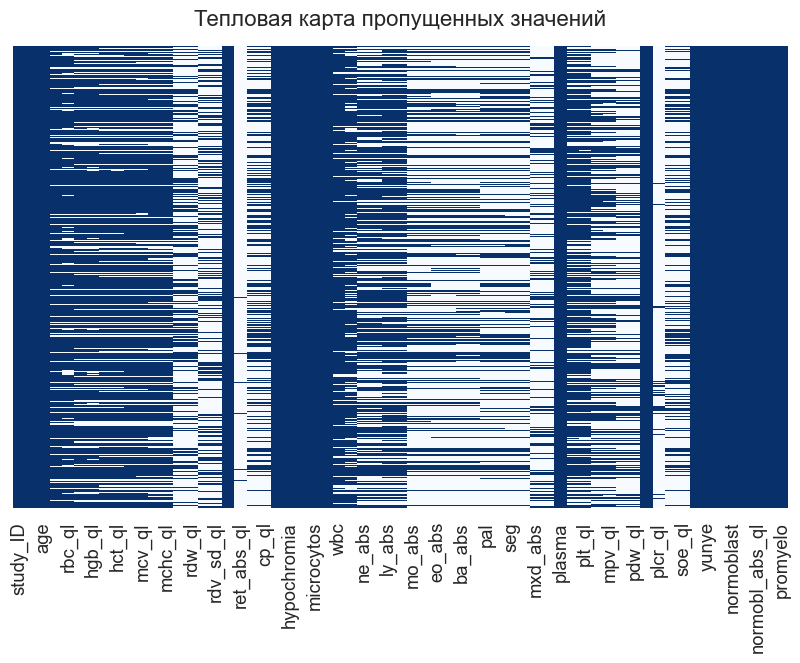

In [45]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='Blues_r', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [46]:
np.random.seed(42)

# Оставшиеся пропуски заполняем нормой
for col in ref_dict:
    mask = work_df[col].isna()
    work_df.loc[mask, col] = np.random.uniform(ref_dict[col][0], ref_dict[col][1], size=mask.sum())
    work_df[col] = work_df[col].round(2)

for col in ref_dict:
    mask = work_df[col+'_ql'].isna()
    
    def get_result(x):
        if x < ref_dict[col][0]:
            return -1
        elif x > ref_dict[col][1]:
            return 1
        else:
            return 0
    
    work_df.loc[mask, col+'_ql'] = work_df.loc[mask, col].apply(get_result)

<i>
Смотрим на результат работы
</i>

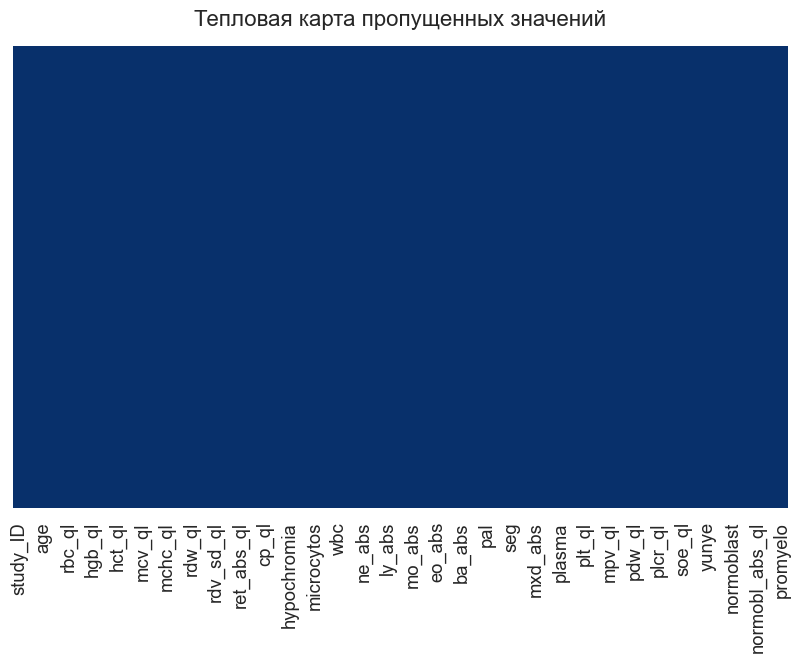

In [47]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='Blues_r', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [48]:
# Рассмотрим очищенный датасет
work_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1924.0,71.284823,10.661431,10.00,67.0000,71.000,77.0000,90.00
rbc,1924.0,3.955686,1.385585,1.10,3.0200,3.810,4.7400,10.58
rbc_ql,1924.0,-0.449584,0.623725,-1.00,-1.0000,-1.000,0.0000,1.00
hgb,1924.0,109.388950,32.461647,5.34,89.0000,112.000,131.0000,220.00
hgb_ql,1924.0,-0.532225,0.542045,-1.00,-1.0000,-1.000,0.0000,1.00
hct,1924.0,34.654984,10.620694,9.00,26.2000,33.700,43.0000,71.70
hct_ql,1924.0,-0.491684,0.589767,-1.00,-1.0000,-1.000,0.0000,1.00
mcv,1924.0,85.813015,8.905736,59.90,80.0000,84.480,90.5250,136.30
mcv_ql,1924.0,-0.175676,0.492598,-1.00,0.0000,0.000,0.0000,1.00
mchc,1924.0,325.419636,62.922951,24.40,324.0000,338.000,350.0000,404.00


In [49]:
# Рассмотрим очищенный датасет
work_df.describe(include='object').T

,count,unique,top,freq
study_ID,1924,1924,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,1
gender,1924,2,0,1048
anisocytos,1924.0,2.0,0.0,1785.0
hypochromia,1924.0,2.0,0.0,1895.0
macrocytos,1924.0,2.0,0.0,1913.0
microcytos,1924.0,2.0,0.0,1908.0
poikilocytos,1924.0,2.0,0.0,1830.0
plasma,1924.0,10.0,0.0,1904.0
myelo,1924.0,28.0,0.0,1683.0
yunye,1924.0,25.0,0.0,1708.0


<i>
Сохраним результат
</i>

In [50]:
etalon_df = work_df.copy()
etalon_df.to_csv('data/etalon_df.csv', index=False)

# <span style="color:#66CCFF"> Для дальнейшей работы нам необходимо определить возможные диагнозы и классы для них </span>

## <span style="color:#66CCFF"> Острая анемия </span>
Острая анемия (быстро развивающееся снижение гемоглобина и эритроцитов) в клиническом анализе крови проявляется следующими изменениями:  

### **Основные признаки:**  
1. **Снижение гемоглобина (Hb)** – ниже нормы (у женщин < 120 г/л, у мужчин < 130 г/л, при острой кровопотере может падать резко).  
2. **Снижение эритроцитов (RBC)** – уменьшение количества красных кровяных клеток (норма: ♀ 3,7–4,7 × 10¹²/л, ♂ 4,0–5,0 × 10¹²/л).  
3. **Нормальный или слегка сниженный средний объем эритроцитов (MCV)** – чаще нормоцитарная анемия (MCV 80–100 фл), так как при острой кровопотере теряются зрелые клетки.  
4. **Нормальное или повышенное содержание гемоглобина в эритроцитах (MCH, MCHC)** – цветовой показатель обычно в норме (0,85–1,05).  

### **Дополнительные признаки (зависят от причины и стадии):**  
- **Ретикулоцитоз** – через 3–5 дней после кровопотери увеличиваются молодые формы эритроцитов (компенсаторная реакция костного мозга).  
- **Лейкоцитоз** – возможен при кровопотере (реактивный ответ на стресс).  
- **Тромбоцитоз** – реактивное увеличение тромбоцитов в ответ на кровопотерю.  
- **Снижение гематокрита (Ht)** – уменьшение объема эритроцитов в крови (норма: ♀ 36–46%, ♂ 40–48%).  

### **Причины острой анемии:**  
- Острая кровопотеря (травма, желудочно-кишечное кровотечение, маточное кровотечение).  
- Гемолиз (разрушение эритроцитов при инфекциях, токсинах, аутоиммунных процессах).  

Если анемия развилась быстро, в первые часы гемоглобин может быть в норме (из-за сгущения крови), но затем падает. Для уточнения причины нужен осмотр врача и дополнительные исследования (ферритин, билирубин, анализ на скрытую кровь и др.).
## <span style="color:#66CCFF"> 1 - Хроническая анемия </span>
Хроническая анемия в клиническом анализе крови (ОАК) проявляется следующими изменениями:  

### **1. Снижение уровня гемоглобина (Hb)**  
- **У мужчин**: < 130 г/л  
- **У женщин**: < 120 г/л  
- **У беременных**: < 110 г/л  

### **2. Снижение количества эритроцитов (RBC)**  
- **У мужчин**: < 4,0 × 10¹²/л  
- **У женщин**: < 3,5 × 10¹²/л  

### **3. Изменение эритроцитарных индексов**  
- **Средний объем эритроцитов (MCV)**:  
  - **Микроцитарная анемия** (железодефицит, талассемия): MCV < 80 фл  
  - **Нормоцитарная анемия** (хронические болезни, гемолиз): MCV 80–100 фл  
  - **Макроцитарная анемия** (В12-/фолиеводефицит): MCV > 100 фл  
- **Среднее содержание гемоглобина в эритроците (MCH)**: снижено при железодефиците (< 27 пг)  
- **Средняя концентрация гемоглобина в эритроците (MCHC)**: снижена при гипохромных анемиях (< 320 г/л)  

### **4. Изменения в мазке крови**  
- **Гипохромия** (бледные эритроциты) – при железодефиците  
- **Анизоцитоз, пойкилоцитоз** – при длительной анемии  
- **Микроциты** (железодефицит), **макроциты** (В12-дефицит)  
- **Шизоциты** – при гемолизе  

### **5. Другие возможные изменения**  
- **Ретикулоциты**:  
  - **Снижены** при гипопролиферативных анемиях (железодефицит, хронические болезни)  
  - **Повышены** при гемолизе или кровопотере  
- **Ферритин** (не входит в ОАК, но важен для диагностики):  
  - Снижен при железодефиците  
  - Повышен при анемии хронических заболеваний  

### **6. Сопутствующие изменения**  
- **Лейкопения/тромбоцитопения** – при В12-дефиците, апластической анемии  
- **Тромбоцитоз** – при хронической кровопотере  

### **Вывод**  
Признаки хронической анемии в ОАК зависят от ее типа, но ключевые критерии – **снижение Hb, эритроцитов и изменение эритроцитарных индексов**. Для уточнения причины нужны дополнительные анализы (ферритин, витамин В12, фолиевая кислота, CRP, биохимия).  

Если у вас есть конкретные цифры анализа, можно уточнить тип анемии.
## <span style="color:#66CCFF"> Острое воспаление </span>
В клиническом анализе крови (ОАК) при остром воспалении наблюдаются следующие изменения:  

### **1. Лейкоцитоз** – повышение общего количества лейкоцитов (WBC):  
   - **Норма**: 4–9 × 10⁹/л  
   - **При воспалении**: > 10 × 10⁹/л (может достигать 15–20 × 10⁹/л и выше при гнойных процессах)  

### **2. Сдвиг лейкоцитарной формулы влево** – увеличение доли незрелых форм нейтрофилов:  
   - **Палочкоядерные нейтрофилы** ↑ (норма 1–6%, при воспалении > 10%)  
   - **Метамиелоциты (юные)** и **миелоциты** (в норме отсутствуют, появляются при тяжелом воспалении)  

### **3. Ускорение СОЭ** (скорость оседания эритроцитов):  
   - **Норма**: до 10–15 мм/ч (зависит от возраста и пола)  
   - **При воспалении**: > 20–30 мм/ч (может быть 50–100 мм/ч при гнойных процессах)  

### **4. Токсическая зернистость нейтрофилов** (при тяжелых бактериальных инфекциях)  

### **5. Возможные сопутствующие изменения**:  
   - **Анемия** (снижение гемоглобина и эритроцитов при хроническом воспалении)  
   - **Тромбоцитоз** (увеличение тромбоцитов – PLT > 400 × 10⁹/л) как реакция на воспаление  

### **При вирусных инфекциях**:  
   - **Лейкопения** или нормальное количество лейкоцитов  
   - **Лимфоцитоз** (↑ лимфоцитов)  
   - **Моноцитоз** (↑ моноцитов)  

### **При аллергических/паразитарных воспалениях**:  
   - **Эозинофилия** (↑ эозинофилов > 5%)  

Эти изменения помогают отличить бактериальное воспаление от вирусного и оценить тяжесть процесса. Для уточнения причины воспаления дополнительно могут назначаться **СРБ, прокальцитонин, ферритин и другие маркеры**.
## <span style="color:#66CCFF"> Хроническое воспаление </span>
В клиническом анализе крови (ОАК) хроническое воспаление может проявляться следующими изменениями:  

### **1. Анемия хронического заболевания (АХЗ)**  
- **Снижение гемоглобина (Hb)** – умеренная нормоцитарная или микроцитарная анемия.  
- **Низкий уровень сывороточного железа** (но ферритин в норме или повышен).  
- **Нормальный или повышенный уровень ферритина** (так как он является острофазовым белком).  

### **2. Изменения лейкоцитов**  
- **Нормальное или слегка повышенное количество лейкоцитов** (в отличие от острого воспаления, где выражен лейкоцитоз).  
- **Сдвиг лейкоцитарной формулы влево** (умеренное увеличение нейтрофилов, возможно появление незрелых форм).  
- **Лимфопения** (снижение лимфоцитов) при длительном воспалении.  

### **3. Тромбоцитоз**  
- **Умеренное повышение тромбоцитов** (тромбоцитоз) – реакция на хроническое воспаление.  

### **4. Ускоренная СОЭ**  
- **Повышенная скорость оседания эритроцитов (СОЭ)** – характерный, но неспецифический признак.  

### **5. Повышение острофазовых белков**  
- **Высокий уровень С-реактивного белка (СРБ)** – более чувствительный маркер, чем СОЭ.  
- **Повышенный фибриноген** (может влиять на СОЭ).  

### **Отличия от острого воспаления**  
- Нет резкого лейкоцитоза с нейтрофилезом.  
- Анемия развивается постепенно.  
- СОЭ и СРБ повышены, но не так резко, как при остром процессе.  

Эти изменения характерны для хронических инфекций (туберкулез, остеомиелит), аутоиммунных заболеваний (ревматоидный артрит, СКВ), онкологических процессов и других длительных воспалительных состояний. Для уточнения причины требуются дополнительные исследования (биохимия, иммунологические тесты, инструментальная диагностика).
## <span style="color:#66CCFF"> Специфическое воспаление </span>
Специфическое воспаление (например, при туберкулезе, сифилисе, саркоидозе, некоторых грибковых инфекциях) может иметь **особые черты в клиническом анализе крови (КАК)**, отличающие его от обычного бактериального или вирусного воспаления.  

### **Основные признаки в ОАК:**  
1. **Умеренный лейкоцитоз или нормальное количество лейкоцитов**  
   - В отличие от гнойного воспаления (нейтрофильный лейкоцитоз со сдвигом влево) или вирусной инфекции (лимфоцитоз).  
   - Возможна **лейкопения** (например, при туберкулезе, ВИЧ-ассоциированных инфекциях).  

2. **Лимфоцитоз или моноцитоз**  
   - **Лимфоцитоз** характерен для хронических специфических процессов (туберкулез, бруцеллез).  
   - **Моноцитоз** (>10%) – маркер гранулематозных заболеваний (туберкулез, саркоидоз, сифилис).  

3. **Эозинофилия**  
   - Может встречаться при паразитарных инфекциях, грибковых поражениях, некоторых формах туберкулеза.  

4. **Ускоренное СОЭ**  
   - Часто значительно повышено (30–60 мм/ч), особенно при активном процессе.  

5. **Анемия хронического заболевания**  
   - Нормохромная или гипохромная анемия (снижение гемоглобина и эритроцитов).  
   - Повышение ферритина при нормальном или сниженном уровне железа.  

6. **Тромбоцитоз или тромбоцитопения**  
   - **Тромбоцитоз** – реактивный, как признак хронического воспаления.  
   - **Тромбоцитопения** – при тяжелых инфекциях (например, милиарный туберкулез).  

### **Дополнительные особенности при конкретных заболеваниях:**  
- **Туберкулез**: лимфоцитоз/моноцитоз, возможна анемия, высокая СОЭ.  
- **Саркоидоз**: моноцитоз, иногда эозинофилия, повышенная СОЭ.  
- **Сифилис**: лимфоцитоз, возможна анемия.  
- **Грибковые инфекции (гистоплазмоз, криптококкоз)**: эозинофилия, моноцитоз.  

### **Важно!**  
Изменения в ОАК неспецифичны и требуют **подтверждения дополнительными методами** (ПЦР, серология, биопсия, рентген/КТ). Для точной диагностики учитывают **клиническую картину, анамнез и другие анализы** (СРБ, прокальцитонин, иммунологические тесты).  

## <span style="color:#66CCFF"> Аллергия </span>
В клиническом анализе крови (ОАК) при аллергии могут наблюдаться следующие изменения:  

### **1. Эозинофилия**  
- **Повышение уровня эозинофилов** (норма: 1–5% от общего числа лейкоцитов, абсолютное количество – 0,02–0,3 × 10⁹/л).  
- При аллергии их уровень может достигать **5–15% и более**, особенно при тяжелых реакциях (например, при бронхиальной астме, атопическом дерматите).  

### **2. Лейкоцитоз (реже)**  
- Умеренное повышение общего числа лейкоцитов (норма: 4–9 × 10⁹/л), но это неспецифический признак.  

### **3. Базофилия**  
- **Увеличение базофилов** (норма: 0–1%), особенно при хронической аллергии или контакте с аллергеном.  

### **4. Лимфоцитоз (иногда)**  
- Повышение лимфоцитов (норма: 20–40%) может наблюдаться при аллергических реакциях, но это непостоянный признак.  

### **5. СОЭ (обычно в норме или слегка повышена)**  
- При аллергии без инфекции СОЭ редко превышает **15–20 мм/ч**.  

### **Важно!**  
Эти изменения **не являются строго специфичными** для аллергии и могут встречаться при:  
- Гельминтозах,  
- Аутоиммунных заболеваниях,  
- Опухолях,  
- Некоторых инфекциях (например, паразитарных).  

### **Дополнительные исследования для подтверждения аллергии:**  
- **Анализ на IgE общий** (повышен при атопии),  
- **Специфические IgE** (например, ImmunoCAP, аллергопанели),  
- **Кожные пробы** (прик-тесты).  

Если в ОАК выявлена эозинофилия, но аллергия не подтверждается, нужно исключать другие причины (паразиты, болезни крови и др.).
## <span style="color:#66CCFF"> Онкология </span>
В клиническом анализе крови (КАК) при онкогематологических заболеваниях могут наблюдаться следующие изменения:  

### **1. Анемия**  
- **Снижение гемоглобина (Hb) и эритроцитов** (нормоцитарная или макроцитарная анемия).  
- **Ретикулоцитопения** (снижение молодых форм эритроцитов) – из-за угнетения эритропоэза.  
- **Анизоцитоз, пойкилоцитоз** (разные размеры и формы эритроцитов).  

### **2. Изменения лейкоцитов**  
- **Лейкоцитоз или лейкопения** (может быть как повышение, так и снижение).  
- **Бласты в периферической крови** (более 20% – признак острого лейкоза).  
- **Нейтропения** (снижение нейтрофилов) – частый признак при лейкозах и миелодиспластических синдромах.  
- **Лейкоцитарный «провал»** (отсутствие промежуточных форм – «hiatus leucemicus» при ОЛЛ или ОМЛ).  
- **Атипичные мононуклеары** (при лимфопролиферативных заболеваниях).  

### **3. Тромбоцитопения или тромбоцитоз**  
- **Снижение тромбоцитов** (часто при острых лейкозах, апластической анемии, МДС).  
- **Повышение тромбоцитов** (может быть при миелопролиферативных заболеваниях, например, при истинной полицитемии или эссенциальной тромбоцитемии).  

### **4. Другие признаки**  
- **Панцитопения** (снижение всех ростков крови) – при апластической анемии, МДС, инфильтрации костного мозга.  
- **Повышение СОЭ** (неспецифический признак, но часто при лимфомах, миеломной болезни).  
- **Тени Боткина-Гумпрехта** (полуразрушенные ядра лимфоцитов) – характерны для ХЛЛ.  

### **Подозрительные признаки на онкогематологию:**  
- **Цитопении неясного генеза** (особенно панцитопения).  
- **Появление бластов** в периферической крови.  
- **Высокий лейкоцитоз** с атипичными клетками.  
- **Тромбоцитоз** с другими изменениями (например, базофильно-эозинофильная ассоциация при ХМЛ).  

При обнаружении таких изменений требуется **консультация гематолога** и дополнительное обследование:  
- **миелограмма** (аспирация костного мозга),  
- **иммунофенотипирование**,  
- **цитогенетика и молекулярно-генетические исследования**. 

# <span style="color:#66CCFF"> Присваиваем классы </span>

<i>
Мы остановились на данных диагнозах:

- Острая анемия
- Хроническая анемия
- Острое воспаление
- Хронические воспаление
- Специфическое воспаление
- Аллергия
- Онкология
</i>

### 1) Ручной способ 


In [51]:
data = work_df.copy()

In [52]:
# Задаем условия для каждого из диагнозов

# Острая анемия
ac_anemia = (
    (data['rbc_ql'] <= 0) &                              # эритроциты могут быть на уровне нормы или ниже
    (data['hgb_ql'] <= 0) &                              # гемоглобин может быть на уровне нормы или ниже
    (data['hct_ql'] < 0) &                               # гематокрит может быть ниже нормы
    (data['mcv_ql'] < 1) &                               # MCV может быть немного ниже нормы
    (data['mchc_ql'] >= -1) &                            # цветовой показатель может быть нормальным или слегка пониженным
    (data['rdw_ql'] >= -1) &                             # распределение эритроцитов может быть в пределах нормы или слегка повышенным
    (data['rdv_sd_ql'] >= -1) &                          # среднеквадратичное отклонение объема эритроцитов может быть в пределах нормы
    (data['ret_abs_ql'] <= 0) &                         # ретикулоциты могут быть в норме или слегка понижены
    (data['cp_ql'] >= -1) &                              # цветовой показатель может быть нормальным или немного пониженным
    (data['anisocytos'] >= -1) &                         # анизоцитоз может быть незначительным
    (data['hypochromia'] >= -1) &                        # гипохромия может присутствовать, но не обязательно
    (data['macrocytos'] >= -1) &                         # макроциты могут присутствовать, но не обязательно
    (data['microcytos'] <= 0) &                          # микроцитоз может отсутствовать или быть незначительным
    (data['poikilocytos'] >= -1) &                       # пойкилоцитоз может быть незначительным
    (data['wbc_ql'] >= -1) &                             # лейкоциты могут быть в норме или немного повышены/понижены
    (data['ne_abs_ql'] <= 1) &                           # нейтрофилы могут быть в пределах нормы или немного повышены
    (data['ly_abs_ql'] <= 1) &                           # лимфоциты могут быть в пределах нормы или немного повышены
    (data['mo_abs_ql'] <= 1) &                           # моноциты могут быть в пределах нормы или немного повышены
    (data['eo_abs_ql'] <= 1) &                           # эозинофилы могут быть в пределах нормы или немного повышены
    (data['ba_abs_ql'] <= 1) &                           # базофилы могут быть в пределах нормы или немного повышены
    (data['pal_ql'] <= 1) &                              # палочкоядерные могут присутствовать, но не обязательно
    (data['seg_ql'] <= 1) &                              # сегментоядерные могут присутствовать, но не обязательно
    (data['mxd_abs_ql'] <= 1) &                          # смешанные формы лейкоцитов могут присутствовать, но не обязательно
    (data['plasma'] >= -1) &                             # плазма может варьироваться
    (data['plt_ql'] >= -1) &                             # тромбоциты могут варьироваться
    (data['mpv_ql'] <= 1) &                              # средний объем тромбоцитов может варьироваться
    (data['pdw_ql'] <= 1) &                              # распределение тромбоцитов может варьироваться
    (data['plcr_ql'] >= -1) &                            # доля больших тромбоцитов может варьироваться
    (data['soe_ql'] >= -1) &                             # СОЭ может варьироваться
    (data['myelo'] <= 1) &                               # миелоциты могут присутствовать, но не обязательно
    (data['yunye'] <= 1) &                               # юные клетки могут присутствовать, но не обязательно
    (data['blasty'] <= 1) &                              # бласты могут присутствовать, но не обязательно
    (data['normoblast'].between(0, 1)) &                 # нормобласты могут быть единичными или немного повышенными
    (data['normobl_abs_ql'] <= 1) &                      # количество нормобластов может варьироваться
    (data['normobl_abs_ql'] == 0) &                     # количество нормобластов
    (data['prolym'] == 0) &                             # пролимфоциты отсутствуют
    (data['promyelo'] == 0)                             # промиелоциты отсутствуют
).fillna(False)

# Хроническая анемия
chr_anemia = (
    (data['rbc_ql'] <= 0).fillna(True) &               # Эритроциты могут быть на уровне нормы или слегка понижены
    (data['hgb_ql'] <= 0).fillna(True) &               # Гемоглобин может быть на уровне нормы или слегка понижен
    (data['hct_ql'] <= 0).fillna(True) &               # Гематокрит может быть на уровне нормы или слегка понижен
    (data['mcv_ql'] >= -1).fillna(True) &              # Средний объем эритроцитов нормальный или слегка повышен
    (data['mchc_ql'] >= -1).fillna(True) &             # Средняя концентрация гемоглобина в эритроците нормальная или слегка понижена
    (data['rdw_ql'] >= 0).fillna(True) &               # Ширина распределения эритроцитов по объему нормальная или повышена
    (data['rdv_sd_ql'] >= 0).fillna(True) &            # Стандартное отклонение объема эритроцитов нормальное или повышено
    (data['ret_abs_ql'] <= 1).fillna(True) &           # Абсолютное количество ретикулоцитов может быть немного повышено или в норме
    (data['cp_ql'] >= -1).fillna(True) &               # Цветовой показатель в норме или немного понижен
    (data['anisocytos'] >= -1).fillna(True) &          # Анизоцитоз может быть незначительным
    (data['hypochromia'] >= -1).fillna(True) &         # Гипохромия может присутствовать, но не обязательно
    (data['macrocytos'] >= -1).fillna(True) &          # Макроцитоз может присутствовать, но не обязательно
    (data['microcytos'] <= 1).fillna(True) &           # Микроцитоз может отсутствовать или быть незначительным
    (data['poikilocytos'] >= -1).fillna(True) &        # Поиксилоцитоз может быть незначительным
    (data['wbc_ql'] >= -1).fillna(True) &              # Лейкоциты могут быть в норме или немного повышены/понижены
    (data['ne_abs_ql'] >= -1).fillna(True) &           # Абсолютное количество нейтрофилов может варьироваться
    (data['ly_abs_ql'] >= -1).fillna(True) &           # Абсолютное количество лимфоцитов может варьироваться
    (data['mo_abs_ql'] >= -1).fillna(True) &           # Абсолютное количество моноцитов может варьироваться
    (data['eo_abs_ql'] >= -1).fillna(True) &           # Абсолютное количество эозинофилов может варьироваться
    (data['ba_abs_ql'] >= -1).fillna(True) &           # Абсолютное количество базофилов может варьироваться
    (data['pal_ql'] >= -1).fillna(True) &              # Палочкоядерные нейтрофилы могут присутствовать, но не обязательно
    (data['seg_ql'] >= -1).fillna(True) &              # Сегментоядерные нейтрофилы могут присутствовать, но не обязательно
    (data['mxd_abs_ql'] >= -1).fillna(True) &          # Смещённые формы лейкоцитов могут присутствовать, но не обязательно
    (data['plasma'] >= 0).fillna(True) &               # Объем плазмы в норме или повышен
    (data['plt_ql'] <= 1).fillna(True) &               # Тромбоциты могут быть в норме или слегка понижены
    (data['mpv_ql'] >= -1).fillna(True) &              # Средний объем тромбоцитов может варьироваться
    (data['pdw_ql'] >= -1).fillna(True) &              # Распределение объема тромбоцитов может варьироваться
    (data['plcr_ql'] <= 0).fillna(True) &              # Доля крупных тромбоцитов может быть нормальной или пониженной
    (data['soe_ql'] >= 0).fillna(True) &               # Скорость оседания эритроцитов в норме или повышена
    (data['myelo'] <= 1).fillna(True) &                # Миелоциты могут присутствовать, но не обязательно
    (data['yunye'] <= 1).fillna(True) &                # Юные клетки могут присутствовать, но не обязательно
    (data['blasty'] <= 1).fillna(True) &               # Бласты могут присутствовать, но не обязательно
    (data['normoblast'].between(0, 2)).fillna(True) &  # Нормобласты могут быть единичными или немного повышенными
    (data['normobl_abs_ql'] <= 1).fillna(True) &       # Абсолютное количество нормобластов может варьироваться
    (data['prolym'] == 0).fillna(True) &            # Пролимфоциты отсутствуют
    (data['promyelo'] == 0).fillna(True)             # Промиелоциты отсутствуют
)
# Острое воспаление
ac_inflam = (
    (data['rbc_ql'] <= 1) &                                    # Эритроциты в норме или слегка понижены
    (data['hgb_ql'] <= 1) &                                    # Гемоглобин в норме или слегка понижен
    (data['hct_ql'] <= 1) &                                    # Гематокрит в норме или слегка понижен
    (data['mcv_ql'] >= -1) &                                   # может быть любой
    (data['mchc_ql'] >= -1) &                                  # любой
    (data['rdw_ql'] >= 0) &                                     # Повышенное распределение эритроцитов по объему (анизоцитоз)
    (data['rdv_sd_ql'] >= 0) &                                  # Повышенная вариабельность объема эритроцитов
    (data['ret_abs_ql'] >= -1) &                                # Ретикулоциты в норме или повышены (реактивный ответ)
    (data['cp_ql'] >= 0) &                                     # Цветовой показатель в норме или повышен
    (data['anisocytos'] >= 0) &                                 # Наличие анизоцитоза
    (data['hypochromia'] >= 0) &                               # Гипохромия отсутствует или есть
    (data['macrocytos'] >= 0) &                                # Макроцитоз отсутствует или выражен
    (data['microcytos'] == 0) &                                # Микроцитоз отсутствует
    (data['poikilocytos'] >= 0) &                              # Пойкилоцитоз отсутствует или есть
    (data['wbc_ql'] >= 0) &                                    # Лейкоциты в норме или повышены (лейкоцитоз)
    (data['ne_abs_ql'] >= 0) &                                  # Нейтрофилы повышены (нейтрофилия)
    (data['ly_abs_ql'] >= 0) &                                 # Лимфоциты в норме или слегка повышены
    (data['mo_abs_ql'] >= 0) &                                 # Моноциты в норме или слегка повышены
    (data['eo_abs_ql'] == 0) &                                 # Эозинофилы в норме
    (data['ba_abs_ql'] == 0) &                                 # Базофилы в норме
    (data['pal_ql'] >= 0) &                                     # Палочкоядерные повышены (сдвиг влево)
    (data['seg_ql'] >= 0) &                                    # Сегментоядерные в норме или повышены
    (data['mxd_abs_ql'] >= 0) &                                # Смешанные формы в норме или повышены
    (data['plasma'] >= 0) &                                    # Плазма в норме или повышена
    (data['plt_ql'] >= 0) &                                    # Тромбоциты в норме или повышены (реактивный тромбоцитоз)
    (data['mpv_ql'] >= 0) &                                    # Средний объем тромбоцитов в норме или повышен
    (data['pdw_ql'] >= 0) &                                    # Распределение тромбоцитов в норме или повышено
    (data['plcr_ql'] >= -1)&              # Любая
    (data['soe_ql'] >= 0) &                                    # СОЭ в норме или повышена
    (data['myelo'] >= 0) &                                     # Миелоциты отсутствуют или единичны
    (data['yunye'] >= 0) &                                     # Юные клетки отсутствуют или единичны
    (data['blasty'] == 0) &                                    # Бласты отсутствуют
    (data['normoblast'] >= 0) &                                # Нормобласты отсутствуют или единичны
    (data['normobl_abs_ql'] == 0) &                            # Количество нормобластов не повышено
    (data['prolym'] == 0) &                                    # Пролимфоциты отсутствуют
    (data['promyelo'] == 0)                                    # Промиелоциты отсутствуют
)

# Хроническое воспаление
chr_inflam = (
    (data['rbc_ql'] <= 0) &                                   # Эритроциты в норме или понижены
    (data['hgb_ql'] <= 0) &                                   # Гемоглобин в норме или понижен
    (data['hct_ql'] <= 0) &                                   # Гематокрит в норме или понижен
    (data['mcv_ql'] >= -1) &                                   # MCV в норме или повышен
    (data['mchc_ql'] >= 0) &                                  # MCHC в норме или повышен
    (data['rdw_ql'] >= 0) &                                   # RDW в норме или повышен (анизоцитоз)
    (data['rdv_sd_ql'] >= 0) &                                # RDV в норме или повышен
    (data['ret_abs_ql'] <= 0) &                               # Ретикулоциты в норме или понижены (пониженная регенерация)
    (data['cp_ql'] >= 0) &                                    # Цветовой показатель в норме или повышен
    (data['anisocytos'] >= 0) &                               # Анизоцитоз отсутствует или выражен
    (data['hypochromia'] >= 0) &                              # Гипохромия отсутствует или есть
    (data['macrocytos'] >= 0) &                               # Макроцитоз отсутствует или выражен
    (data['microcytos'] == 0) &                               # Микроцитоз отсутствует
    (data['poikilocytos'] >= 0) &                             # Пойкилоцитоз отсутствует или есть
    (data['wbc_ql'] >= -1) &                                   # Лейкоциты в норме
    (data['ne_abs_ql'] == 0) &                                # Нейтрофилы в норме
    (data['ly_abs_ql'] == 0) &                                # Лимфоциты в норме
    (data['mo_abs_ql'] ) &                                # Моноциты в норме
    (data['eo_abs_ql'] == 0) &                                # Эозинофилы в норме
    (data['ba_abs_ql'] == 0) &                                # Базофилы в норме
    (data['pal_ql'] == 0) &                                   # Палочкоядерные в норме
    (data['seg_ql'] == 0) &                                   # Сегментоядерные в норме
    (data['mxd_abs_ql'] == 0) &                               # Смешанные формы лейкоцитов в норме
    (data['plasma'] >= 0) &                                   # Плазма в норме или повышена
    (data['plt_ql'] >= -1) &                                   # Тромбоциты в норме или повышены
    (data['mpv_ql'] >= 0) &                                   # Средний объем тромбоцитов в норме или повышен
    (data['pdw_ql'] >= 0) &                                   # Распределение тромбоцитов в норме или повышено
    (data['plcr_ql'] >= -1) &                                  # Доля крупных тромбоцитов в норме или повышена
    (data['soe_ql'] >= 0) &                                   # СОЭ в норме или повышено
    (data['myelo'] == 0) &                                    # Миелоциты отсутствуют
    (data['yunye'] == 0) &                                    # Юные клетки отсутствуют
    (data['blasty'] == 0) &                                   # Бласты отсутствуют
    (data['normoblast'] >= 0) &                               # Нормобласты отсутствуют или единичны
    (data['normobl_abs_ql'] == 0) &                           # Количество нормобластов не повышено
    (data['prolym'] == 0) &                                   # Пролимфоциты отсутствуют
    (data['promyelo'] == 0)                                   # Промиелоциты отсутствуют
)

# Cпецифическое воспаление
spec_inflam = (
    (data['rbc_ql'] <= 1) &                                 # Эритроциты могут быть на уровне нормы или слегка снижены
    (data['hgb_ql'] <= 1) &                                 # Гемоглобин может быть на уровне нормы или слегка снижен
    (data['hct_ql'] <= 1) &                                 # Гематокрит может быть на уровне нормы или слегка снижен
    (data['mcv_ql'] >= -1) &                                # MCV может быть нормальным или слегка повышенным (возможно макроцитоз)
    (data['mchc_ql'] >= -1) &                               # MCHC может быть нормальным или слегка повышенным
    (data['rdw_ql'] >= 0) &                                 # RDW в норме или повышен
    (data['rdv_sd_ql'] >= 0) &                              # RDV в норме или повышен
    (data['ret_abs_ql'] <= 1) &                             # Ретикулоциты могут быть в норме или немного понижены
    (data['cp_ql'] >= -1) &                                 # Цветовой показатель в норме или немного понижен
    (data['anisocytos'] >= -1) &                            # Анизоцитоз может быть незначительным
    (data['hypochromia'] >= -1) &                           # Гипохромия может присутствовать, но не обязательно
    (data['macrocytos'] >= -1) &                            # Макроцитоз может присутствовать, но не обязательно
    (data['microcytos'] <= 1) &                             # Микроцитоз может отсутствовать или быть незначительным
    (data['poikilocytos'] >= -1) &                          # Пойкилоцитоз может быть незначительным
    (data['wbc_ql'] <= 1) &                                 # Лейкоциты могут быть в норме или слегка снижены
    (data['ne_abs_ql'] <= 1) &                              # Нейтрофилы могут быть в норме или слегка снижены
    (data['ly_abs_ql'] >= -1) &                             # Лимфоциты могут быть в норме или немного повышены
    (data['mo_abs_ql'] > 0) &                               # Моноциты должны быть повышены (макрофагальная реакция)
    (data['eo_abs_ql'] >= 0) &                              # Эозинофилы могут быть в норме или немного повышены
    (data['ba_abs_ql'] >= 0) &                              # Базофилы могут быть в норме или немного повышены
    (data['pal_ql'] >= 0) &                                 # Палочкоядерные могут присутствовать, но не обязательно
    (data['seg_ql'] <= 1) &                                 # Сегментоядерные могут быть в норме или немного снижены
    (data['mxd_abs_ql'] >= -1) &                            # Смешанные формы могут быть в норме или немного повышены
    (data['plasma'] >= 0) &                                 # Плазма в норме или повышена
    (data['plt_ql'] >= -1) &                                # Тромбоциты могут быть в норме или слегка понижены
    (data['mpv_ql'] >= -1) &                                # Средний объем тромбоцитов может варьироваться
    (data['pdw_ql'] >= -1) &                                # Распределение тромбоцитов может варьироваться
    (data['plcr_ql'] >= -1) &                               # Доля крупных тромбоцитов может варьироваться
    (data['soe_ql'] > 0) &                                  # СОЭ должна быть повышена
    (data['myelo'] <= 1) &                                  # Миелоциты могут присутствовать, но не обязательно
    (data['yunye'] <= 1) &                                  # Юные клетки могут присутствовать, но не обязательно
    (data['blasty'] <= 1) &                                 # Бласты могут присутствовать, но не обязательно
    (data['normoblast'].between(0, 1)) &                   # Нормобласты могут быть единичными или немного повышенными
    (data['normobl_abs_ql'] <= 1) &                         # Количество нормобластов может варьироваться
    (data['prolym'] == 0) &                                 # Пролимфоциты отсутствуют
    (data['promyelo'] == 0)                                 # Промиелоциты отсутствуют
)

# Аллергия
allerg = (
    (data['rbc_ql'] >= -1) &                                    # Эритроциты могут быть в норме или немного снижены
    (data['hgb_ql'] >= -1) &                                    # Гемоглобин может быть в норме или немного снижен
    (data['hct_ql'] >= -1) &                                    # Гематокрит может быть в норме или немного снижен
    (data['mcv_ql'] >= -1) &                                    # MCV может быть в норме или немного снижен
    (data['mchc_ql'] >= -1) &                                   # MCHC может быть в норме или немного снижен
    (data['rdw_ql'] >= 0) &                                     # RDW в норме или слегка повышен
    (data['rdv_sd_ql'] >= 0) &                                  # RDV в норме или слегка повышен
    (data['ret_abs_ql'] >= -1) &                                # Ретикулоциты могут быть в норме или немного снижены
    (data['cp_ql'] >= 0) &                                     # Цветовой показатель в норме или повышен
    (data['anisocytos'] >= -1) &                                # Анизоцитоз может быть незначительным
    (data['hypochromia'] >= -1) &                               # Гипохромия может присутствовать, но не обязательно
    (data['macrocytos'] >= -1) &                                # Макроцитоз может присутствовать, но не обязательно
    (data['microcytos'] <= 1) &                                 # Микроцитоз может отсутствовать или быть незначительным
    (data['poikilocytos'] >= -1) &                              # Пойкилоцитоз может быть незначительным
    (data['wbc_ql'] >= 0) &                                     # Лейкоциты в норме или повышены
    (data['ne_abs_ql'] <= 0) &                                  # Нейтрофилы в норме или снижены
    (data['ly_abs_ql'] >= -1) &                                 # Лимфоциты могут быть в норме или немного снижены
    (data['mo_abs_ql'] >= 0) &                                  # Моноциты в норме или повышены
    (data['eo_abs_ql'] > 0) &                                   # Эозинофилы должны быть повышены — ключевой маркер аллергии
    (data['ba_abs_ql'] >= -1) &                                 # Базофилы могут быть в норме или немного повышены
    (data['pal_ql'] <= 1) &                                     # Палочкоядерные могут присутствовать, но не обязательно
    (data['seg_ql'] >= -1) &                                    # Сегментоядерные могут быть в норме или немного снижены
    (data['mxd_abs_ql'] >= 0) &                                 # Смешанные формы в норме или повышены
    (data['plasma'] >= 0) &                                     # Плазма в норме или повышена
    (data['plt_ql'] >= -1) &                                    # Тромбоциты могут быть в норме или немного снижены
    (data['mpv_ql'] >= -1) &                                    # Средний объем тромбоцитов может варьироваться
    (data['pdw_ql'] >= -1) &                                    # Распределение тромбоцитов может варьироваться
    (data['plcr_ql'] >= -1) &                                   # Доля крупных тромбоцитов может варьироваться
    (data['soe_ql'] > 0) &                                      # СОЭ должна быть повышена
    (data['myelo'] <= 1) &                                      # Миелоциты могут присутствовать, но не обязательно
    (data['yunye'] <= 1) &                                      # Юные клетки могут присутствовать, но не обязательно
    (data['blasty'] <= 1) &                                     # Бласты могут присутствовать, но не обязательно
    (data['normoblast'].between(0, 2)) &                        # Нормобласты могут быть единичными или немного повышенными
    (data['normobl_abs_ql'] <= 1) &                             # Количество нормобластов может варьироваться
    (data['prolym'] <= 1) &                                     # Пролимфоциты могут присутствовать, но не обязательно
    (data['promyelo'] == 0)                                     # Промиелоциты отсутствуют
)

# Онкология
onco = (
    (data['rbc_ql'] <= 0) &                                   # Снижены эритроциты
    (data['hgb_ql'] <= 0) &                                   # Снижены гемоглобин
    (data['hct_ql'] <= 0) &                                   # Снижен гематокрит
    (data['mcv_ql'] >= -2) &                                   # MCV может быть нормальным или немного повышенным
    (data['mchc_ql'] >= -1) &                                  # MCHC может быть нормальным или немного повышенным
    (data['rdw_ql'] >= 0) &                                    # RDW может быть в норме или немного повышен
    (data['rdv_sd_ql'] >= 0) &                                 # RDV может быть в норме или немного повышен
    (data['ret_abs_ql'] <= 0) &                               # Ретикулоциты снижены (подавленная регенерация)
    (data['cp_ql'] >= -1) &                                    # Цветовой показатель может быть нормальным или немного понижен
    (data['anisocytos'] >= -1) &                               # Анизоцитоз может быть незначительным
    (data['hypochromia'] >= -1) &                              # Возможна гипохромия
    (data['macrocytos'] >= -1) &                               # Возможен макроцитоз
    (data['microcytos'] >= -1) &                               # Возможен микроцитоз
    (data['poikilocytos'] >= -1) &                             # Пойкилоцитоз может быть незначительным
    (data['wbc_ql'] >= -1) &                                   # Лейкоциты могут быть в норме или немного снижены
    (data['ne_abs_ql'] >= -1) &                                # Нейтрофилы могут быть в норме или немного снижены
    (data['ly_abs_ql'] >= -1) &                                # Лимфоциты могут быть в норме или немного повышены
    (data['mo_abs_ql'] >= 0) &                                 # Моноциты могут быть в норме или повышены
    (data['eo_abs_ql'] >= -1) &                                # Эозинофилы могут быть в норме или немного повышены
    (data['ba_abs_ql'] >= -1) &                                # Базофилы могут быть в норме или немного повышены
    (data['pal_ql'] >= 0) &                                   # Палочкоядерные могут присутствовать
    (data['seg_ql'] >= -1) &                                   # Сегментоядерные могут быть в норме или немного снижены
    (data['mxd_abs_ql'] >= 0) &                               # Смешанные формы могут присутствовать
    (data['plasma'] >= -1) &                                   # Плазма может быть в норме или немного повышена
    (data['plt_ql'] <= 0) &                                   # Тромбоциты часто снижены, но допускается небольшое повышение
    (data['mpv_ql'] >= -1) &                                   # Средний объем тромбоцитов может варьироваться
    (data['pdw_ql'] >= -1) &                                   # Распределение тромбоцитов может варьироваться
    (data['plcr_ql'] >= -1) &                                  # Доля крупных тромбоцитов может варьироваться
    (data['soe_ql'] > 0) &                                    # СОЭ должна быть повышена
    ((data['myelo'] >= 0) | (data['blasty'] >= 0)) |         # Присутствуют незрелые клетки (миелоциты, бласты)
    ((data['yunye'] >= 0) | (data['normoblast'] >= 0)) |     # Юные формы и нормобласты могут присутствовать
    ((data['normobl_abs_ql'] >= 0) | (data['prolym'] >= 0)) |# Пролимфоциты могут присутствовать
    (data['promyelo'] >= 0)                                    # Промиелоциты могут присутствовать
)

In [53]:
# Присваиваем уникальные степени двойки каждому классу
data.loc[ac_anemia, 'class0'] = 1    # 2^0
data.loc[chr_anemia, 'class1'] = 2    # 2^1
data.loc[ac_inflam, 'class2'] = 4     # 2^2
data.loc[chr_inflam, 'class3'] = 8    # 2^3
data.loc[spec_inflam, 'class4'] = 16  # 2^4
data.loc[allerg, 'class5'] = 32       # 2^5
data.loc[onco, 'class6'] = 64         # 2^6

# Заменяем пропущенные значения на 0 (иначе сумма будет NaN)
class_cols = ['class0', 'class1', 'class2', 'class3', 'class4', 'class5', 'class6']
data[class_cols] = data[class_cols].fillna(0)

# Суммируем значения
data['class'] = data[class_cols].sum(axis=1)

# Проверяем результат
print(data['class'].value_counts())

class
67.0     548
70.0     371
64.0     323
66.0     307
71.0     254
68.0      87
65.0       9
83.0       6
78.0       5
79.0       3
91.0       2
82.0       2
74.0       2
94.0       1
95.0       1
99.0       1
114.0      1
115.0      1
Name: count, dtype: int64


Видим очень сильный дисбаланс классов, хотя такой подход позволяет учитывать наличие нескольких диагнозов (синдромов) в одном исследовании и объяснять такие пересечения с точки зрения клинической картины.

Примененение жестких правил для классификации показало себя как требовательный к ресурсам способ с высокими требованиями к экспертизе. Его можно применить вне рамок хакатона, но на данном этапе он мог занять все отведенное время.

### 1) При помощи GPT
<i>
Мы попросили GPT-4o.разделить датасет на классы.
Его логика была такова: 

Класс - Код
Анемия - 1
Воспаление - 2
Онкологическое заболевание - 4
Норма - 0

Комбинированные классы представлены суммой кодов.
Анемия + Воспаление = 1 + 2 = 3
Анемия + Онкология = 1 + 4 = 5

Получили документ - gpt_etalon_df_labeled.csv

С ним продолжили работать, так как ручное разделение на классы получили сильно позже
</i>

# <span style="color:#66CCFF"> Переходим к EDA данных </span>

In [54]:
df = pd.read_csv('data/gpt_etalon_df_labeled.csv')

# перекодируем классы
class_dict = {
    0: ['normal'],
    1: ['anemia'],
    2: ['inflammation'],
    3: ['anemia;inflammation'],
    4: ['anemia;inflammation;cancer',
        'inflammation;cancer',
        'anemia;cancer', 'cancer']
}

# Создаем обратный словарь для поиска
reverse_dict = {}
for class_id, labels in class_dict.items():
    for label in labels:
        reverse_dict[label] = class_id

# Функция для поиска соответствующего класса
def find_class(label):
    # Проверяем точное соответствие
    if label in reverse_dict:
        return reverse_dict[label]
    # Если нет точного соответствия, возвращаем None или другое значение по умолчанию
    return None  # или можно вернуть -1 для "неизвестный класс"

# Создаем столбец class
df['class'] = df['class_label'].apply(find_class)

In [55]:
# Уберем столбцы с соответстветствием норме, чтоб не считать на входе по справочнику
df = df.loc[:, ~df.columns.str.endswith('_ql')]
# Удалим служебную информацию
df.drop(columns=['study_ID', 'anemia_flag',
                 'inflammation_flag', 'cancer_flag',
                 'normal_flag', 'class_code', 'class_label'], inplace=True)

In [56]:
# Воспольземся ранее написанной функцией на поиск аномалий
anomaly(df)

Размер файла: (1924, 39)
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: gender
[0 1]
Количество уникальных значений: 2
Количество всех значений: 1924
Количество пропусков в столбце gender: 0
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: age
[87 51 86 77 73 78 70 71 59 81 67 90 53 57 61 76 68 62 38 35 66 82 74 69
 65 80 39 33 49 10 75 84 52 55 43 56 64 63 50 88 40 48 54 41 45 44 60]
Количество уникальных значений: 47
Количество всех значений: 1924
Количество пропусков в столбце age: 0
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: rbc
[ 2.21  1.91  4.55  2.97  7.29  7.48  5.7   8.23  4.9   2.13  2.47  2.85
  3.34  3.98  4.93  4.06  4.34  4.87  5.26  2.17  4.    3.79  3.22  5.
  2.08  2.12  2.63  3.61  3.46  4.4   2.41  4.11  3.72  2

In [57]:
# Разделим столбцы по типам 
bool_col = ['gender', 'anisocytos', 'hypochromia',
            'macrocytos','microcytos', 'poikilocytos',
            'normoblast']

num_col = ['age', 'rbc', 'hgb', 'hct', 'mcv', 'mchc', 'rdw',
           'rdv_sd', 'ret_abs', 'cp', 'wbc', 'ne_abs', 'ly_abs',
           'mo_abs', 'eo_abs', 'ba_abs', 'pal', 'seg', 'mxd_abs',
           'plasma', 'plt', 'mpv', 'pdw', 'plcr', 'soe', 'myelo',
           'yunye', 'blasty', 'normobl_abs', 'promyelo']

cat_col = ['class']


Исследовательский анализ age


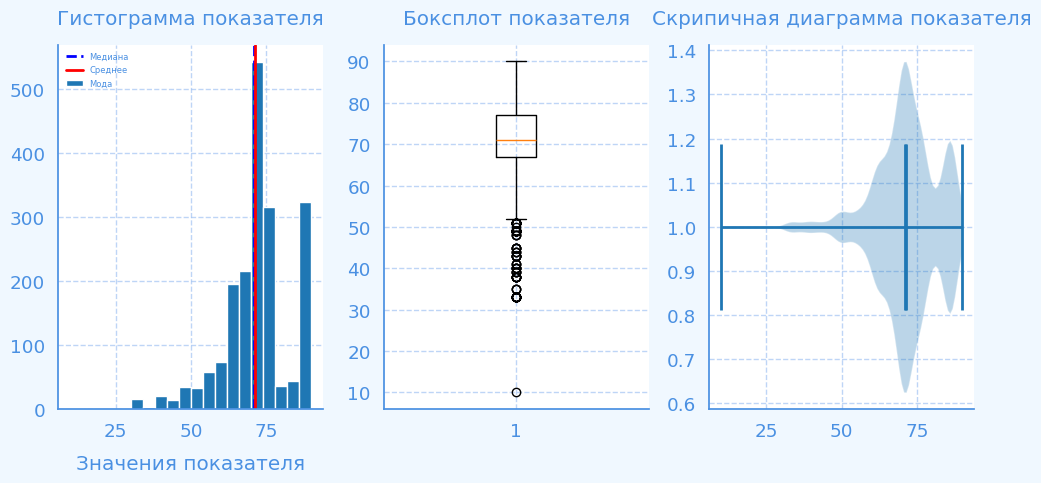

Показатели описательной статистики
count    1924.000000
mean       71.284823
std        10.661431
min        10.000000
25%        67.000000
50%        71.000000
75%        77.000000
max        90.000000
Name: age, dtype: float64
Мода в данных по показателю: 0    71
Name: age, dtype: int64
----------------------------------------------------------------------------------------------------
Исследовательский анализ rbc


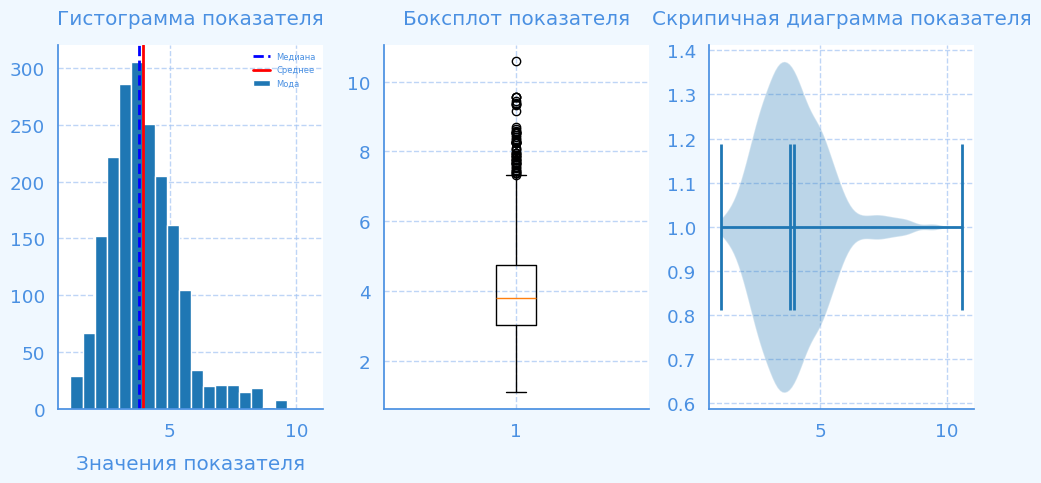

Показатели описательной статистики
count    1924.000000
mean        3.955686
std         1.385585
min         1.100000
25%         3.020000
50%         3.810000
75%         4.740000
max        10.580000
Name: rbc, dtype: float64
Мода в данных по показателю: 0    3.53
1    3.55
2    3.61
Name: rbc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ hgb


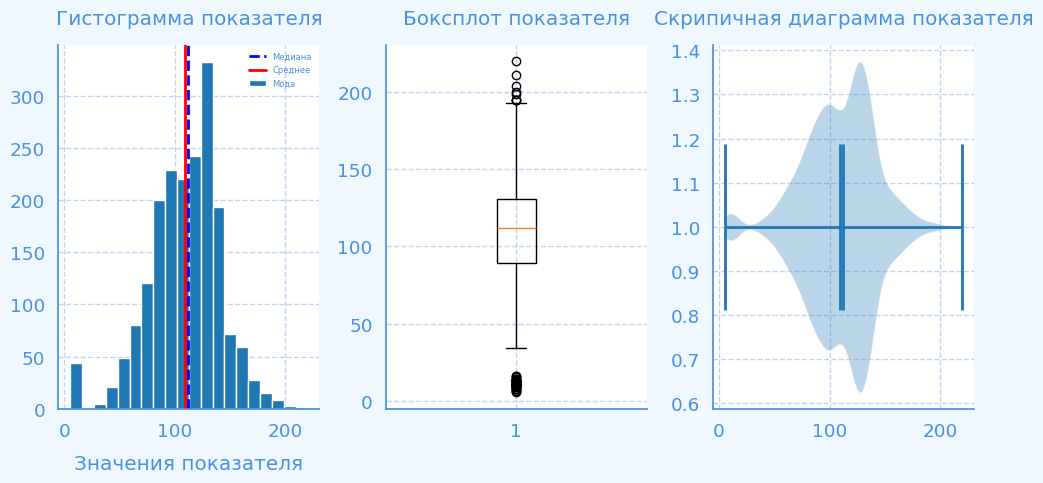

Показатели описательной статистики
count    1924.000000
mean      109.388950
std        32.461647
min         5.340000
25%        89.000000
50%       112.000000
75%       131.000000
max       220.000000
Name: hgb, dtype: float64
Мода в данных по показателю: 0    111.0
Name: hgb, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ hct


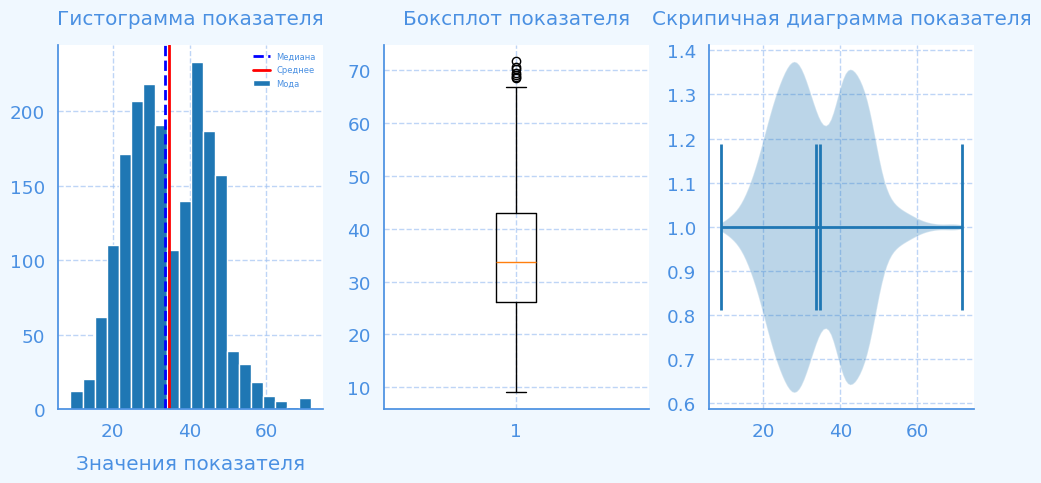

Показатели описательной статистики
count    1924.000000
mean       34.654984
std        10.620694
min         9.000000
25%        26.200000
50%        33.700000
75%        43.000000
max        71.700000
Name: hct, dtype: float64
Мода в данных по показателю: 0    28.0
Name: hct, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mcv


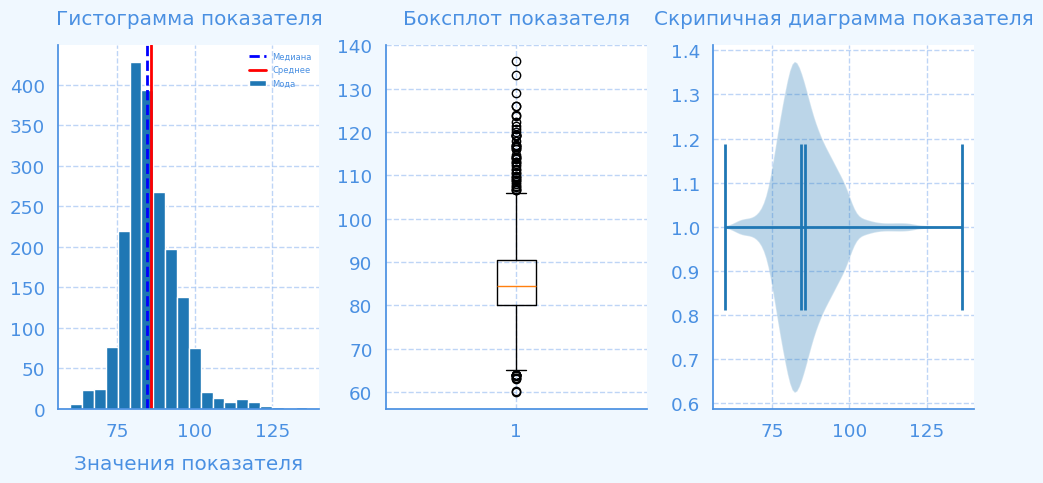

Показатели описательной статистики
count    1924.000000
mean       85.813015
std         8.905736
min        59.900000
25%        80.000000
50%        84.480000
75%        90.525000
max       136.300000
Name: mcv, dtype: float64
Мода в данных по показателю: 0    81.0
Name: mcv, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mchc


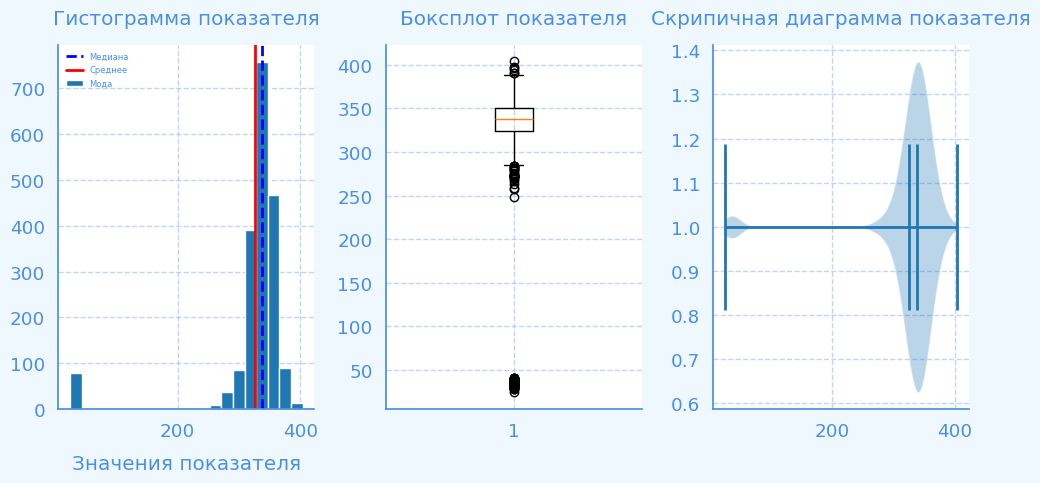

Показатели описательной статистики
count    1924.000000
mean      325.419636
std        62.922951
min        24.400000
25%       324.000000
50%       338.000000
75%       350.000000
max       404.000000
Name: mchc, dtype: float64
Мода в данных по показателю: 0    344.0
Name: mchc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ rdw


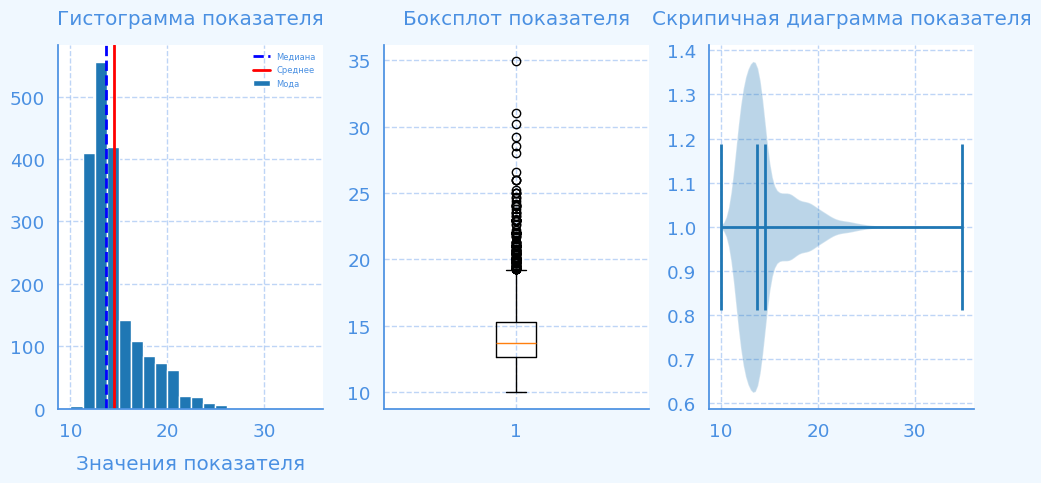

Показатели описательной статистики
count    1924.000000
mean       14.546788
std         2.866527
min        10.000000
25%        12.657500
50%        13.720000
75%        15.300000
max        34.900000
Name: rdw, dtype: float64
Мода в данных по показателю: 0    14.0
Name: rdw, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ rdv_sd


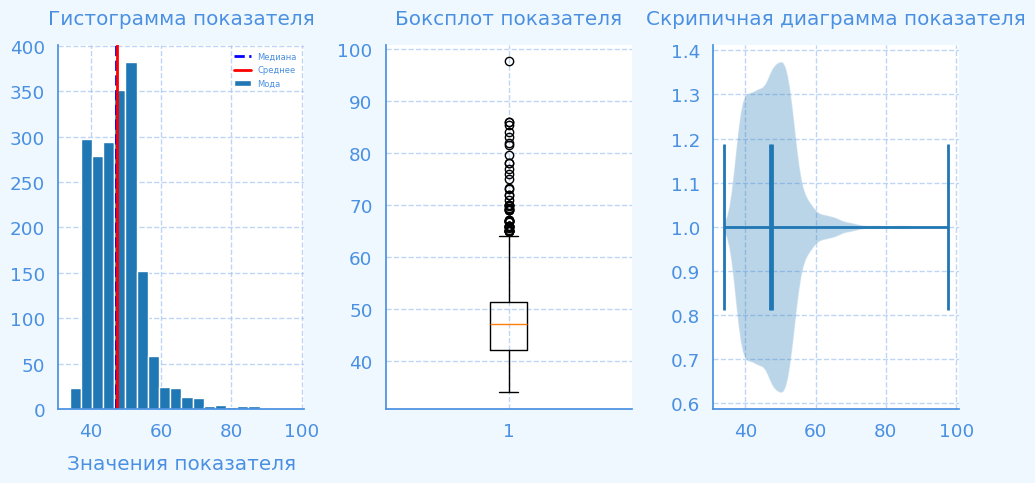

Показатели описательной статистики
count    1924.000000
mean       47.508015
std         7.079567
min        34.000000
25%        42.210000
50%        47.150000
75%        51.305000
max        97.600000
Name: rdv_sd, dtype: float64
Мода в данных по показателю: 0    52.0
Name: rdv_sd, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ret_abs


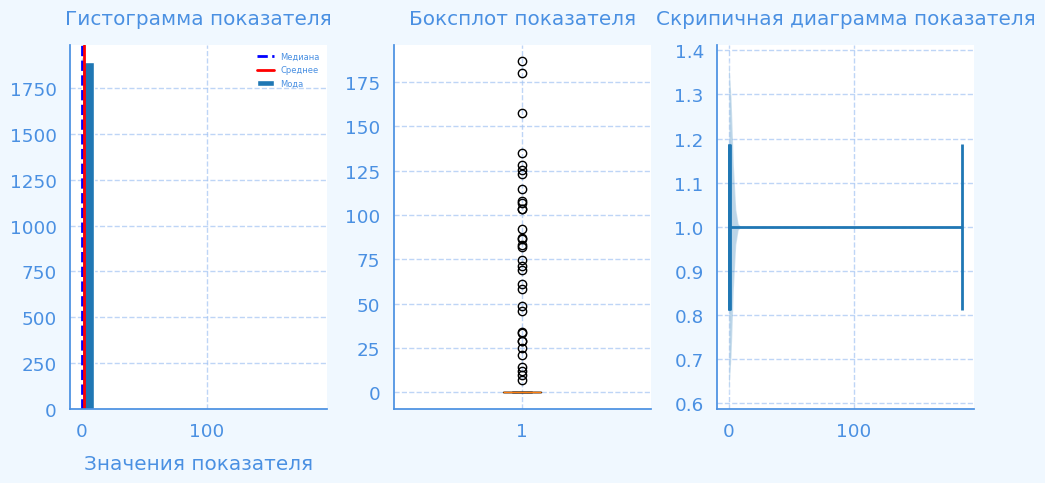

Показатели описательной статистики
count    1924.000000
mean        1.375156
std        12.094051
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       186.600000
Name: ret_abs, dtype: float64
Мода в данных по показателю: 0    0.0
Name: ret_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ cp


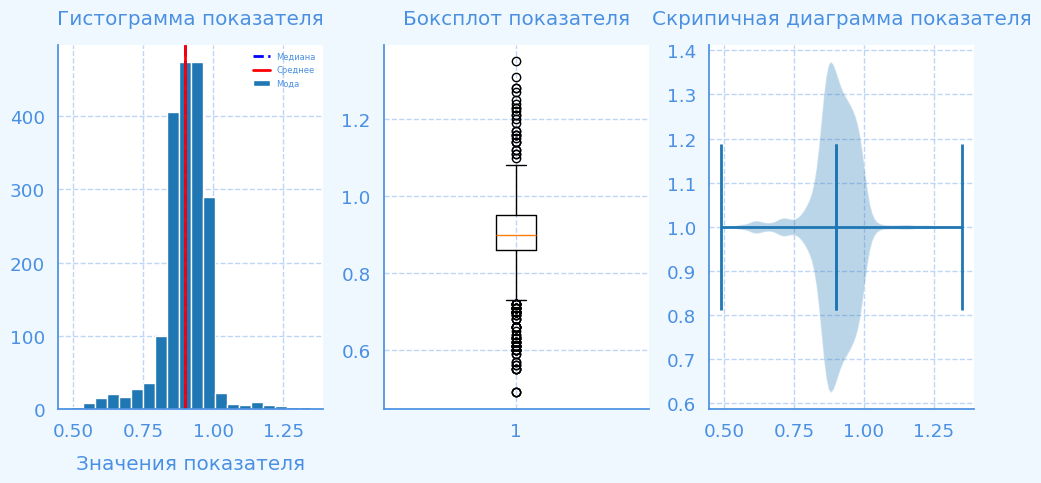

Показатели описательной статистики
count    1924.000000
mean        0.900785
std         0.084304
min         0.490000
25%         0.860000
50%         0.900000
75%         0.950000
max         1.350000
Name: cp, dtype: float64
Мода в данных по показателю: 0    0.86
Name: cp, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ wbc


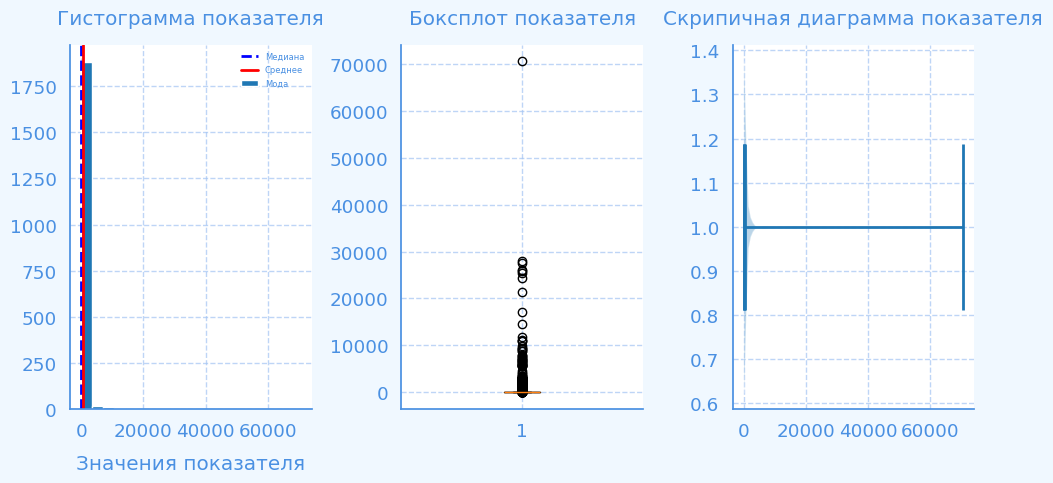

Показатели описательной статистики
count     1924.000000
mean       467.052853
std       2523.011525
min          0.000000
25%          4.680000
50%          7.735000
75%         13.477500
max      70500.000000
Name: wbc, dtype: float64
Мода в данных по показателю: 0    1.0
Name: wbc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ne_abs


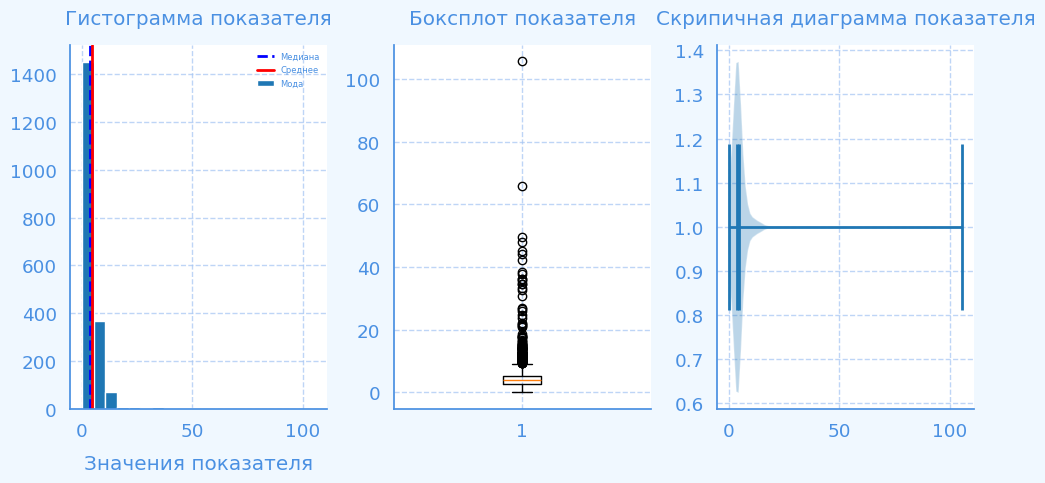

Показатели описательной статистики
count    1924.000000
mean        4.676752
std         5.112347
min         0.000000
25%         2.620000
50%         3.900000
75%         5.270000
max       105.700000
Name: ne_abs, dtype: float64
Мода в данных по показателю: 0    4.4
Name: ne_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ly_abs


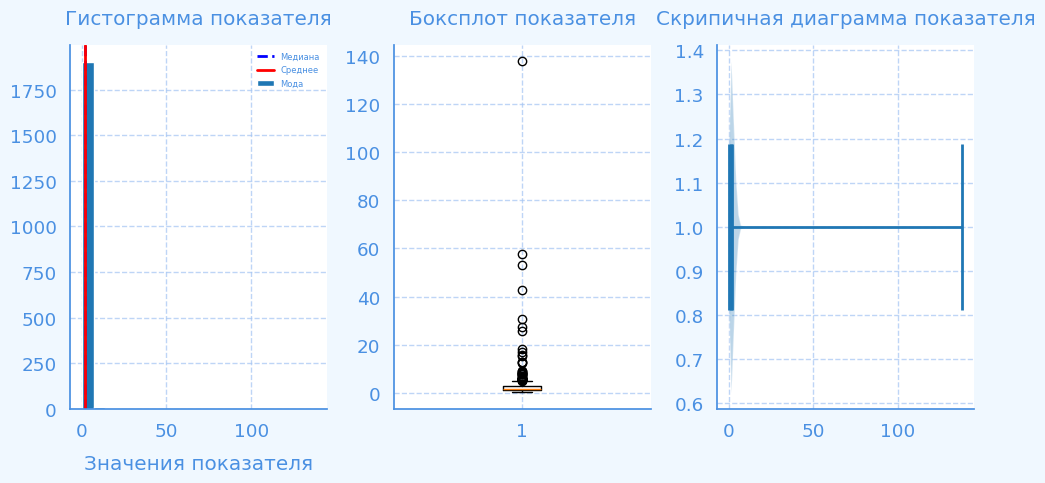

Показатели описательной статистики
count    1924.000000
mean        2.225437
std         4.084520
min         0.100000
25%         1.060000
50%         1.700000
75%         2.630000
max       137.900000
Name: ly_abs, dtype: float64
Мода в данных по показателю: 0    1.0
Name: ly_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mo_abs


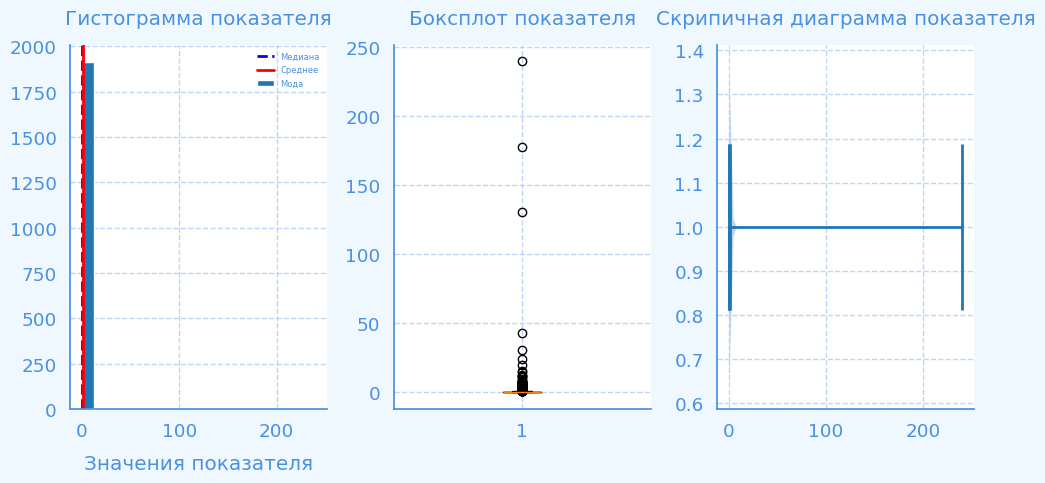

Показатели описательной статистики
count    1924.000000
mean        0.885930
std         7.603788
min         0.000000
25%         0.200000
50%         0.370000
75%         0.560000
max       239.930000
Name: mo_abs, dtype: float64
Мода в данных по показателю: 0    0.2
Name: mo_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ eo_abs


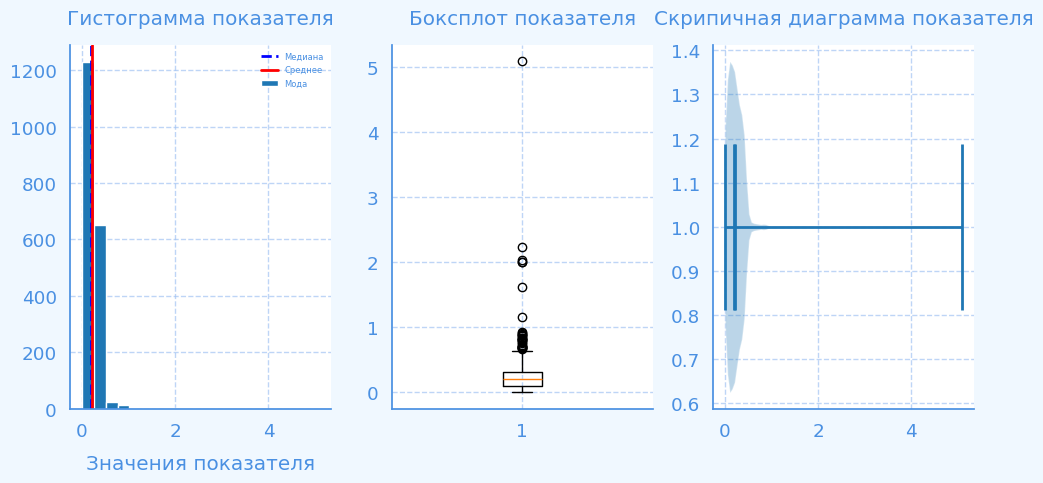

Показатели описательной статистики
count    1924.000000
mean        0.218576
std         0.207139
min         0.000000
25%         0.100000
50%         0.200000
75%         0.320000
max         5.090000
Name: eo_abs, dtype: float64
Мода в данных по показателю: 0    0.0
Name: eo_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ba_abs


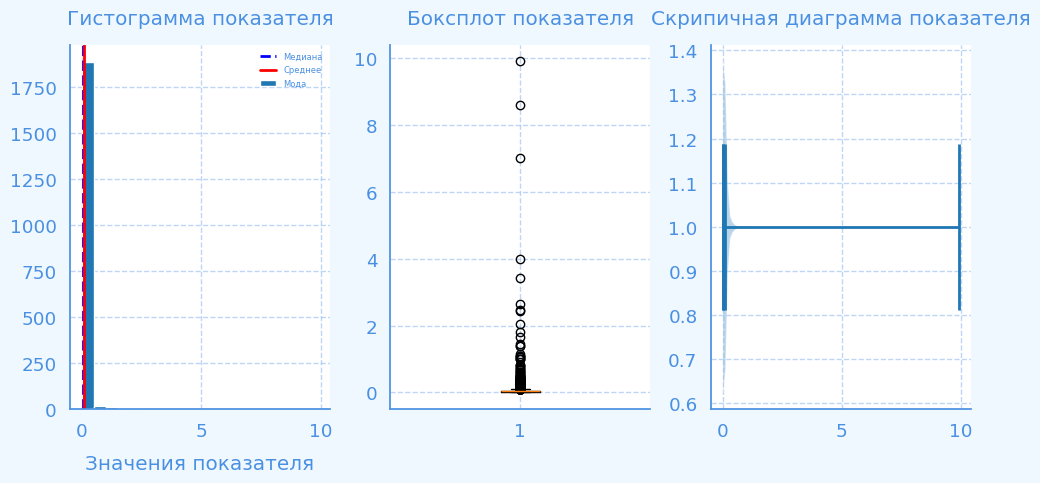

Показатели описательной статистики
count    1924.000000
mean        0.087225
std         0.393870
min         0.000000
25%         0.020000
50%         0.030000
75%         0.050000
max         9.900000
Name: ba_abs, dtype: float64
Мода в данных по показателю: 0    0.02
Name: ba_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ pal


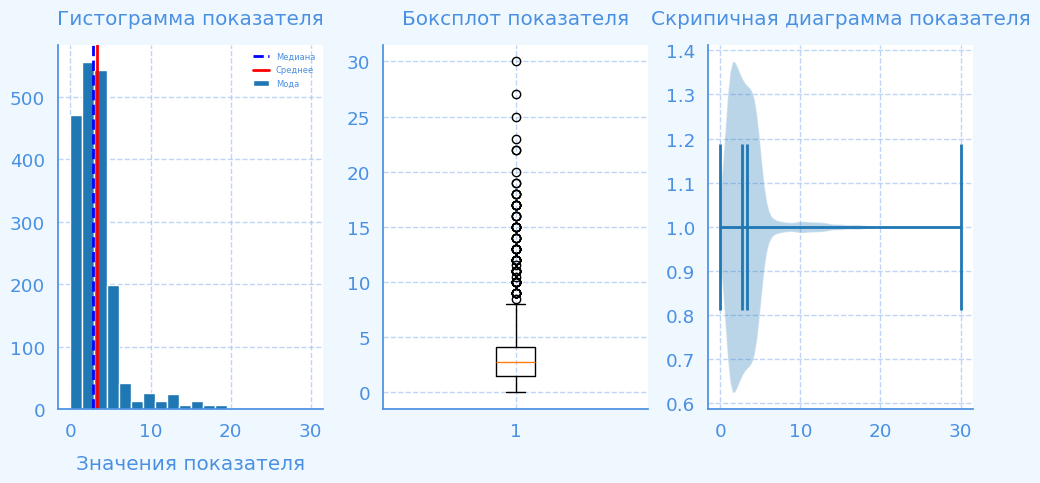

Показатели описательной статистики
count    1924.000000
mean        3.330156
std         2.938691
min         0.000000
25%         1.517500
50%         2.770000
75%         4.120000
max        30.000000
Name: pal, dtype: float64
Мода в данных по показателю: 0    1.0
Name: pal, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ seg


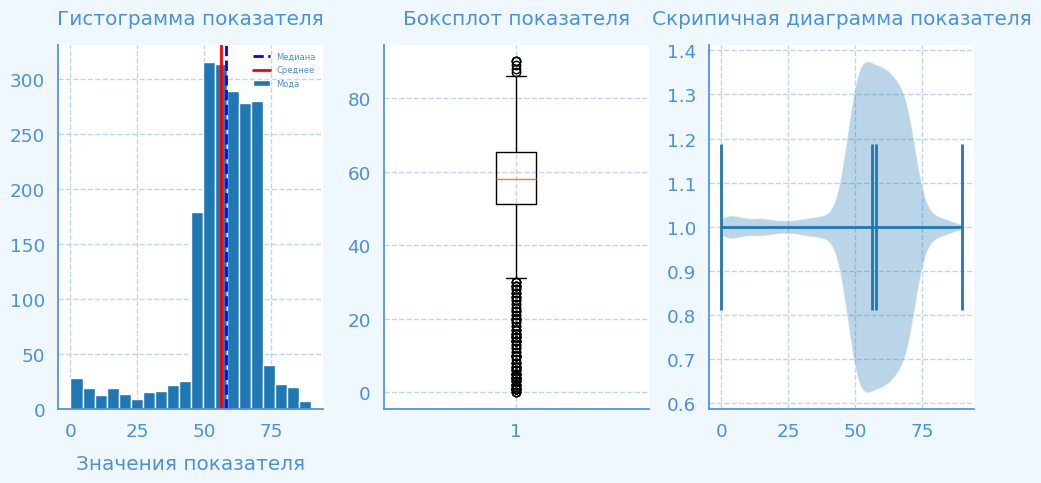

Показатели описательной статистики
count    1924.000000
mean       56.454662
std        14.298451
min         0.000000
25%        51.320000
50%        58.000000
75%        65.455000
max        90.000000
Name: seg, dtype: float64
Мода в данных по показателю: 0    60.0
Name: seg, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mxd_abs


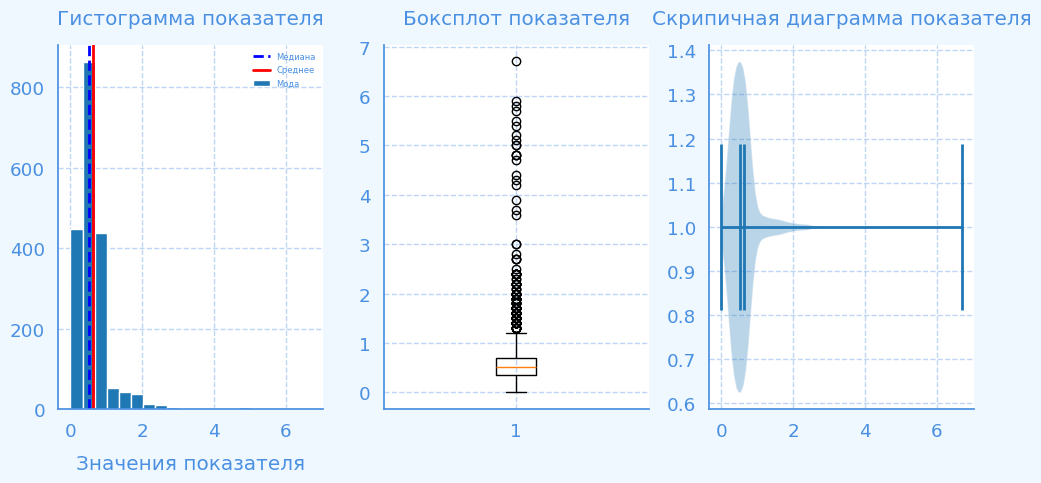

Показатели описательной статистики
count    1924.000000
mean        0.637001
std         0.589475
min         0.000000
25%         0.350000
50%         0.520000
75%         0.700000
max         6.700000
Name: mxd_abs, dtype: float64
Мода в данных по показателю: 0    0.7
Name: mxd_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ plasma


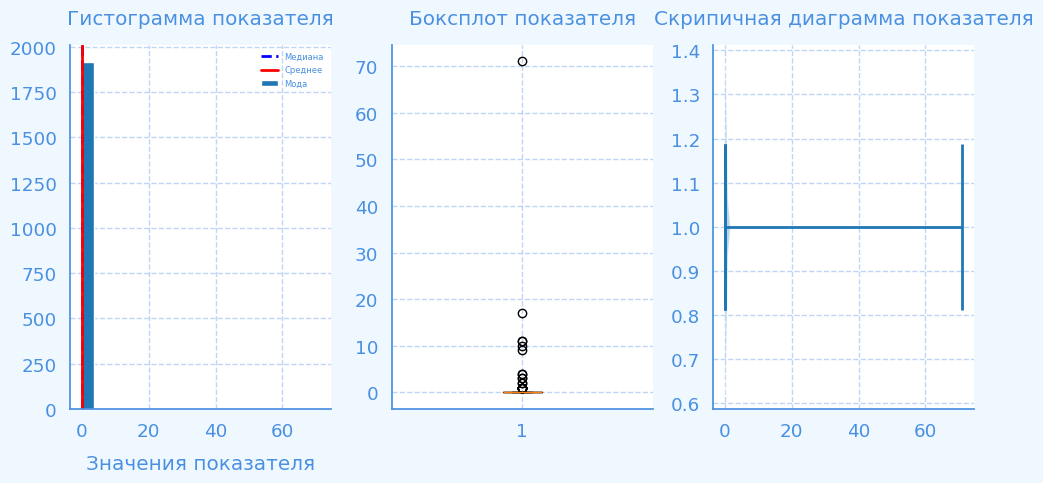

Показатели описательной статистики
count    1924.000000
mean        0.080561
std         1.737673
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        71.000000
Name: plasma, dtype: float64
Мода в данных по показателю: 0    0.0
Name: plasma, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ plt


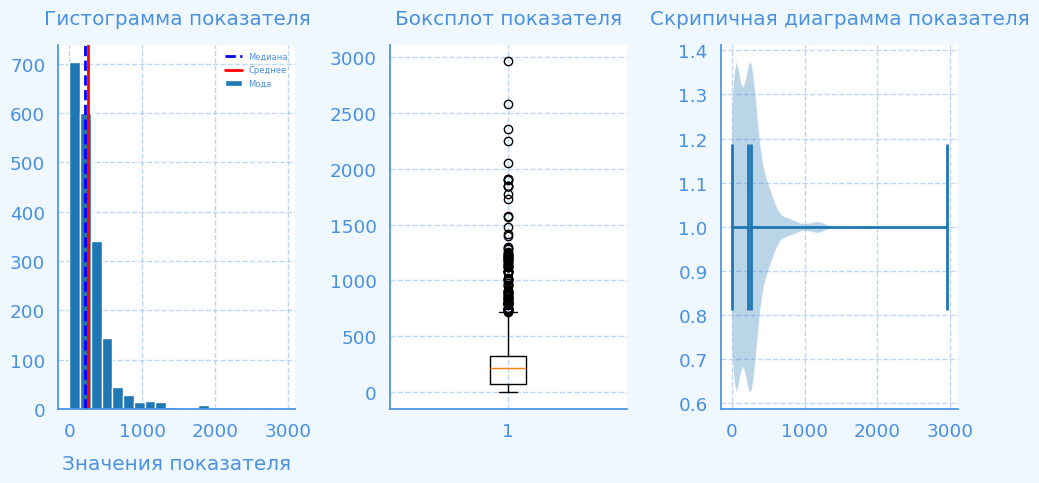

Показатели описательной статистики
count    1924.000000
mean      264.461788
std       275.091246
min         0.000000
25%        71.000000
50%       221.900000
75%       328.475000
max      2958.000000
Name: plt, dtype: float64
Мода в данных по показателю: 0    36.0
Name: plt, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mpv


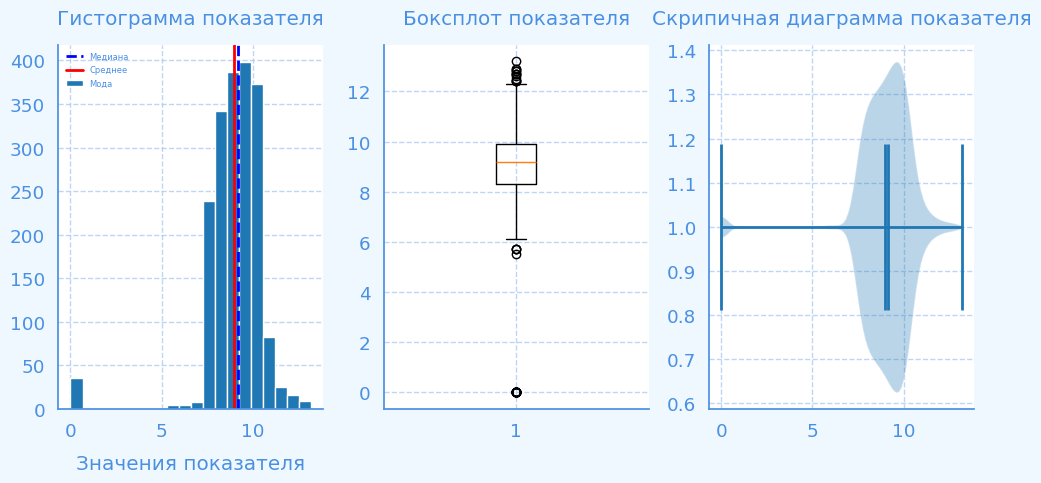

Показатели описательной статистики
count    1924.000000
mean        8.990130
std         1.622442
min         0.000000
25%         8.300000
50%         9.170000
75%         9.900000
max        13.200000
Name: mpv, dtype: float64
Мода в данных по показателю: 0    9.9
Name: mpv, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ pdw


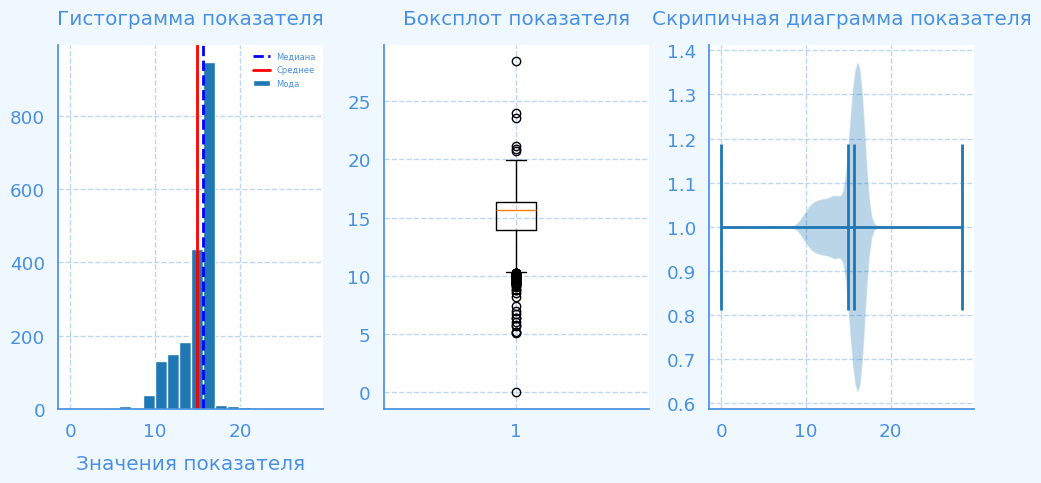

Показатели описательной статистики
count    1924.000000
mean       14.900702
std         2.168487
min         0.000000
25%        13.900000
50%        15.630000
75%        16.320000
max        28.400000
Name: pdw, dtype: float64
Мода в данных по показателю: 0    11.7
1    13.5
Name: pdw, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ plcr


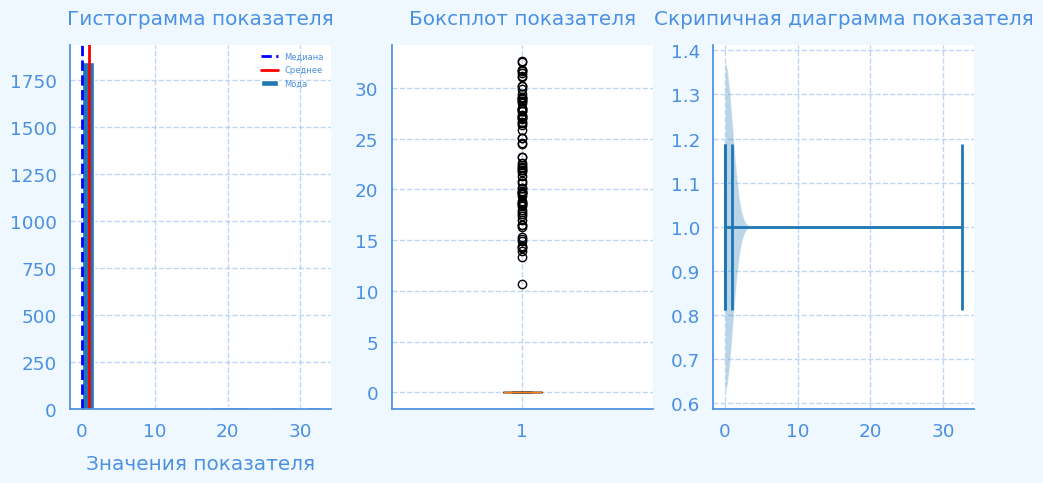

Показатели описательной статистики
count    1924.000000
mean        0.962422
std         4.763007
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        32.600000
Name: plcr, dtype: float64
Мода в данных по показателю: 0    0.0
Name: plcr, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ soe


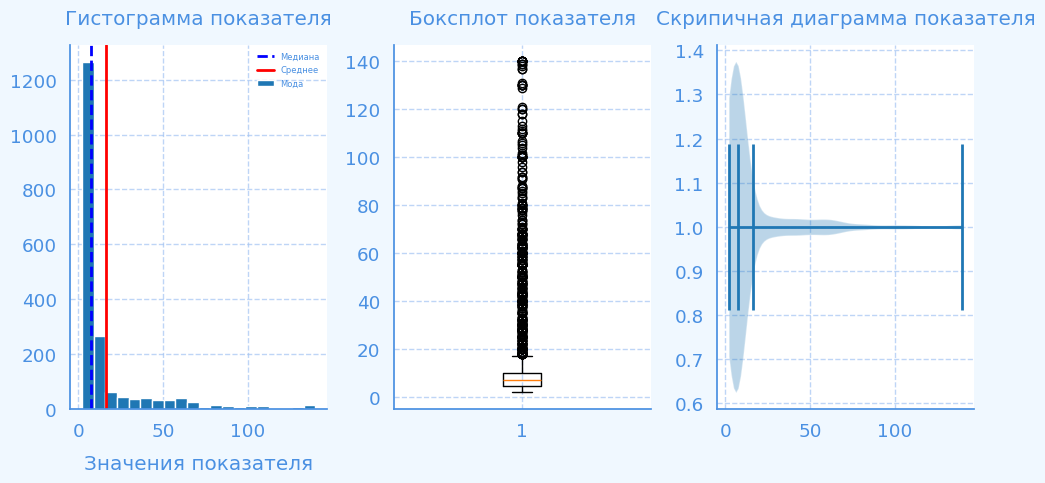

Показатели описательной статистики
count    1924.000000
mean       16.056622
std        24.190584
min         2.000000
25%         4.640000
50%         7.245000
75%         9.960000
max       140.000000
Name: soe, dtype: float64
Мода в данных по показателю: 0    4.0
Name: soe, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ myelo


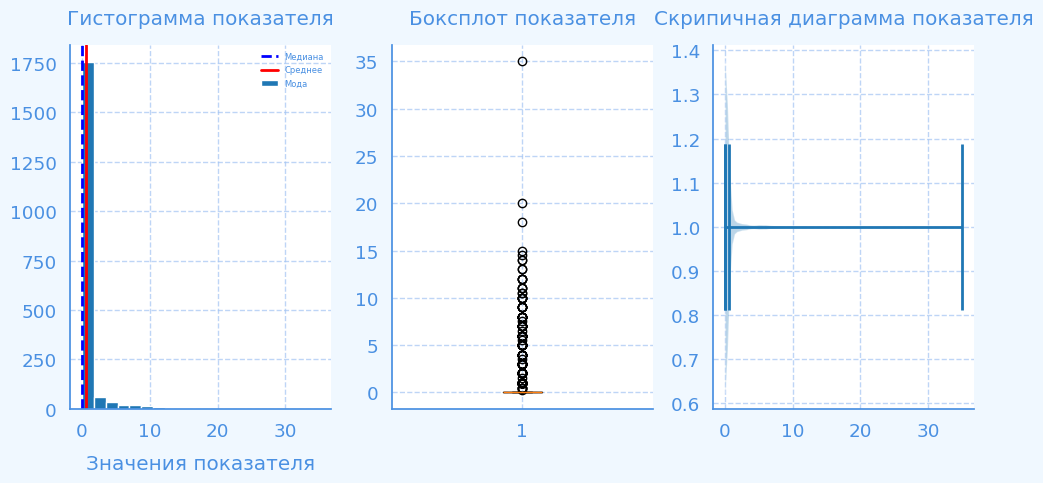

Показатели описательной статистики
count    1924.000000
mean        0.542775
std         2.041212
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        35.000000
Name: myelo, dtype: float64
Мода в данных по показателю: 0    0.0
Name: myelo, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ yunye


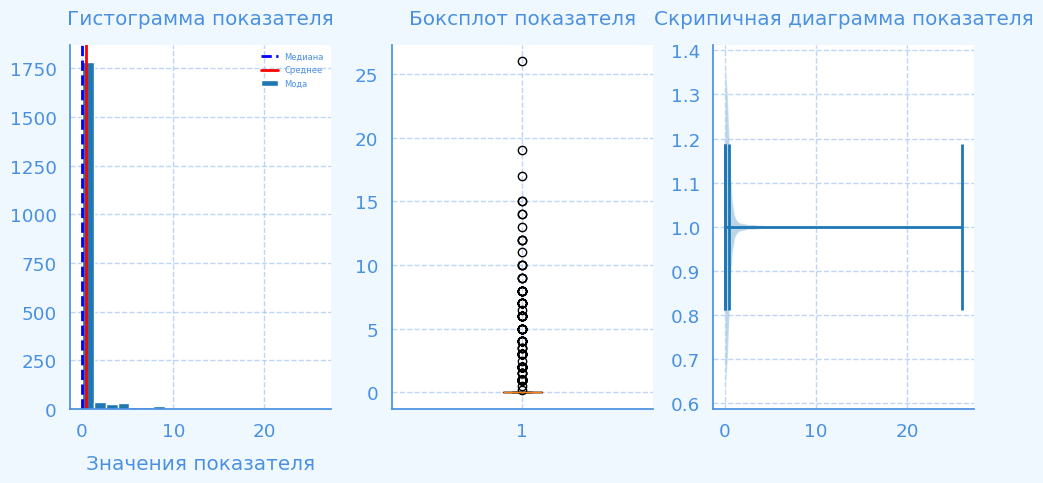

Показатели описательной статистики
count    1924.000000
mean        0.426819
std         1.732356
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        26.000000
Name: yunye, dtype: float64
Мода в данных по показателю: 0    0.0
Name: yunye, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ blasty


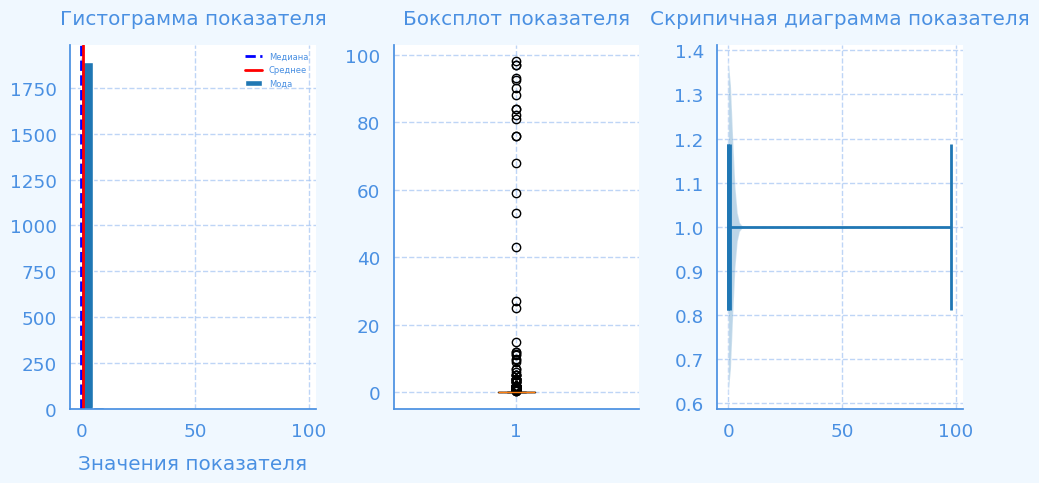

Показатели описательной статистики
count    1924.000000
mean        0.875520
std         7.720832
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        98.000000
Name: blasty, dtype: float64
Мода в данных по показателю: 0    0.0
Name: blasty, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ normobl_abs


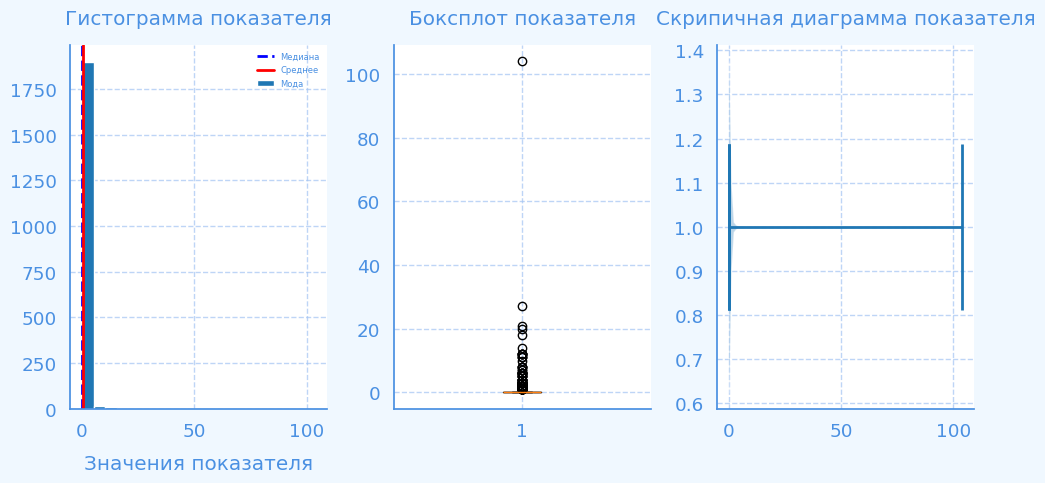

Показатели описательной статистики
count    1924.000000
mean        0.312890
std         2.797336
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       104.000000
Name: normobl_abs, dtype: float64
Мода в данных по показателю: 0    0.0
Name: normobl_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ promyelo


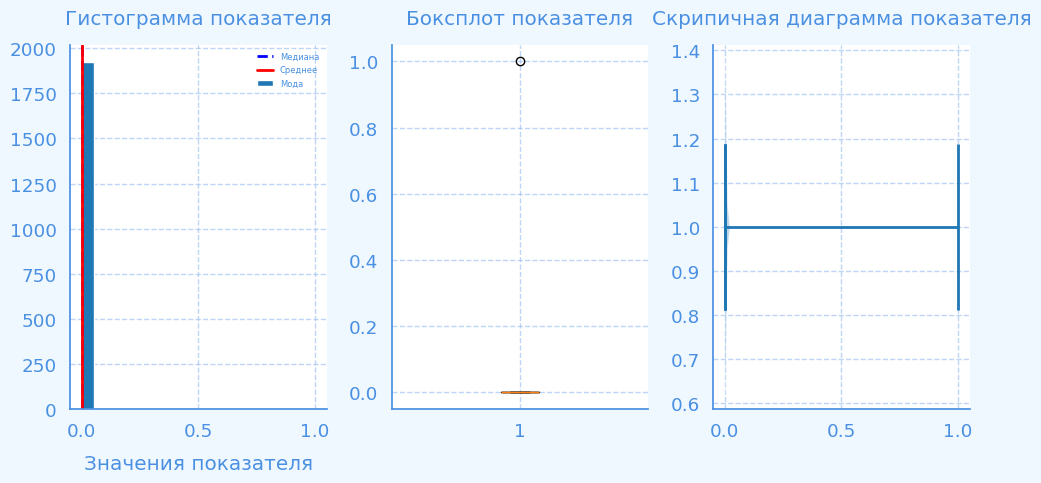

Показатели описательной статистики
count    1924.000000
mean        0.000520
std         0.022798
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: promyelo, dtype: float64
Мода в данных по показателю: 0    0.0
Name: promyelo, dtype: float64
----------------------------------------------------------------------------------------------------


In [58]:
for col in num_col:
  print(f'Исследовательский анализ {col}')
  analisys_num(df[col])
  print('-'*100)

Исследовательский анализ показателя class


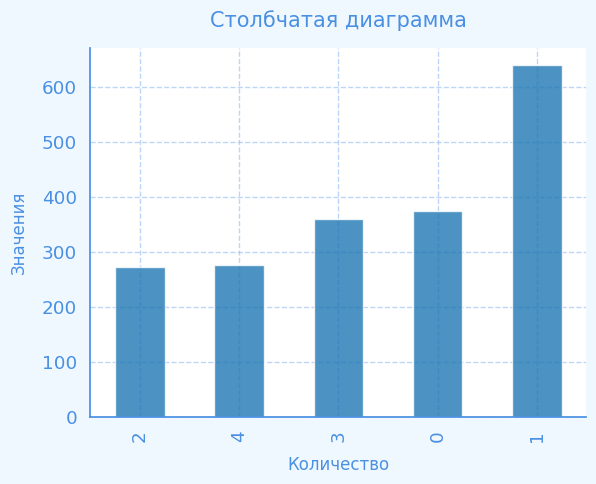

----------------------------------------------------------------------------------------------------


In [59]:
for col in cat_col:
  print(f'Исследовательский анализ показателя {col}')
  analisys_cat_plot(df[col])
  print('-'*100)

Исследовательский анализ показателя gender


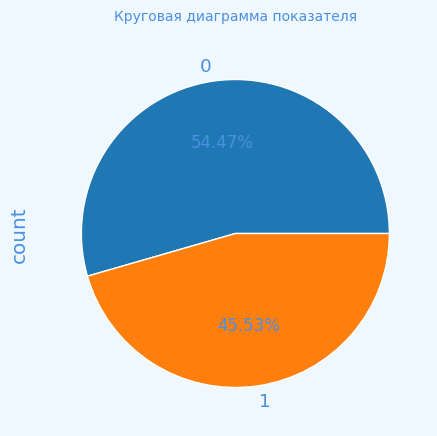

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя anisocytos


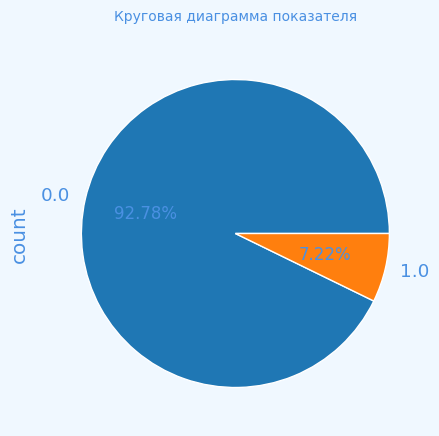

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя hypochromia


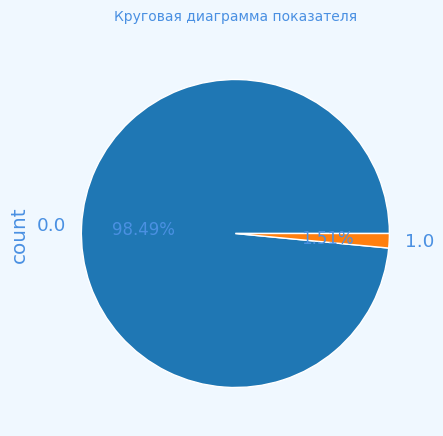

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя macrocytos


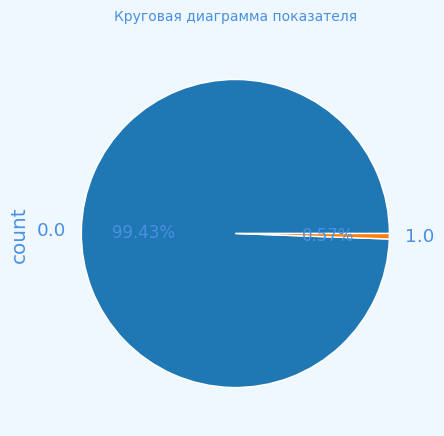

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя microcytos


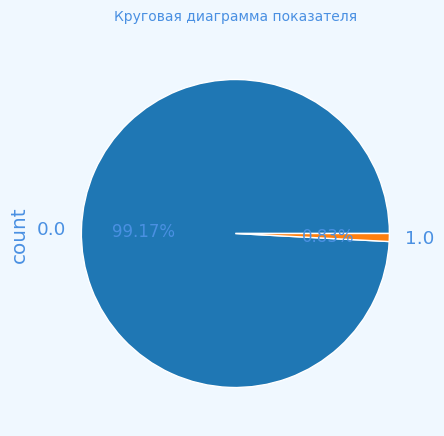

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя poikilocytos


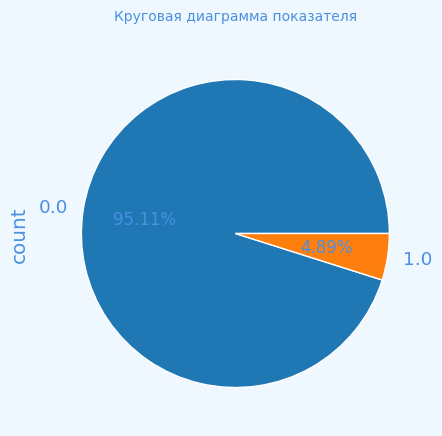

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя normoblast


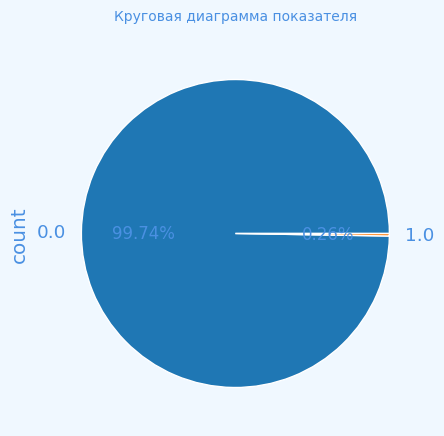

----------------------------------------------------------------------------------------------------


In [60]:
for col in bool_col:
  print(f'Исследовательский анализ показателя {col}')
  analisys_cat_pie(df[col])
  print('-'*100)

Обращает на себя внимание большое количество выбросов в категориальных качественных признаках, однако наличие их уникально для таких патологий как анемия и онкологический процесс. Удаление этих данных не даст возможности хорошо идентифицировать эти классы.

# <span style="color:#66CCFF"> Корреляционный анализ </span>

In [61]:
#подготовка данных для корреляции
#в связи с большим количеством данных и разбросом данных, не расчитать ранги
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [62]:
# QR-разложение для определения ранга корреляции
Q, R = np.linalg.qr(scaled_data)
qr_rank = np.sum(np.abs(R.diagonal()) > 1e-10)

print(f'QR-разложение (количество линейно независимых столбцов): {qr_rank}')
print(f'Количество столбцов: {scaled_data.shape[1]}')

QR-разложение (количество линейно независимых столбцов): 39
Количество столбцов: 39


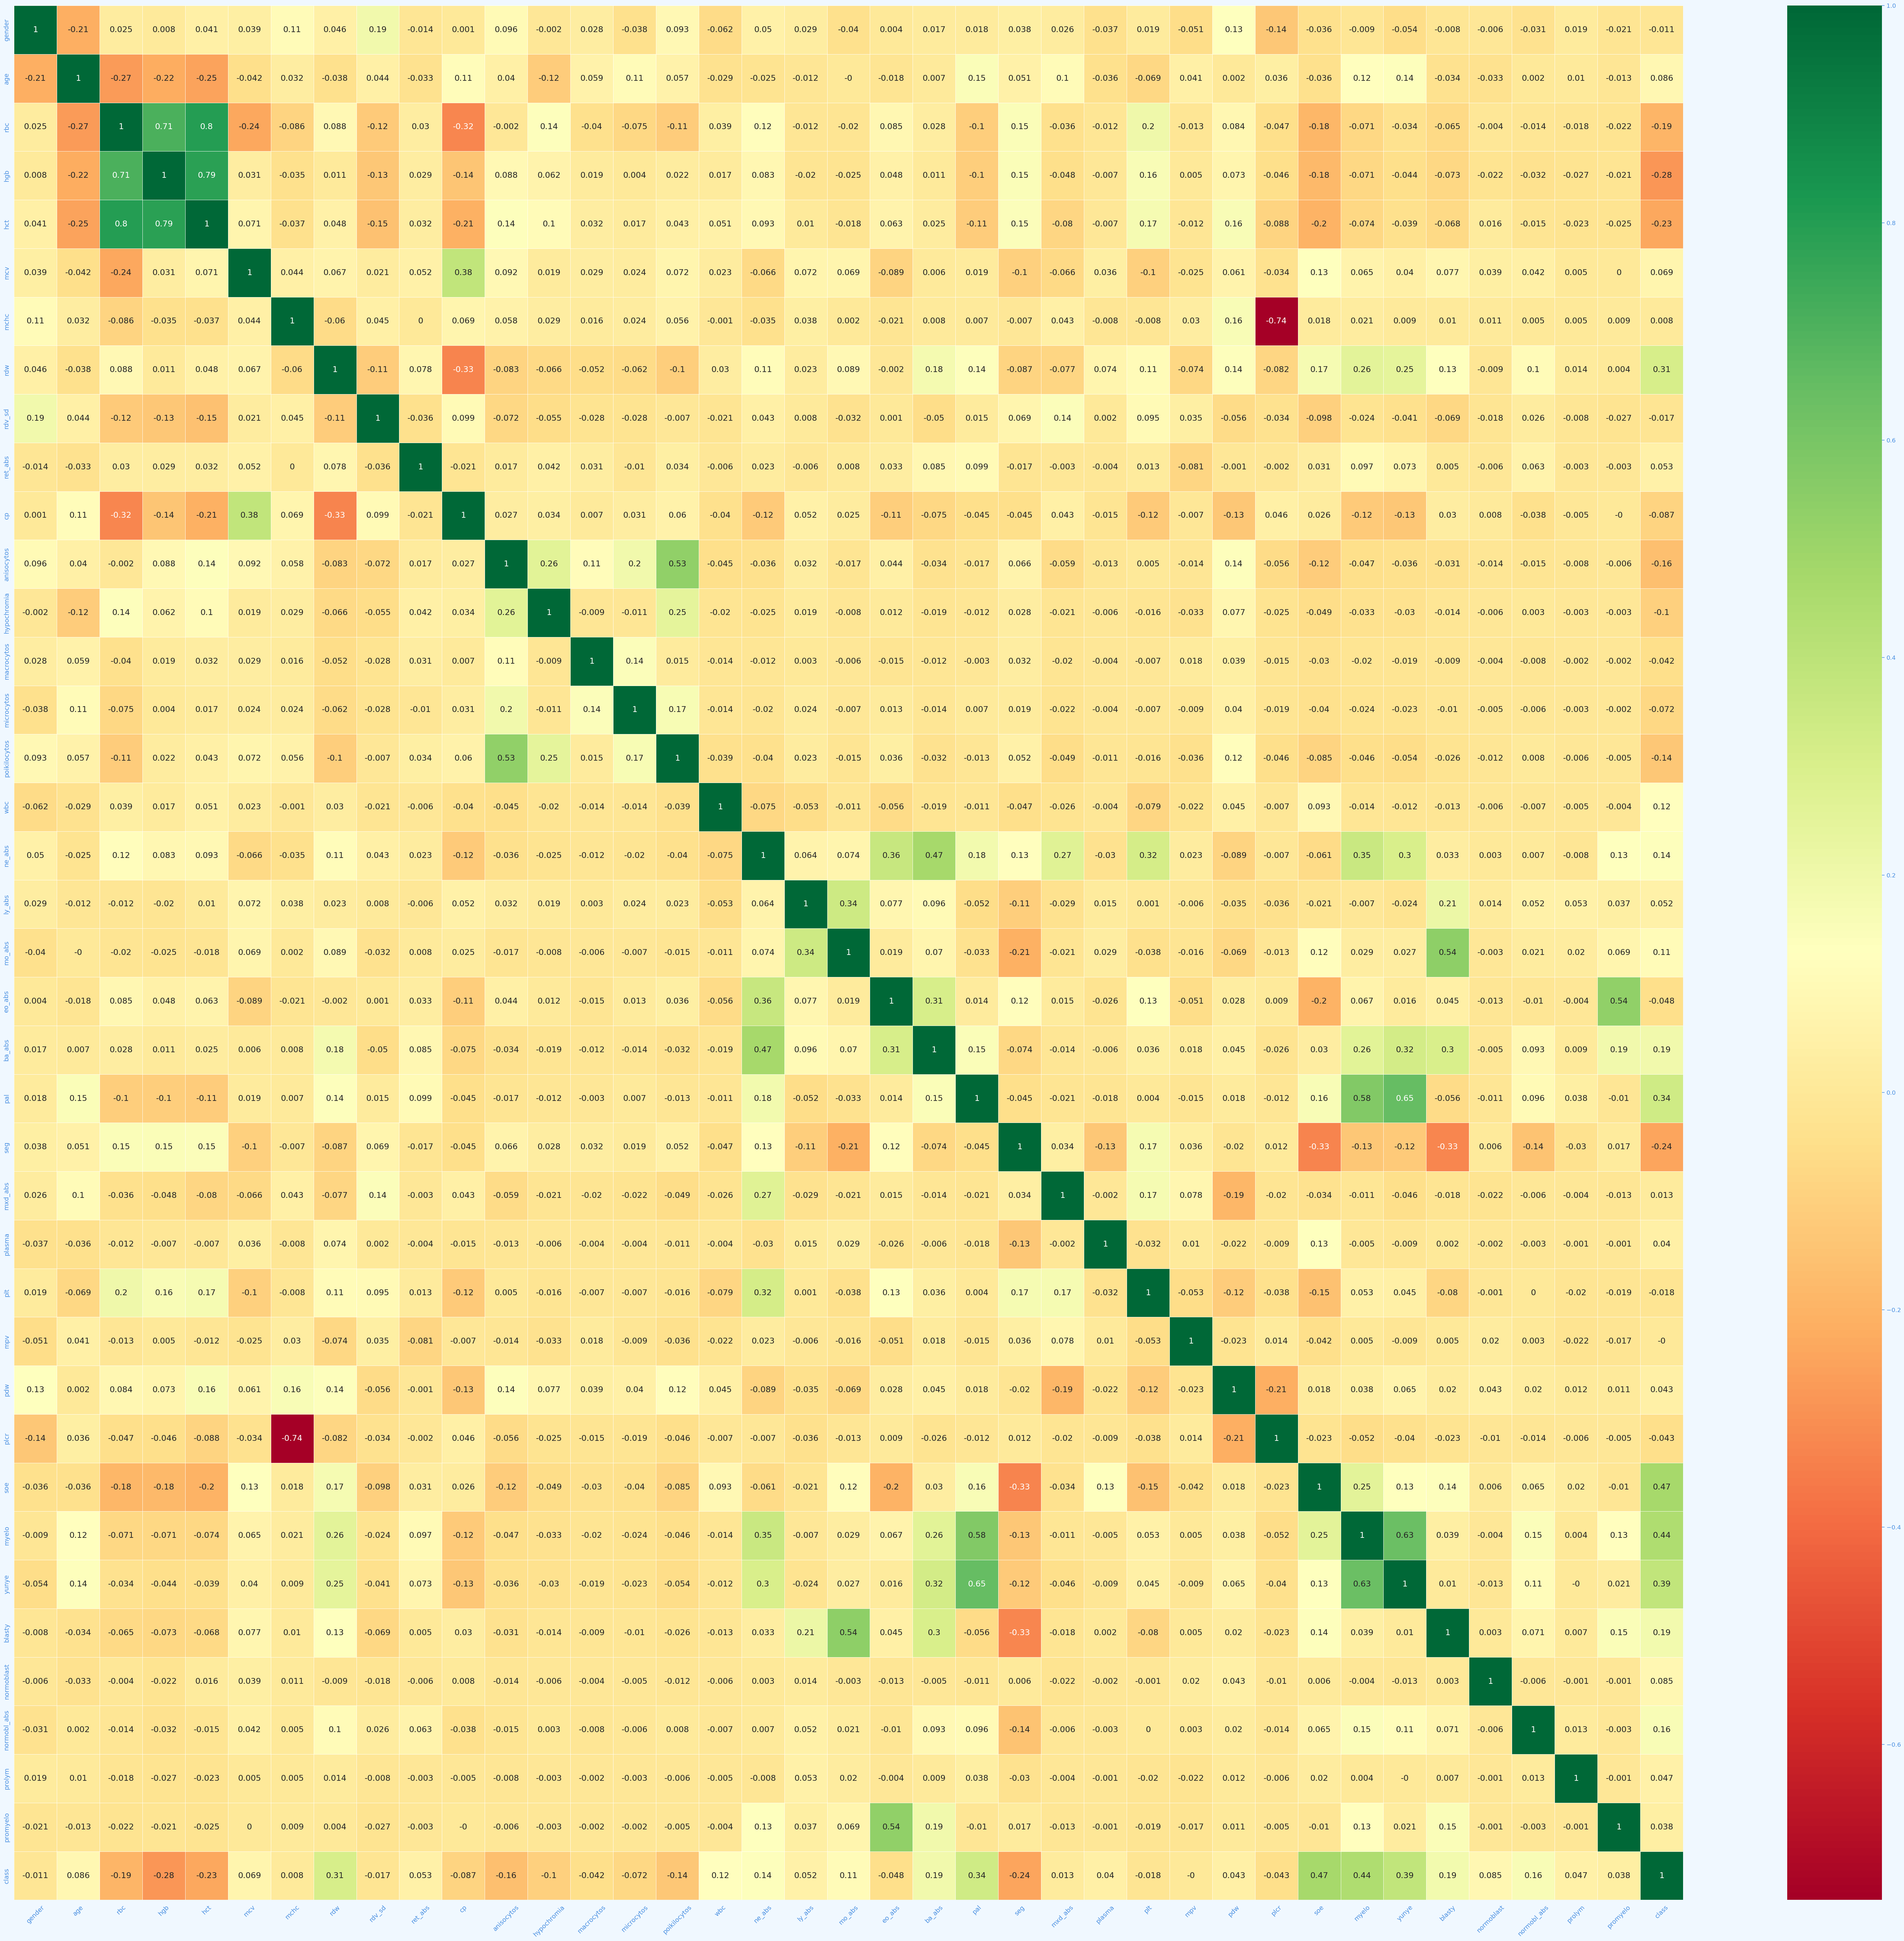

In [63]:
corr_matrix_df = round(df.corr(), 3)

fig, ax = plt.subplots(figsize=(65, 60))
sns.heatmap(
    corr_matrix_df,
    annot=True,
    cmap='RdYlGn',
    annot_kws={"fontsize": 18},
    xticklabels=corr_matrix_df.columns,
    yticklabels=corr_matrix_df.index,
    linewidths=.5
)
ax.tick_params(axis="x", labelrotation=45, labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.tight_layout()
plt.show()

In [64]:
#выведем пары с корреляцией выше 0.5
threshold = 0.5

high_correlations = (
    corr_matrix_df
    .stack()
    .reset_index()
    .rename(columns={0:'Корреляция'})
    .query('level_0 != level_1')
    .query(f'abs(Корреляция) >= {threshold}')
)

result = high_correlations.sort_values(by='Корреляция', ascending=False)[['level_0', 'level_1', 'Корреляция']]
display(result)
print(f'Количество пар с корреляцией выше 0.5 {len(result)} штук')

,level_0,level_1,Корреляция
158,hct,rbc,0.801
82,rbc,hct,0.801
121,hgb,hct,0.785
159,hct,hgb,0.785
81,rbc,hgb,0.714
119,hgb,rbc,0.714
1270,yunye,pal,0.646
890,pal,yunye,0.646
1279,yunye,myelo,0.634
1241,myelo,yunye,0.634


Количество пар с корреляцией выше 0.5 20 штук


Учитывая протеворечивость QR-разложения и матрицы корреляций, связь внутри данных не является линейной.

## Обучение и выбор моделей

In [65]:
df_clean = pd.read_csv('data/gpt_etalon_df_labeled.csv')
display(df_clean.info())
display(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1924 entries, 0 to 1923
Data columns (total 69 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   study_ID           1924 non-null   object 
 1   gender             1924 non-null   int64  
 2   age                1924 non-null   int64  
 3   rbc                1924 non-null   float64
 4   rbc_ql             1924 non-null   float64
 5   hgb                1924 non-null   float64
 6   hgb_ql             1924 non-null   float64
 7   hct                1924 non-null   float64
 8   hct_ql             1924 non-null   float64
 9   mcv                1924 non-null   float64
 10  mcv_ql             1924 non-null   float64
 11  mchc               1924 non-null   float64
 12  mchc_ql            1924 non-null   float64
 13  rdw                1924 non-null   float64
 14  rdw_ql             1924 non-null   float64
 15  rdv_sd             1924 non-null   float64
 16  rdv_sd_ql          1924 

None

,study_ID,gender,age,rbc,rbc_ql,hgb,hgb_ql,hct,hct_ql,mcv,mcv_ql,mchc,mchc_ql,rdw,rdw_ql,rdv_sd,rdv_sd_ql,ret_abs,ret_abs_ql,cp,cp_ql,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,wbc_ql,ne_abs,ne_abs_ql,ly_abs,ly_abs_ql,mo_abs,mo_abs_ql,eo_abs,eo_abs_ql,ba_abs,ba_abs_ql,pal,pal_ql,seg,seg_ql,mxd_abs,mxd_abs_ql,plasma,plt,plt_ql,mpv,mpv_ql,pdw,pdw_ql,plcr,plcr_ql,soe,soe_ql,myelo,yunye,blasty,normoblast,normobl_abs,normobl_abs_ql,prolym,promyelo,anemia_flag,inflammation_flag,cancer_flag,normal_flag,class_code,class_label
0,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,0,87,2.21,-1.0,84.00,-1.0,26.30,-1.0,119.10,1.0,320.00,0.0,21.30,1.0,52.14,0.0,0.0,-1.0,1.14,1.0,0.0,0.0,0.0,0.0,0.0,10.00,0.0,6.50,0.0,1.30,0.0,1.50,1.0,0.20,0.0,0.00,0.0,3.00,0.0,67.00,0.0,0.52,0.0,0.0,100.00,-1.0,9.66,0.0,15.04,0.0,0.0,-1.0,12.00,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True,False,5,anemia;cancer
1,05deb1af-cf40-11e9-80ba-901b0e633689_result_1803,0,87,1.91,-1.0,74.00,-1.0,23.60,-1.0,123.80,1.0,315.00,0.0,12.28,0.0,41.11,0.0,0.0,-1.0,0.91,0.0,0.0,0.0,0.0,0.0,0.0,9.10,0.0,4.12,0.0,1.59,0.0,0.52,0.0,0.13,0.0,0.01,0.0,2.61,0.0,66.94,0.0,0.69,0.0,0.0,264.40,0.0,7.85,0.0,15.50,0.0,0.0,-1.0,7.70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,False,False,1,anemia
2,05deb1af-cf40-11e9-80ba-901b0e633689_result_1805,0,87,4.55,0.0,132.75,0.0,44.74,0.0,81.56,0.0,336.95,0.0,20.50,1.0,43.02,0.0,0.0,-1.0,1.16,1.0,0.0,0.0,0.0,0.0,0.0,7.20,0.0,6.00,0.0,1.10,0.0,1.30,1.0,0.20,0.0,0.00,0.0,1.00,0.0,63.00,0.0,0.33,0.0,0.0,102.00,-1.0,8.60,0.0,15.62,0.0,0.0,-1.0,2.92,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,4,cancer
3,05deb1af-cf40-11e9-80ba-901b0e633689_result_1808,0,87,2.97,-1.0,107.00,-1.0,32.50,-1.0,109.40,1.0,329.00,0.0,22.20,1.0,38.79,0.0,0.0,-1.0,1.08,1.0,0.0,0.0,0.0,0.0,0.0,1388.37,1.0,4.30,0.0,1.00,0.0,1.40,1.0,0.10,0.0,0.00,0.0,3.00,0.0,57.00,0.0,0.68,0.0,0.0,101.00,-1.0,8.85,0.0,16.23,0.0,0.0,-1.0,16.00,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,True,True,False,False,3,anemia;inflammation
4,06a83aaa-8e27-11ec-ab52-0050568844e6_result_1005,1,51,7.29,1.0,146.00,0.0,48.50,0.0,66.50,-1.0,301.00,0.0,13.69,0.0,40.78,0.0,0.0,-1.0,0.90,0.0,0.0,0.0,0.0,0.0,0.0,11.90,1.0,4.21,0.0,2.35,0.0,0.54,0.0,0.23,0.0,0.02,0.0,3.81,0.0,61.90,0.0,0.44,0.0,0.0,319.97,0.0,8.47,0.0,15.35,0.0,0.0,-1.0,6.56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False,False,2,inflammation


### Препроцессинг набора данных

In [66]:
# Импортируем библиотеки
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from joblib import parallel_backend # Импортируем библиотеку для параллельных расчетов

metrics_dict = {} # В этот словарь будем сохранять все метрики


In [67]:
def bp_gridsearch(X_train: pd.DataFrame, y_train: pd.DataFrame,
                  model, params: dict, scoring: str, cv: int,
                  print_params=False, jobs=5):
    """Перебор гиперпараметров по сетке с ипользованием параллелизма

    Parameters
    ----------
        X_train : DataFrame
            объекты обучающей выборки
        y_train : DataFrame
            значения целевой переменной обучающей выборки
        model : any
            модель, для которой производится подбор гиперпараметров
        params : dict
            словарь с названиями гиперпараметрамов и всеми наборами значений
        scoring : str
            функция, которая будет минимизироваться в ходе кросс-валидации
        cv : int
            количество частей, на которые будет поделена выборка
        print_params : bool
            вывод в консоль оптимальных гиперпараметров
        jobs : int 
            количество параллельных потоков

    Returns
    -------
        best_params: dict
            наилучшие гиперпараметры
    """
    searcher = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring=scoring,
        cv=cv,
        verbose=0,
    )
    with parallel_backend('threading', n_jobs=jobs):
        searcher.fit(X_train, y_train)
    best_params = searcher.best_params_
    if print_params:
        print(f'Оптимальные гиперпараметры:\n{'=' * 27}\n'
            f'{pd.DataFrame.from_dict(best_params,
                                      orient='index',
                                      columns=['значение'])}\n')
    return best_params


In [68]:
def plot_imp(features: list, importance: np.ndarray, model_name=''):
    """Построение диаграммы важности признаков

    Parameters
    ----------
       features : list
         Названия признаков
       importance : np.ndarray
         Важность признаков из модели
       model_name : str 
         Наименование модели
    """
    # Сортируем массив со значениям и важности признаков
    order = np.argsort(importance)
    # Создаем датафрейм с парами название признака - важность в порядке убывания
    feat_data = pd.DataFrame({
    'features': features[order][::-1],
    'importance': importance[order][::-1]
    })
    # Округлим значение важности до 3 знаков после точки
    feat_data['importance'] = round(feat_data['importance'], 3)
    # Отображение диаграммы
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(feat_data, x='importance', y='features')
    ax.set(title=f'Важность признаков в модели {model_name}',
           xlabel='Важность', ylabel='Признаки')
    ax.bar_label(ax.containers[0], fontsize=8);


In [69]:
# перекодируем классы
class_dict = {
    0: ['normal'],
    1: ['anemia'],
    2: ['inflammation'],
    3: ['anemia;inflammation'],
    4: ['anemia;inflammation;cancer',
        'inflammation;cancer',
        'anemia;cancer', 'cancer']
}

# Создаем обратный словарь для поиска
reverse_dict = {}
for class_id, labels in class_dict.items():
    for label in labels:
        reverse_dict[label] = class_id

# Функция для поиска соответствующего класса
def find_class(label):
    # Проверяем точное соответствие
    if label in reverse_dict:
        return reverse_dict[label]
    # Если нет точного соответствия, возвращаем None или другое значение по умолчанию
    return None  # или можно вернуть -1 для "неизвестный класс"

# Создаем столбец class
df_clean['class'] = df_clean['class_label'].apply(find_class)

In [70]:
# Уберем столбцы с соответстветствием норме, чтоб не считать на входе по справочнику
df_clean = df_clean.loc[:, ~df_clean.columns.str.endswith('_ql')]
df_clean.drop(columns=['study_ID', 'anemia_flag',
                 'inflammation_flag', 'cancer_flag',
                 'normal_flag', 'class_code', 'class_label'], inplace=True)

In [71]:
cat_cols_list = ['gender', 'anisocytos', 'hypochromia',
            'macrocytos','microcytos', 'poikilocytos',
            'normoblast', 'promyelo']

num_cols_list = ['age', 'rbc', 'hgb', 'hct', 'mcv', 'mchc', 'rdw',
           'rdv_sd', 'ret_abs', 'cp', 'wbc', 'ne_abs', 'ly_abs',
           'mo_abs', 'eo_abs', 'ba_abs', 'pal', 'seg', 'mxd_abs',
           'plasma', 'plt', 'mpv', 'pdw', 'plcr', 'soe', 'myelo',
           'yunye', 'blasty', 'normobl_abs']

In [ ]:
# Разделение на массив признаков и целевую переменную
X = df_clean.drop(columns=['class'])
y = df_clean['class']

# Разделим набор данных на обучающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
# Дополнительный анализ с вычислением процентов
class_distribution = df_clean['class'].value_counts(normalize=True) * 100
print("Процентное распределение классов:")
print(class_distribution)

Процентное распределение классов:
class
1    33.212058
0    19.490644
3    18.711019
4    14.397089
2    14.189189
Name: proportion, dtype: float64


### Логистическая регрессия

In [74]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced', random_state=42)
y_pred = lr.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели LogisticRegression с гиперпараметрами по умолчанию:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['LogisticRegression'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']


Метрики модели LogisticRegression с гиперпараметрами по умолчанию:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87        82
           1       0.87      0.92      0.90       118
           2       0.82      0.77      0.79        52
           3       0.87      0.80      0.83        75
           4       1.00      0.91      0.95        58

    accuracy                           0.87       385
   macro avg       0.88      0.86      0.87       385
weighted avg       0.87      0.87      0.87       385



Оптимальные гиперпараметры:
              значение
class_weight  balanced
max_iter          1000
penalty           None
random_state        42

Метрики модели LogisticRegression с оптимальными гиперпараметрами:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        82
           1       0.94      0.94      0.94       118
           2       0.84      0.83      0.83        52
           3       0.93      0.92      0.93        75
           4       0.98      0.98      0.98        58

    accuracy                           0.92       385
   macro avg       0.92      0.92      0.92       385
weighted avg       0.92      0.92      0.92       385



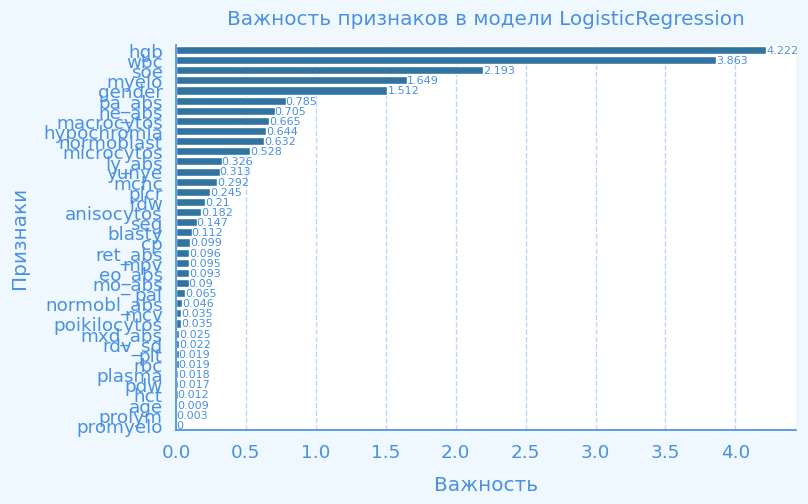

In [75]:
lr_params = {
    "penalty": [None, 'l2'],
    # "solver": ['lbfgs', 'liblinear'],
    # "l1_ratio": [0.5, 0.25],
    "max_iter": [1000, 2000],
    "class_weight": ['balanced'],
    "random_state": [42]
}
lr_bp = bp_gridsearch(X_train, y_train,
                   LogisticRegression(),
                   lr_params, 'accuracy', 3, True, 7)
best_lr = LogisticRegression(**lr_bp)
y_pred = best_lr.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели LogisticRegression с оптимальными гиперпараметрами:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['LogisticRegression_opt'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']
plot_imp(df_clean.columns, np.abs(lr.coef_[0]), 'LogisticRegression')


### Случайный лес


In [76]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
y_pred = rf.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели RandomForestClassifier с гиперпараметрами по умолчанию:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['RandomForest'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']
# plot_imp(df_clean.columns, np.abs(rf.feature_importances_), 'RandomForestClassifier')

Метрики модели RandomForestClassifier с гиперпараметрами по умолчанию:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       118
           2       0.98      0.98      0.98        52
           3       0.99      0.99      0.99        75
           4       1.00      1.00      1.00        58

    accuracy                           0.99       385
   macro avg       0.99      0.99      0.99       385
weighted avg       0.99      0.99      0.99       385



Оптимальные гиперпараметры:
                   значение
class_weight       balanced
max_depth              None
min_samples_leaf          1
min_samples_split         2
n_estimators            200
random_state             42

Метрики модели RandomForestClassifier с оптимальными гиперпараметрами:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       1.00      1.00      1.00       118
           2       0.96      0.96      0.96        52
           3       0.99      0.99      0.99        75
           4       1.00      0.98      0.99        58

    accuracy                           0.99       385
   macro avg       0.99      0.99      0.99       385
weighted avg       0.99      0.99      0.99       385



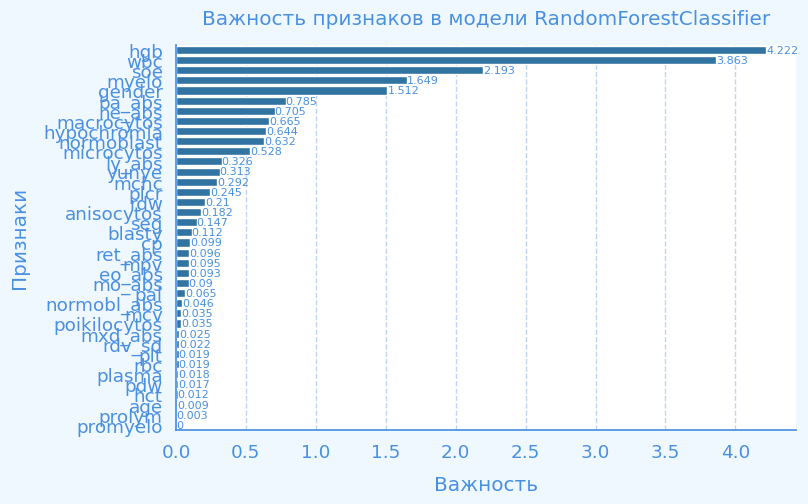

In [77]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced'],
    'random_state': [42]
}
rf_bp = bp_gridsearch(X_train, y_train,
                   RandomForestClassifier(),
                rf_params, 'accuracy', 3, True, 7)
best_rf = RandomForestClassifier(**rf_bp)
y_pred = best_rf.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели RandomForestClassifier с оптимальными гиперпараметрами:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['RandomForestClassifier_opt'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']
plot_imp(df_clean.columns, np.abs(lr.coef_[0]), 'RandomForestClassifier')

Метрики модели CatBoostClassifier с гиперпараметрами по умолчанию:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       118
           2       1.00      1.00      1.00        52
           3       1.00      1.00      1.00        75
           4       1.00      1.00      1.00        58

    accuracy                           1.00       385
   macro avg       1.00      1.00      1.00       385
weighted avg       1.00      1.00      1.00       385



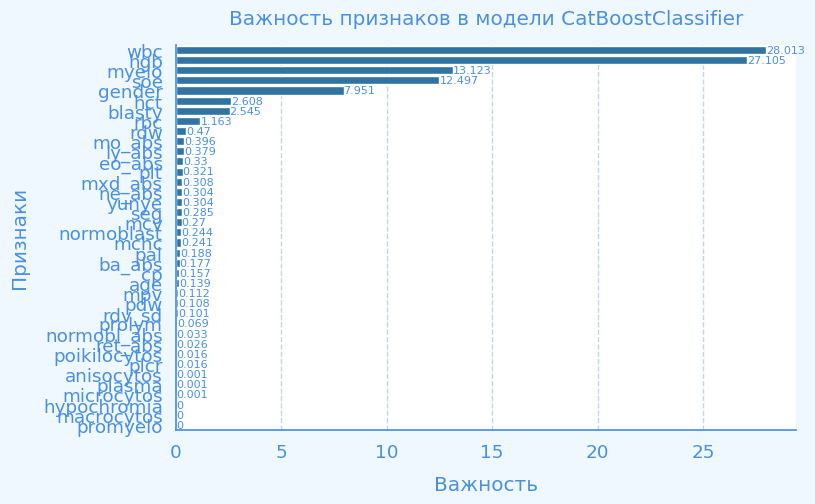

In [78]:

from catboost import CatBoostClassifier
catgb = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=False)
y_pred = catgb.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели CatBoostClassifier с гиперпараметрами по умолчанию:\n{'=' * 66}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['CatBoost'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']
plot_imp(df_clean.columns, np.abs(catgb.feature_importances_), 'CatBoostClassifier')


### Нейронная сеть


In [79]:
import tensorflow as tf
import keras
from keras.layers import Input, Dense
from keras.models import Sequential
from keras.backend import clear_session
from keras.callbacks import ModelCheckpoint

In [80]:
clear_session()

In [81]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])
model.summary()


/Users/alexeyalepko/.pyenv/versions/SF_312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

2025-08-05 08:24:29.827437: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-08-05 08:24:29.827582: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-08-05 08:24:29.827588: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1754349869.827933  745816 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1754349869.828254  745816 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL,

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,189 (20.27 KB)

 Trainable params: 5,189 (20.27 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
model.compile(
    loss='sparse_categorical_crossentropy',  # минимизируем кросс-энтропию
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint("checkpoints/epoch_{epoch}.keras")
]


In [83]:
model_history = model.fit(
                    X_train,
                    y_train,
                    batch_size=64,  # 64 объекта для подсчета градиента на каждом шаге
                    epochs=30,  # 10 проходов по датасету
                    callbacks=[callbacks],
                    validation_data=(X_test, y_test)
                    )


Epoch 1/30


2025-08-05 08:24:30.526348: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.2560 - loss: 1.7679 - val_accuracy: 0.4831 - val_loss: 1.3044
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5923 - loss: 1.1164 - val_accuracy: 0.5662 - val_loss: 1.0723
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6204 - loss: 0.9874 - val_accuracy: 0.6234 - val_loss: 0.9756
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6458 - loss: 0.8932 - val_accuracy: 0.6675 - val_loss: 0.9152
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6936 - loss: 0.8435 - val_accuracy: 0.7091 - val_loss: 0.8606
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6905 - loss: 0.8179 - val_accuracy: 0.7221 - val_loss: 0.8205
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7081 - loss: 0.7632 - val_accuracy: 0.7221 - val_loss: 0.7840
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6930 - loss: 0.7821 - val_accuracy: 0.7506 - val_loss: 0

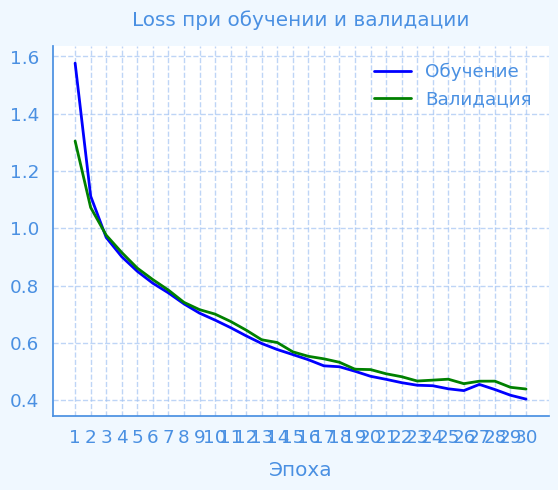

In [84]:
# Характеристики процесса обучения.
loss = model_history.history["loss"]
val_loss = model_history.history["val_loss"]
epochs = list(map(lambda epoch: epoch + 1, model_history.epoch))  # Преобразуем нумерацию эпох (с 0 -> с 1).

plt.figure()
plt.plot(epochs, loss, "b", label="Обучение")
plt.plot(epochs, val_loss, "g", label="Валидация")
plt.title("Loss при обучении и валидации")
plt.xlabel("Эпоха")
plt.xticks(range(1, 30 + 1))
# plt.ylim([0.2, 0.35])
plt.legend()
plt.show()


In [85]:
# Выбираем эпоху с лучшими показателями
model = keras.saving.load_model('checkpoints/epoch_30.keras')
y_pred = model.predict(X_test)
# y_pred = tf.squeeze(y_pred)
y_pred = np.argmax(y_pred, axis=1)
# np.array([1 if x >= 0.5 else 0 for x in y_pred])
print(f'Метрики модели NeuroNetwork:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['NeuralNetwork'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Метрики модели NeuroNetwork:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        82
           1       0.83      0.97      0.89       118
           2       0.80      0.77      0.78        52
           3       0.92      0.75      0.82        75
           4       0.98      0.90      0.94        58

    accuracy                           0.86       385
   macro avg       0.88      0.85      0.86       385
weighted avg       0.87      0.86      0.86       385



In [86]:

pd.DataFrame.from_dict(metrics_dict, orient='index').sort_values(by=['recall', 'f1-score'], ascending=False).round(3)

,precision,recall,f1-score,support
CatBoost,1.000,1.000,1.000,385.0
RandomForest,0.993,0.993,0.993,385.0
RandomForestClassifier_opt,0.987,0.986,0.987,385.0
LogisticRegression_opt,0.918,0.917,0.918,385.0
LogisticRegression,0.878,0.862,0.869,385.0
NeuralNetwork,0.875,0.849,0.859,385.0


In [87]:
# проверим топ моделей на переобучение
overf_met_dict = {}

def overfit_metrics(model, model_label):
    """Расчет разницы метрик тестового и тренировочного 
    набора для оценки переобучения моделей
    """
    # Сделаем предсказание на тестовом и тренировочном наборе
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    if model_label == 'NeuralNetwork':
        y_pred_test = np.argmax(y_pred_test, axis=1)
        y_pred_train = np.argmax(y_pred_train, axis=1)

    # Расчитаем тестовые и тренировочные метрики
    test_metrics = classification_report(y_pred_test, y_test, output_dict=True)
    train_metrics = classification_report(y_pred_train, y_train, output_dict=True)
    # Вычислим разницу в метриках между тренировочным и тестовым набором
    overf_met_dict[model_label] = {
        'accuracy_dif': train_metrics['accuracy'] - test_metrics['accuracy'],
        'recall_dif': train_metrics['macro avg']['recall'] - test_metrics['macro avg']['recall'],
        'f1-score_dif': train_metrics['macro avg']['f1-score'] - test_metrics['macro avg']['f1-score']
        }
    
best_model_dict = {
                   'LR': lr,
                   'LR opt': best_lr,
                   'RF': rf,
                   'RF opt': best_rf,
                   'CatBoost': catgb,
                   'NeuralNetwork': model, 
                   }

for l, m in best_model_dict.items():
    overfit_metrics(m, l)
pd.DataFrame.from_dict(overf_met_dict, orient='index').sort_values(by=['recall_dif', 'f1-score_dif']).round(3)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,accuracy_dif,recall_dif,f1-score_dif
LR,-0.003,-0.004,-0.003
CatBoost,0.000,0.000,0.000
RF,0.005,0.007,0.007
RF opt,0.010,0.013,0.013
NeuralNetwork,0.009,0.013,0.008
LR opt,0.055,0.058,0.060


### Выбор лучших моделей
Модель на базе алгоритма CatBoost показывает лучшее качество по метрикам и не демнострирует переобучения.
Следующая по характеристикам - RandomForestClassifire


In [88]:

# Сохраняем инференсы лучших моделей

import joblib
joblib.dump(catgb, 'inference/best_model.pkl')

# model.save("inference/model_classification.keras")

['inference/best_model.pkl']

## Обучение моделей и выбор лучшей для кластеризации данных

In [89]:
RANDOM_STATE = 42

In [90]:
df.head(2)

,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,cp,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,ne_abs,ly_abs,mo_abs,eo_abs,ba_abs,pal,seg,mxd_abs,plasma,plt,mpv,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo,class
0,0,87,2.21,84.0,26.3,119.1,320.0,21.30,52.14,0.0,1.14,0.0,0.0,0.0,0.0,0.0,10.0,6.50,1.30,1.50,0.20,0.00,3.00,67.00,0.52,0.0,100.0,9.66,15.04,0.0,12.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,4
1,0,87,1.91,74.0,23.6,123.8,315.0,12.28,41.11,0.0,0.91,0.0,0.0,0.0,0.0,0.0,9.1,4.12,1.59,0.52,0.13,0.01,2.61,66.94,0.69,0.0,264.4,7.85,15.50,0.0,7.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [91]:
numeric_data = df[num_col].copy()

In [92]:
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()
scaled_features = robust_scaler.fit_transform(numeric_data)

In [93]:
normalized_data = pd.DataFrame(scaled_features, columns=numeric_data.columns)

In [94]:
final_data = pd.concat([normalized_data, df[cat_col], df [bool_col]], axis=1)

In [95]:
print('Код не упал!')

Код не упал!


### Ближайщие соседи

In [96]:
#подберем оптимальное количество кластеров
sum_squared_distances = []

In [97]:
 RANDOM_STATE = 42
 Ks = range(1, 11)

In [98]:
from sklearn.cluster import KMeans
for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans.fit(final_data)
    sum_squared_distances.append(kmeans.inertia_)

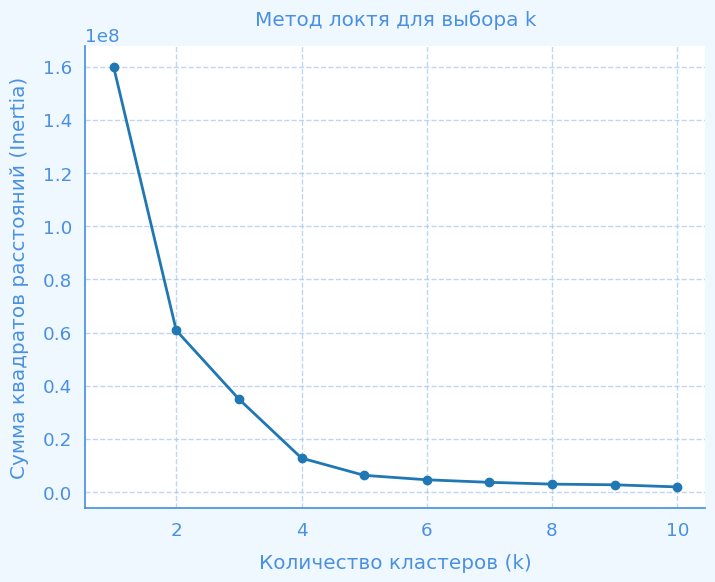

In [99]:
plt.figure(figsize=(8, 6))
plt.plot(Ks, sum_squared_distances, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний (Inertia)')
plt.title('Метод локтя для выбора k')
plt.show()

In [100]:
k_best = 4

In [101]:
kmeans_best = KMeans(n_clusters=k_best, random_state=RANDOM_STATE)
kmeans_best.fit(final_data)

KMeans(n_clusters=4, random_state=42)

In [102]:
centroids = kmeans_best.cluster_centers_

real_numerical_centroids = robust_scaler.inverse_transform(centroids[:, :len(num_col)])
numerical_centroid_df = pd.DataFrame(real_numerical_centroids, columns=num_col)

other_columns = cat_col + bool_col
centroides_other = centroids[:, len(num_col):]

other_centroid_df = pd.DataFrame(centroides_other, columns=other_columns)

centroid_df = pd.concat([numerical_centroid_df, other_centroid_df], axis=1)

centroid_df['Cluster'] = ['Cluster {}'.format(i + 1) for i in range(len(centroids))]

print("Итоговые центроиды:")
print(centroid_df)

Итоговые центроиды:
         age       rbc         hgb        hct        mcv        mchc  \
0  71.321106  3.952706  109.492031  34.625476  85.769506  325.532243   
1  70.125000  4.351250  126.336250  39.012500  84.485000  339.377500   
2  65.000000  3.340000   94.000000  27.400000  82.000000  343.000000   
3  69.735294  4.045588  100.151176  35.475588  88.644706  315.388529   

         rdw     rdv_sd       ret_abs        cp           wbc   ne_abs  \
0  14.543099  47.564567  1.406592e+00  0.900999    198.571079  4.75882   
1  15.373750  47.527500  2.220446e-16  0.860000  24486.172500  0.99625   
2  15.800000  53.820000  0.000000e+00  0.840000  70500.000000  4.08000   
3  14.519412  44.189118  0.000000e+00  0.900294   7609.062059  1.02000   

     ly_abs    mo_abs    eo_abs    ba_abs       pal        seg   mxd_abs  \
0  2.261223  0.901132  0.220845  0.088761  3.347480  56.633115  0.640888   
1  0.305000  0.138750  0.061250  0.013750  2.815000  58.306250  0.480000   
2  0.100000  0.13000

In [103]:
from sklearn.metrics import silhouette_score


labels = kmeans_best.labels_
silhouette_avg = silhouette_score(final_data, labels)
print(f'Средний силуэтный коэффициент: {silhouette_avg:.3f}')

Средний силуэтный коэффициент: 0.923


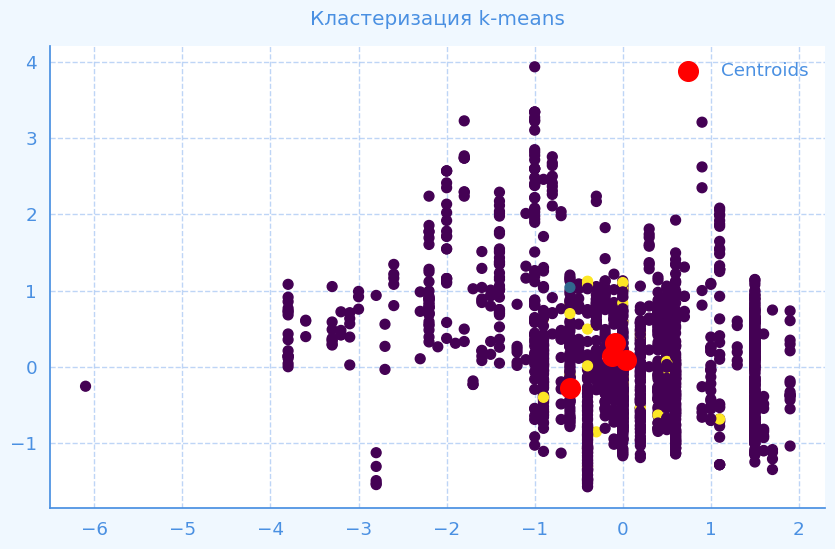

In [104]:
plt.figure(figsize=(10, 6))

plt.scatter(final_data.iloc[:, 0], final_data.iloc[:, 1], c=labels, cmap='viridis', s=50)

plt.scatter(centroids[:, 0], centroids[:, 1], marker='o', s=200, c='red', label='Centroids')

plt.title('Кластеризация k-means')
plt.legend()
plt.show()

## Agglomerative Clustering

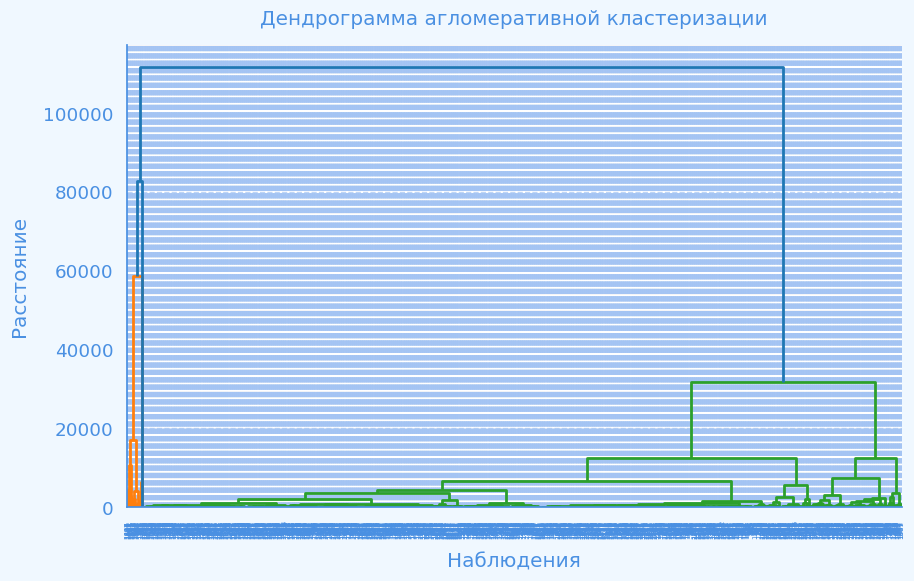

In [105]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(df, method='ward', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Дендрограмма агломеративной кластеризации')
plt.xlabel('Наблюдения')
plt.ylabel('Расстояние')
plt.show()

In [106]:
from sklearn.cluster import AgglomerativeClustering

silhouette_scores_ac = []

for k in Ks:
    clustering = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    labels = clustering.fit_predict(final_data)
    unique_labels = set(labels)
    if len(unique_labels) > 1:
      score = silhouette_score(final_data, labels)
      silhouette_scores_ac.append(score)
    else:
      silhouette_scores_ac.append(-1)

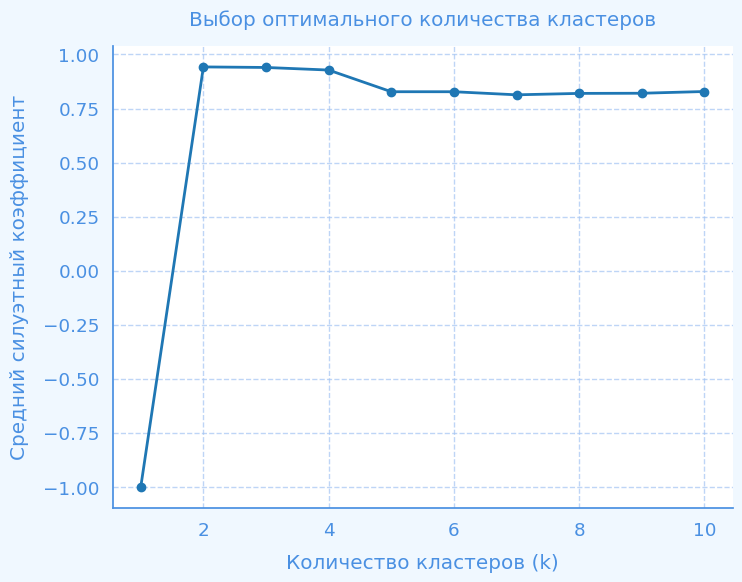

In [107]:
plt.figure(figsize=(8, 6))
plt.plot(Ks, silhouette_scores_ac, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Средний силуэтный коэффициент')
plt.title('Выбор оптимального количества кластеров')
plt.show()

In [108]:
#по дендрограмме оптимальное количесвто кластеров 4
#при автоматическом подборе количества кластеров сталкиваюсь с проблемой схлопывания в один кластер
#в принципе это видно и на диаграмме подбора
k_best_ac = 4

In [109]:
clustering_best = AgglomerativeClustering(n_clusters=k_best_ac, linkage='ward', metric='euclidean')
labels_ac = clustering_best.fit_predict(final_data)

In [110]:
df_ac = df.copy()

In [111]:
df_ac['cluster'] = labels_ac

In [112]:
representatives = df_ac.groupby('cluster').mean()
representatives

,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,cp,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,ne_abs,ly_abs,mo_abs,eo_abs,ba_abs,pal,seg,mxd_abs,plasma,plt,mpv,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo,class
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.460191,71.319533,3.954798,109.529273,34.642097,85.777298,325.557643,14.541858,47.558381,1.404352,0.900993,0.073779,0.015393,0.005839,0.008493,0.049894,204.884506,4.754368,2.259002,0.899889,0.220701,0.088668,3.345287,56.637803,0.640372,0.080149,268.353137,8.995626,14.88949,0.967357,15.614952,0.551645,0.433227,0.886677,0.002654,0.319533,0.007962,0.000531,1.733546
1,0.281250,69.718750,3.940000,97.930937,34.793125,88.372812,314.211250,14.605313,44.490313,0.000000,0.900937,0.000000,0.000000,0.000000,0.000000,0.000000,8230.023750,0.901875,0.740938,0.247813,0.124063,0.020000,2.515625,45.040312,0.460000,0.125000,79.883437,8.720625,15.33500,0.912500,34.042812,0.156250,0.156250,0.437500,0.000000,0.000000,0.000000,0.000000,2.750000
2,0.000000,65.000000,3.340000,94.000000,27.400000,82.000000,343.000000,15.800000,53.820000,0.000000,0.840000,0.000000,0.000000,0.000000,0.000000,0.000000,70500.000000,4.080000,0.100000,0.130000,0.280000,0.030000,4.810000,53.970000,0.800000,0.000000,11.000000,7.650000,15.48000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
3,0.000000,70.000000,4.354286,126.200000,38.528571,84.268571,337.002857,15.427143,46.845714,0.000000,0.852857,0.000000,0.000000,0.000000,0.000000,0.000000,25535.217143,1.128571,0.281429,0.154286,0.070000,0.014286,2.770000,59.698571,0.515714,0.000000,97.128571,8.934286,15.85000,0.000000,52.428571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.285714


In [113]:
silhouette_avg_ac = silhouette_score(final_data, labels_ac)
print(f'Средний силуэтный коэффициент: {silhouette_avg_ac:.3f}')

Средний силуэтный коэффициент: 0.928


In [114]:
from sklearn.decomposition import PCA

#для визуализации снизим размерность, т к аггломерация не предполагает наличие центроидов
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_ac.drop('cluster', axis=1))

In [115]:
reduced_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])
reduced_df['cluster'] = df_ac['cluster']

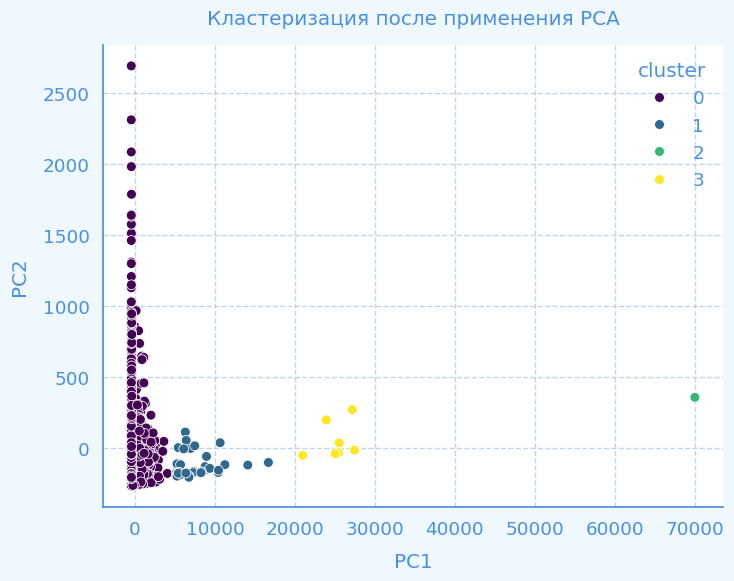

In [116]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=reduced_df, x='PC1', y='PC2', hue='cluster', palette='viridis', s=50)
plt.title('Кластеризация после применения PCA')
plt.show()

## DBSCAN

In [117]:
eps_values = np.linspace(0.1, 1.0, 10)
min_samples_values = range(2, 11)

best_score = -1
best_params = None

In [118]:
from sklearn.cluster import DBSCAN

for eps in eps_values:
    for min_samples in min_samples_values:
        #тренировка модели
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(final_data)

        #оценка качества кластеризации
        if len(set(labels)) > 1:
        #убедимся, что образовалось хотя бы два кластера
            score = silhouette_score(final_data, labels)
            if score > best_score:
                best_score = score
                best_params = {'eps': eps, 'min_samples': min_samples}

#лучшие параметры
print(f"Лучшие параметры: {best_params}")
print(f"Лучший силуэтный коэффициент: {best_score:.3f}")

Лучшие параметры: {'eps': 1.0, 'min_samples': 2}
Лучший силуэтный коэффициент: -0.676


In [119]:
dbscan_best = DBSCAN(eps=1.0, min_samples=2)
labels_dbscan = dbscan.fit_predict(final_data)

In [120]:
df_db = df.copy()
df_db['cluster'] = labels_dbscan

In [121]:
representatives_db = df_db.groupby('cluster').mean()
representatives_db

,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,cp,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,ne_abs,ly_abs,mo_abs,eo_abs,ba_abs,pal,seg,mxd_abs,plasma,plt,mpv,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo,class
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
-1,0.455301,71.284823,3.955686,109.38895,34.654984,85.813015,325.419636,14.546788,47.508015,1.375156,0.900785,0.072245,0.015073,0.005717,0.008316,0.048857,467.052853,4.676752,2.225437,0.88593,0.218576,0.087225,3.330156,56.454662,0.637001,0.080561,264.461788,8.99013,14.900702,0.962422,16.056622,0.542775,0.426819,0.87552,0.002599,0.31289,0.007796,0.00052,1.753119


In [122]:
#для визуализации снизим размерность, т к данный метод тоже не предполагает наличие центроидов
pca_db = PCA(n_components=2)
reduced_data_db = pca.fit_transform(df_db.drop('cluster', axis=1))

In [123]:
reduced_data_db = pd.DataFrame(reduced_data_db, columns=['PC1', 'PC2'])
reduced_data_db['cluster'] = df_db['cluster']

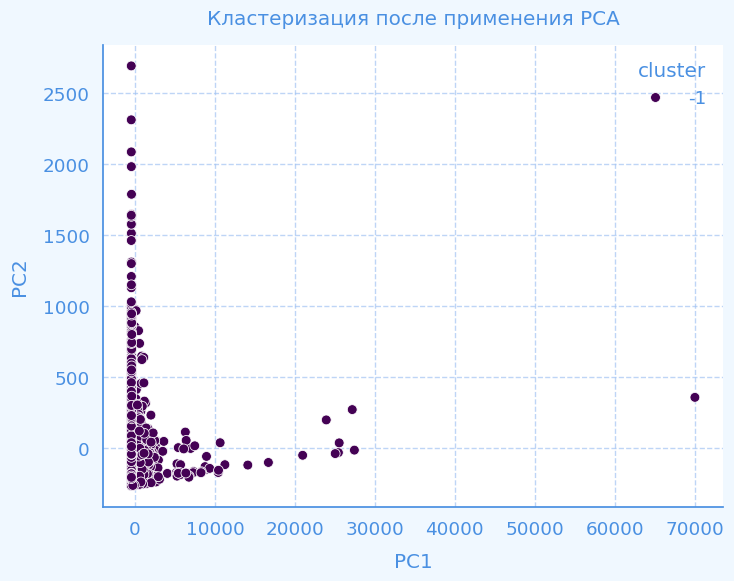

In [124]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=reduced_data_db, x='PC1', y='PC2', hue='cluster', palette='viridis', s=50)
plt.title('Кластеризация после применения PCA')
plt.show()

## Исследование данных полученных при разметке кластеров лучшей моделью

Исследуется разметка данных методом Agglomerative Clustering

In [125]:
df_ac.head(2)

,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,cp,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,ne_abs,ly_abs,mo_abs,eo_abs,ba_abs,pal,seg,mxd_abs,plasma,plt,mpv,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo,class,cluster
0,0,87,2.21,84.0,26.3,119.1,320.0,21.30,52.14,0.0,1.14,0.0,0.0,0.0,0.0,0.0,10.0,6.50,1.30,1.50,0.20,0.00,3.00,67.00,0.52,0.0,100.0,9.66,15.04,0.0,12.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,4,0
1,0,87,1.91,74.0,23.6,123.8,315.0,12.28,41.11,0.0,0.91,0.0,0.0,0.0,0.0,0.0,9.1,4.12,1.59,0.52,0.13,0.01,2.61,66.94,0.69,0.0,264.4,7.85,15.50,0.0,7.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0


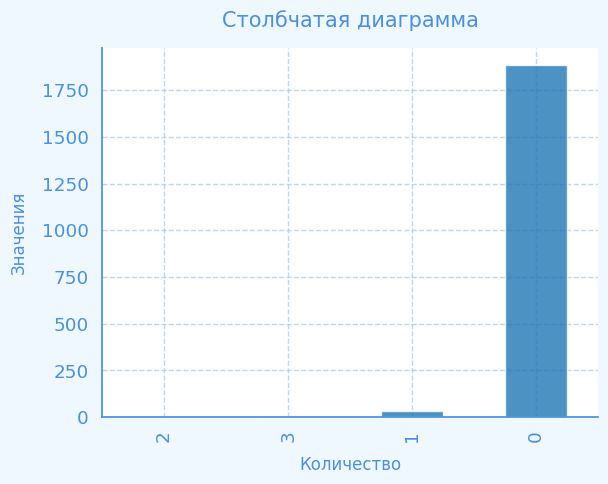

In [126]:
analisys_cat_plot(df_ac['cluster'])

In [127]:
print('Код не упал!')

Код не упал!
